DATA PREPROCESSING

In [469]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


In [470]:
df = pd.read_csv("heart.csv")

In [471]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [472]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [473]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Removing Duplicate if any

In [474]:
df.shape

(918, 12)

In [475]:
df = df.drop_duplicates()
df.shape

(918, 12)

In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Encoding

In [477]:
print(df['Sex'].value_counts(),
df['ChestPainType'].value_counts(),
df['RestingECG'].value_counts(),
df['ExerciseAngina'].value_counts(),
df['ST_Slope'].value_counts(),end= "\n",sep="\n")

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [478]:
print(df["Sex"].value_counts(),
df["ExerciseAngina"].value_counts(),end= "\n",sep="\n")

Sex
M    725
F    193
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


In [479]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [480]:
# Label Encoding for binary values
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])


In [481]:
print(df['Sex'].value_counts(),
df['ChestPainType'].value_counts(),
df['RestingECG'].value_counts(),
df['ExerciseAngina'].value_counts(),
df['ST_Slope'].value_counts(),end= "\n",sep="\n")

Sex
1    725
0    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
0    547
1    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [482]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,TA,110,264,0,Normal,132,0,1.2,Flat,1
914,68,1,ASY,144,193,1,Normal,141,0,3.4,Flat,1
915,57,1,ASY,130,131,0,Normal,115,1,1.2,Flat,1
916,57,0,ATA,130,236,0,LVH,174,0,0.0,Flat,1


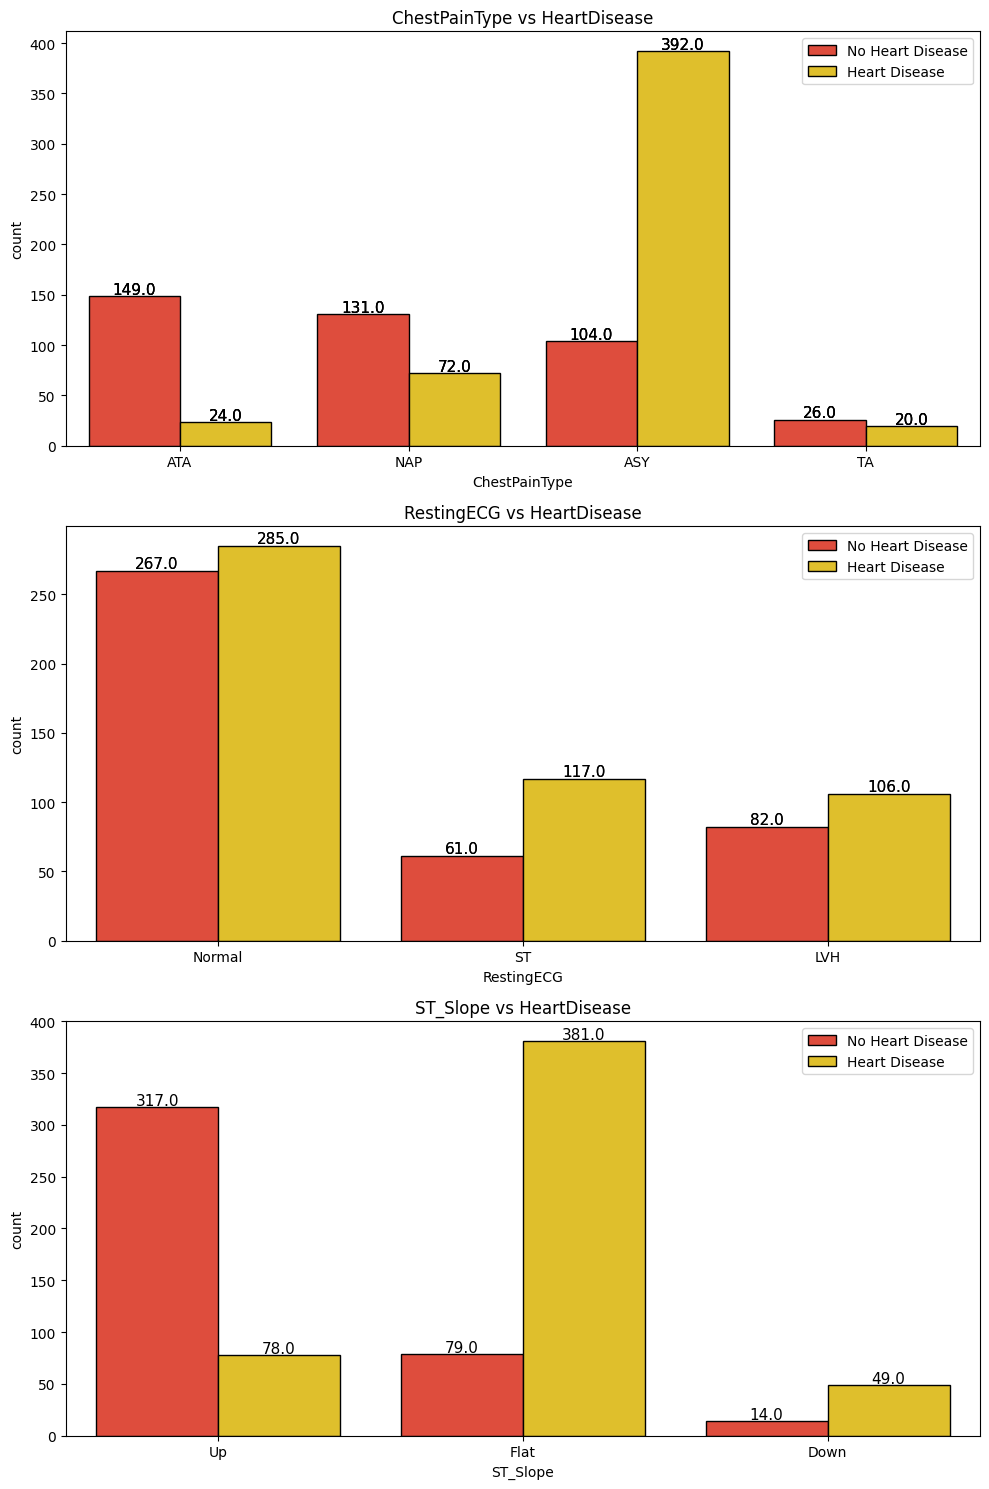

In [483]:
colors = ['#F93822', '#FDD20E']
categorical_features = ['ChestPainType', 'RestingECG', 'ST_Slope']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))  # Changed ncols to 1 for 3 rows and 1 column

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, hue="HeartDisease", palette=colors, edgecolor='black', ax=axes[i])
    for ax in axes:
        for rect in ax.patches:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize=11)
    axes[i].set_title(f"{feature} vs HeartDisease")
    axes[i].legend(['No Heart Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

In [484]:
#for the rest the dataset is divided into 2 . 
# df1 for label encoding 
# df2 for one-hot encoding 
# df3 for ordinal encoding
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()

In [485]:
df1['ChestPainType'] = le.fit_transform(df1['ChestPainType'])
df1['RestingECG'] = le.fit_transform(df1['RestingECG'])
df1['ST_Slope'] = le.fit_transform(df['ST_Slope'])

In [486]:
print(df['Sex'].value_counts(),
df['ChestPainType'].value_counts(),
df['RestingECG'].value_counts(),
df['ExerciseAngina'].value_counts(),
df['ST_Slope'].value_counts(),end= "\n",sep="\n")

Sex
1    725
0    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
0    547
1    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [487]:
print(df1['Sex'].value_counts(),
df1['ChestPainType'].value_counts(),
df1['RestingECG'].value_counts(),
df1['ExerciseAngina'].value_counts(),
df1['ST_Slope'].value_counts(),end= "\n",sep="\n")

Sex
1    725
0    193
Name: count, dtype: int64
ChestPainType
0    496
2    203
1    173
3     46
Name: count, dtype: int64
RestingECG
1    552
0    188
2    178
Name: count, dtype: int64
ExerciseAngina
0    547
1    371
Name: count, dtype: int64
ST_Slope
1    460
2    395
0     63
Name: count, dtype: int64


In [488]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int32  
 2   ChestPainType   918 non-null    int32  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int32  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int32  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int32  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int32(5), int64(6)
memory usage: 68.3 KB


In [489]:
df2 = pd.get_dummies(data = df2).astype(int)


In [490]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                918 non-null    int32
 1   Sex                918 non-null    int32
 2   RestingBP          918 non-null    int32
 3   Cholesterol        918 non-null    int32
 4   FastingBS          918 non-null    int32
 5   MaxHR              918 non-null    int32
 6   ExerciseAngina     918 non-null    int32
 7   Oldpeak            918 non-null    int32
 8   HeartDisease       918 non-null    int32
 9   ChestPainType_ASY  918 non-null    int32
 10  ChestPainType_ATA  918 non-null    int32
 11  ChestPainType_NAP  918 non-null    int32
 12  ChestPainType_TA   918 non-null    int32
 13  RestingECG_LVH     918 non-null    int32
 14  RestingECG_Normal  918 non-null    int32
 15  RestingECG_ST      918 non-null    int32
 16  ST_Slope_Down      918 non-null    int32
 17  ST_Slope_Flat   

In [491]:
chestPain = ['ASY', 'NAP', 'ATA', 'TA']
ecg = ['Normal', 'ST', 'LVH']
stslope = ['Flat', 'Up', 'Down']

encoder_chest_pain = OrdinalEncoder(categories=[(chestPain[::-1])])
encoder_ecg = OrdinalEncoder(categories=[(ecg[::-1])])
encoder_st_slope = OrdinalEncoder(categories=[(stslope[::-1])])

df3['ChestPainType'] = encoder_chest_pain.fit_transform(df3[['ChestPainType']])
df3['RestingECG'] = encoder_ecg.fit_transform(df3[['RestingECG']])
df3['ST_Slope'] = encoder_st_slope.fit_transform(df3[['ST_Slope']])

In [492]:
print(df3['Sex'].value_counts(),
df3['ChestPainType'].value_counts(),
df3['RestingECG'].value_counts(),
df3['ExerciseAngina'].value_counts(),
df3['ST_Slope'].value_counts(),end= "\n",sep="\n")

Sex
1    725
0    193
Name: count, dtype: int64
ChestPainType
3.0    496
2.0    203
1.0    173
0.0     46
Name: count, dtype: int64
RestingECG
2.0    552
0.0    188
1.0    178
Name: count, dtype: int64
ExerciseAngina
0    547
1    371
Name: count, dtype: int64
ST_Slope
2.0    460
1.0    395
0.0     63
Name: count, dtype: int64


In [493]:
df3

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1.0,140,289,0,2.0,172,0,0.0,1.0,0
1,49,0,2.0,160,180,0,2.0,156,0,1.0,2.0,1
2,37,1,1.0,130,283,0,1.0,98,0,0.0,1.0,0
3,48,0,3.0,138,214,0,2.0,108,1,1.5,2.0,1
4,54,1,2.0,150,195,0,2.0,122,0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,0.0,110,264,0,2.0,132,0,1.2,2.0,1
914,68,1,3.0,144,193,1,2.0,141,0,3.4,2.0,1
915,57,1,3.0,130,131,0,2.0,115,1,1.2,2.0,1
916,57,0,1.0,130,236,0,0.0,174,0,0.0,2.0,1


In [494]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int32  
 2   ChestPainType   918 non-null    float64
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    float64
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int32  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    float64
 11  HeartDisease    918 non-null    int64  
dtypes: float64(4), int32(2), int64(6)
memory usage: 79.0 KB


EDA

In [495]:
df1.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [496]:
df2.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [497]:
df3.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

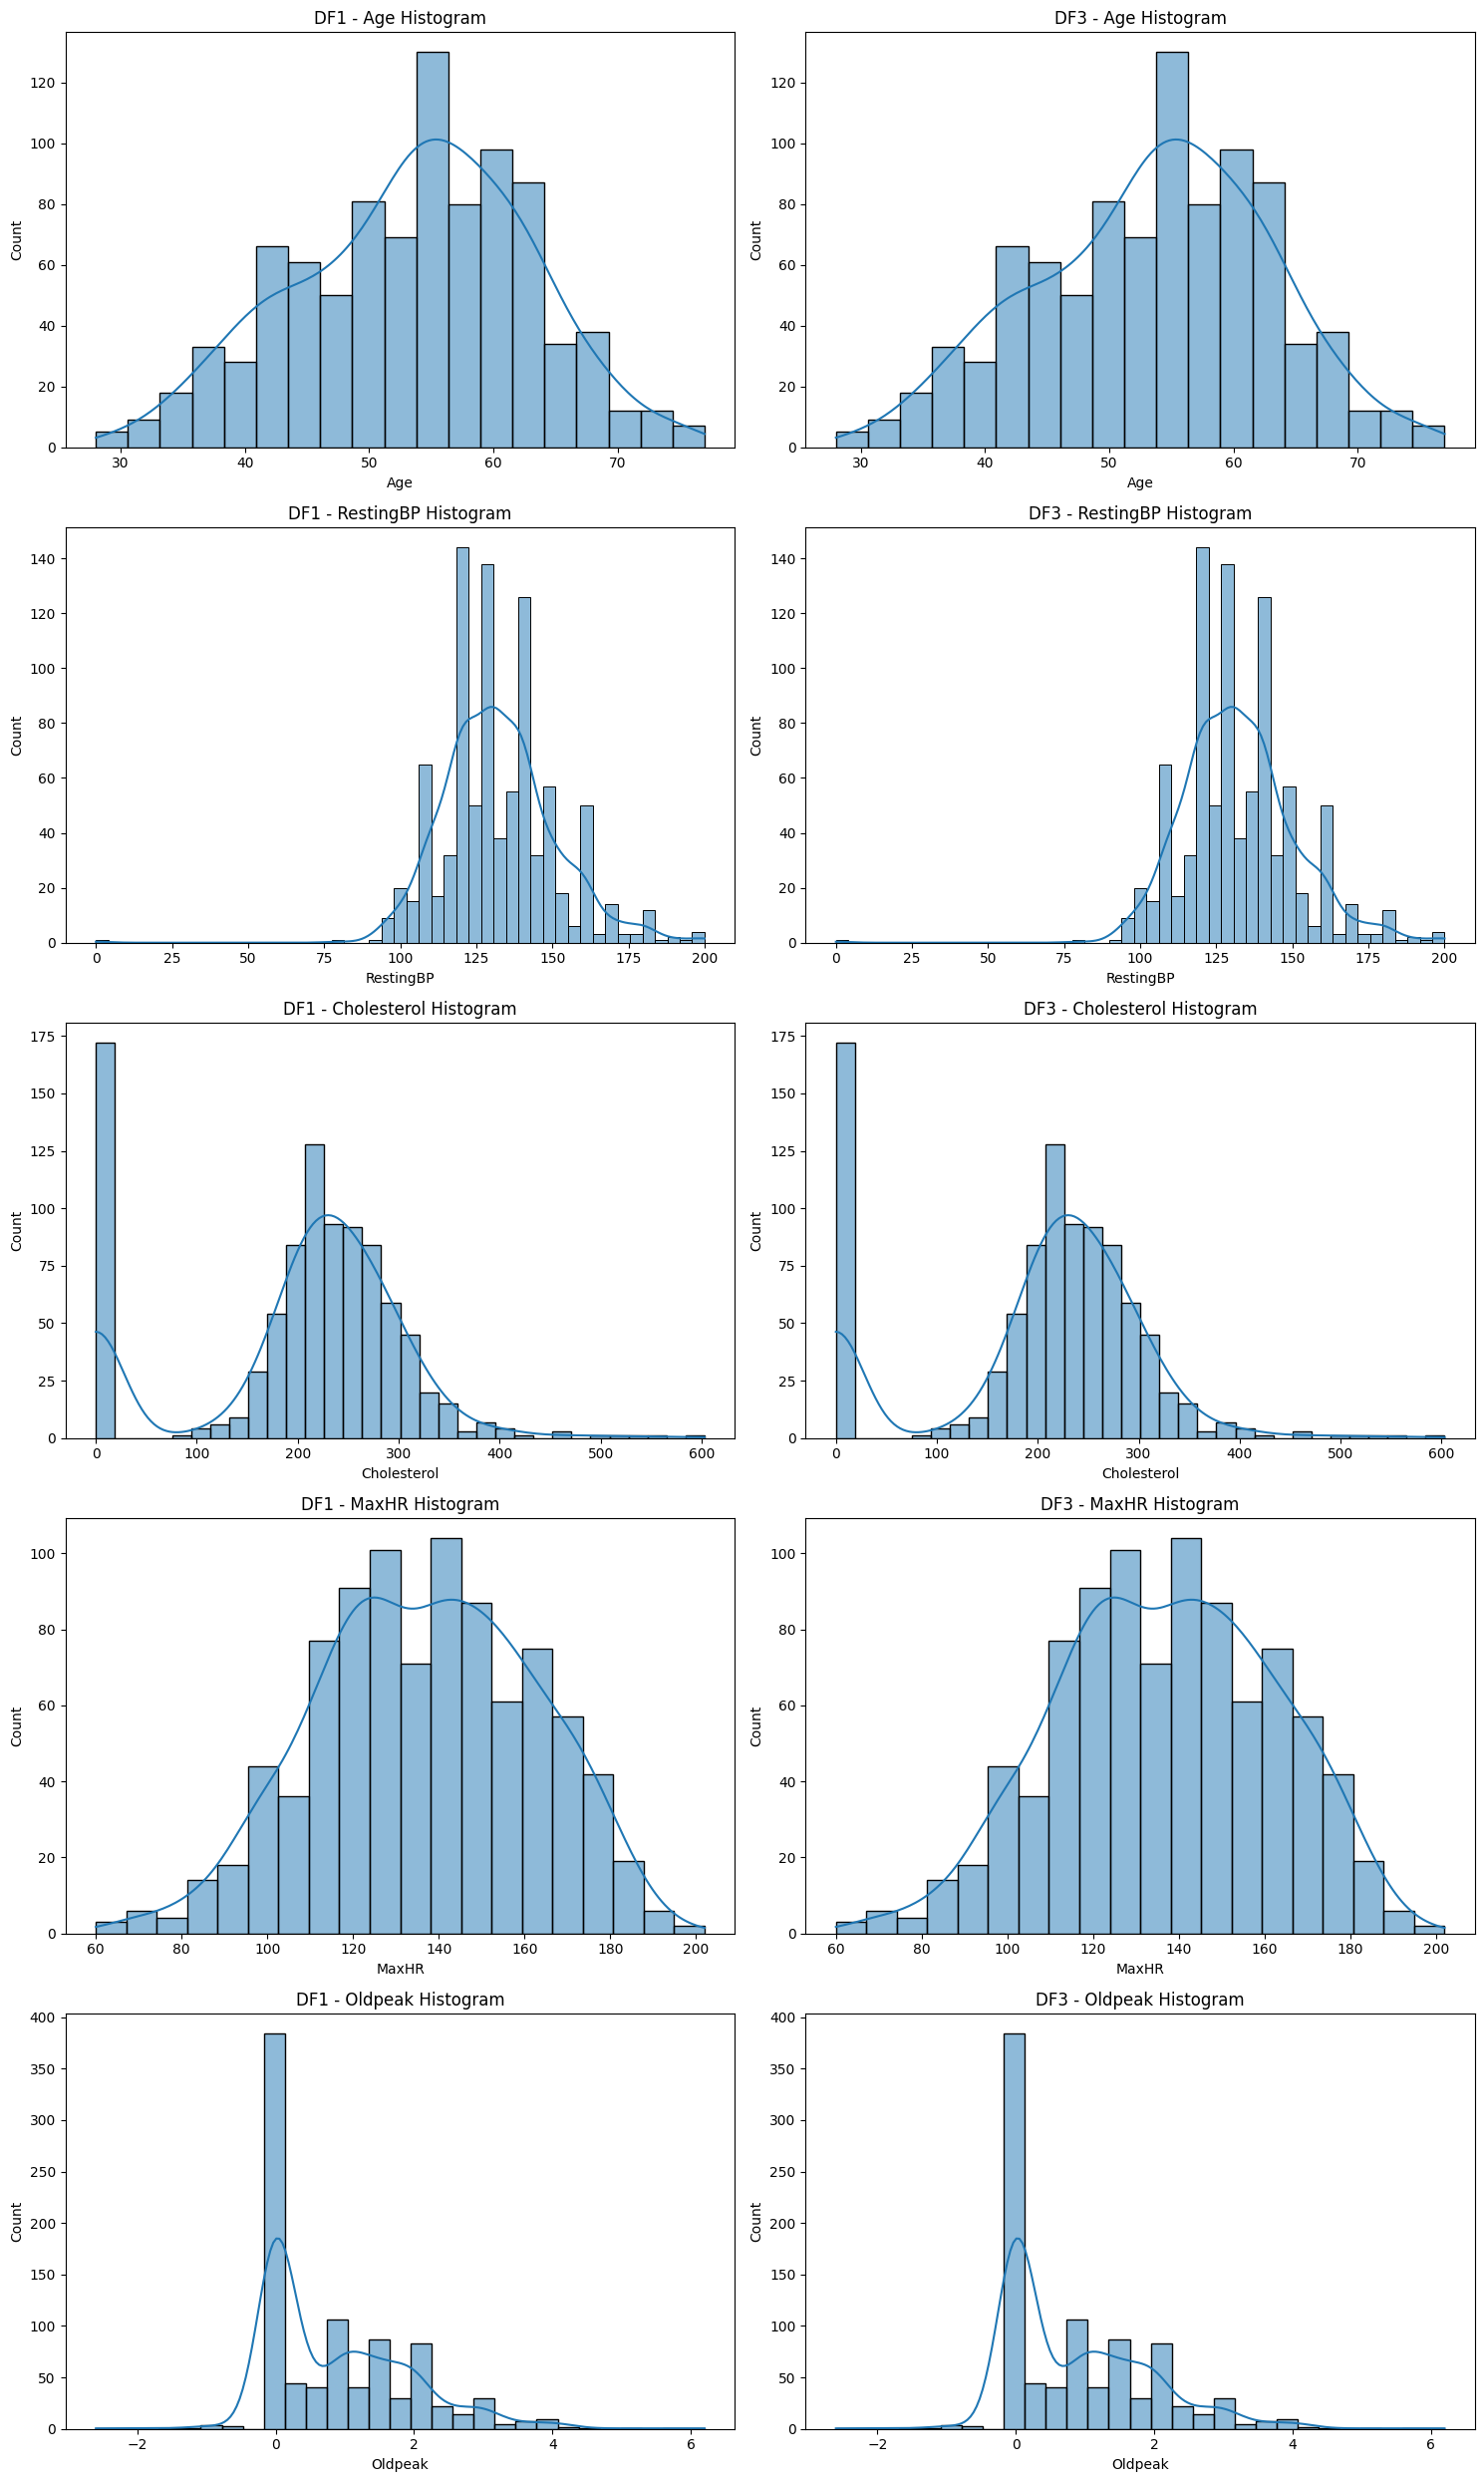

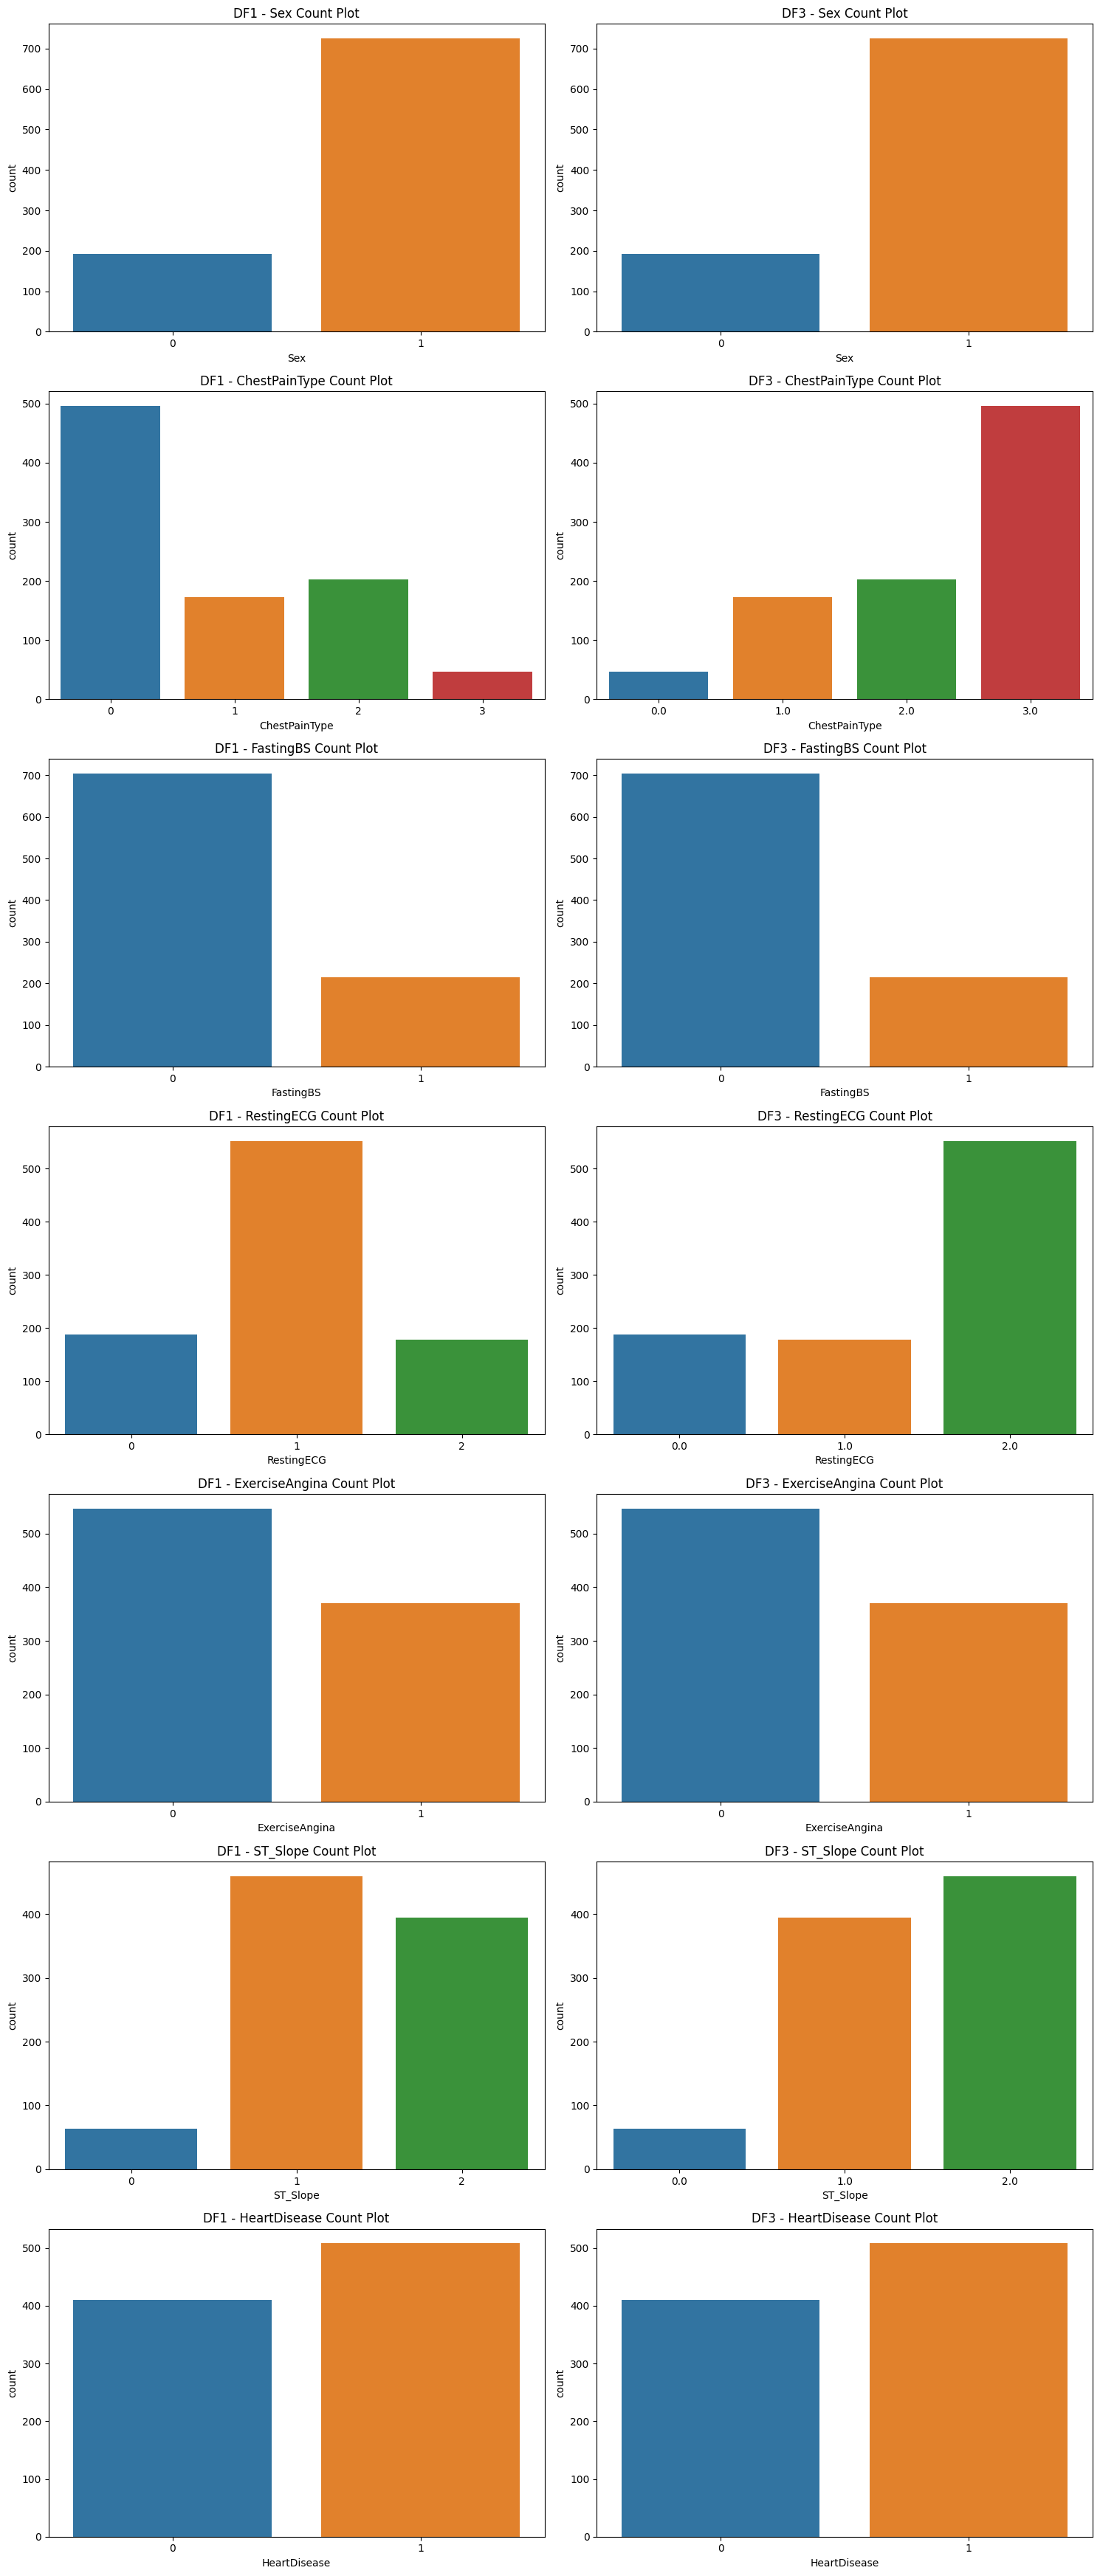

In [498]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define columns for numerical and categorical data separately
numerical_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_columns = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

# Setting up subplots for numerical columns (histograms)
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=2, figsize=(15, 5*len(numerical_columns)))
fig.subplots_adjust(hspace=0.5)

# Plotting histograms for each numerical column
for idx, col in enumerate(numerical_columns):
    # Plot for df1
    sns.histplot(data=df1, x=col, ax=axes[idx, 0], kde=True)
    axes[idx, 0].set_title(f'DF1 - {col} Histogram')

    # Plot for df3
    sns.histplot(data=df3, x=col, ax=axes[idx, 1], kde=True)
    axes[idx, 1].set_title(f'DF3 - {col} Histogram')

plt.tight_layout()
plt.show()

# Setting up subplots for categorical columns (count plots)
fig, axes = plt.subplots(nrows=len(categorical_columns), ncols=2, figsize=(15, 5*len(categorical_columns)))
fig.subplots_adjust(hspace=0.5)

# Plotting count plots for each categorical column
for idx, col in enumerate(categorical_columns):
    # Plot for df1
    sns.countplot(data=df1, x=col, ax=axes[idx, 0])
    axes[idx, 0].set_title(f'DF1 - {col} Count Plot')

    # Plot for df3
    sns.countplot(data=df3, x=col, ax=axes[idx, 1])
    axes[idx, 1].set_title(f'DF3 - {col} Count Plot')

plt.tight_layout()
plt.show()


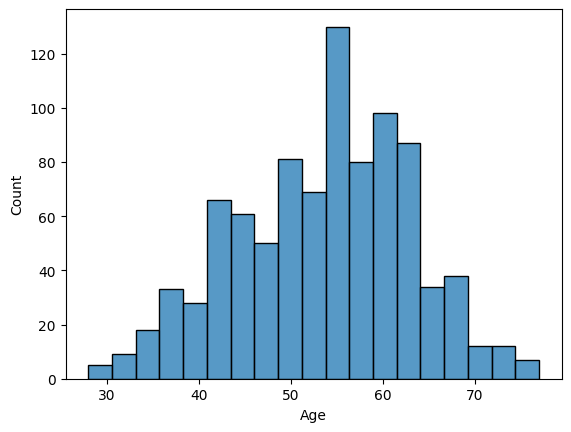

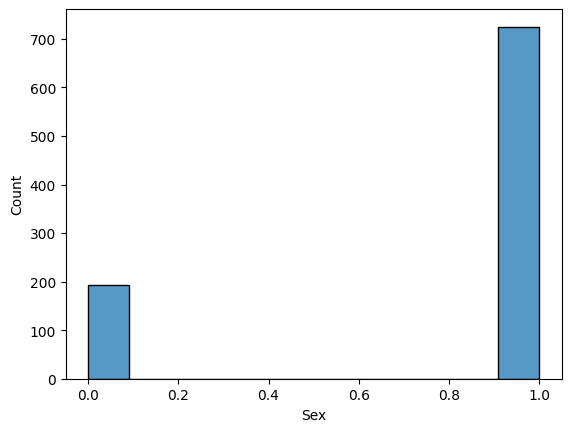

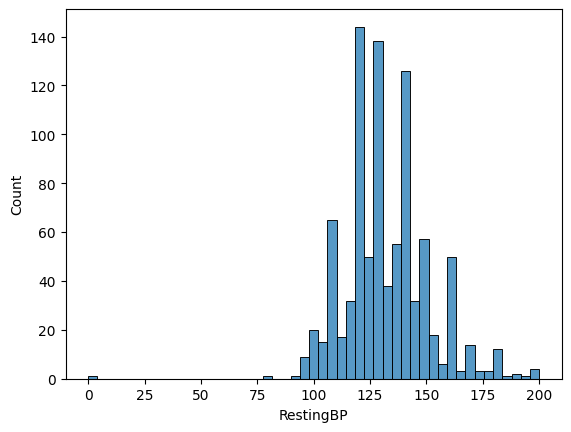

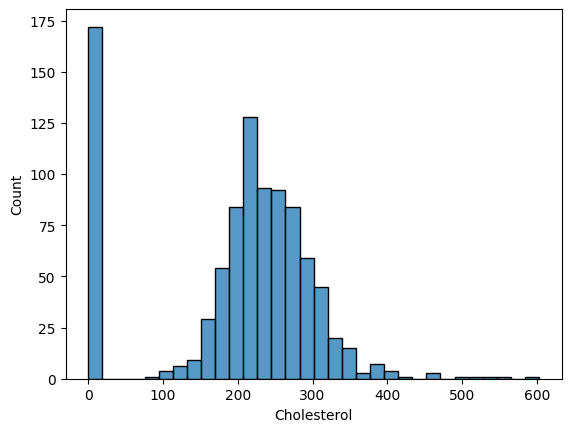

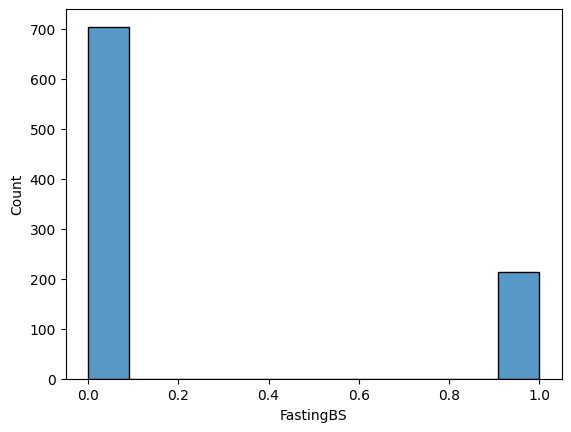

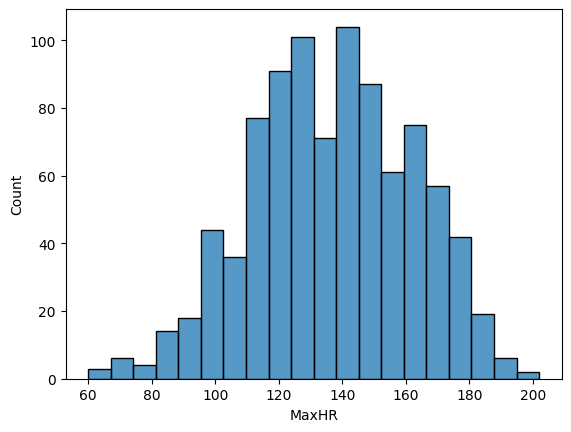

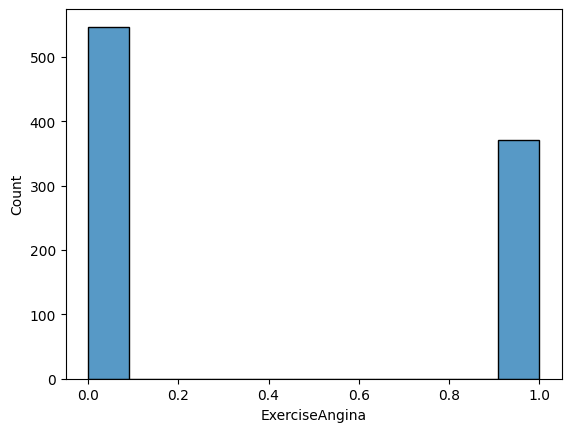

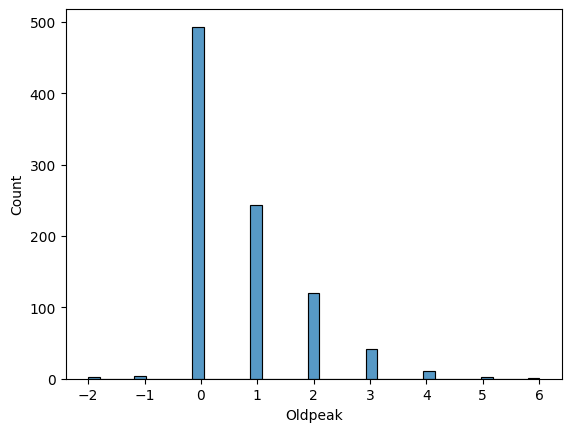

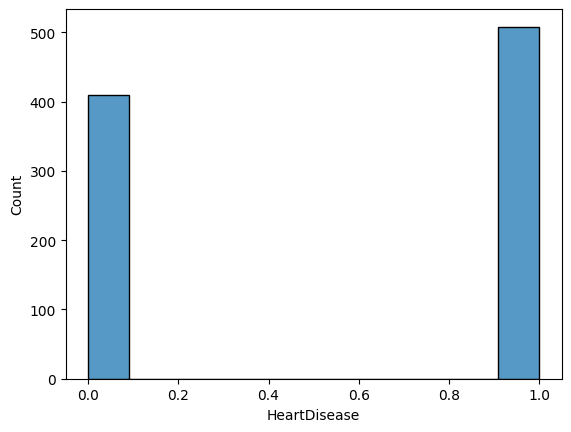

In [499]:
for i in df.select_dtypes(include = "number").columns:
    sns.histplot(data = df2,x = i)
    plt.show()

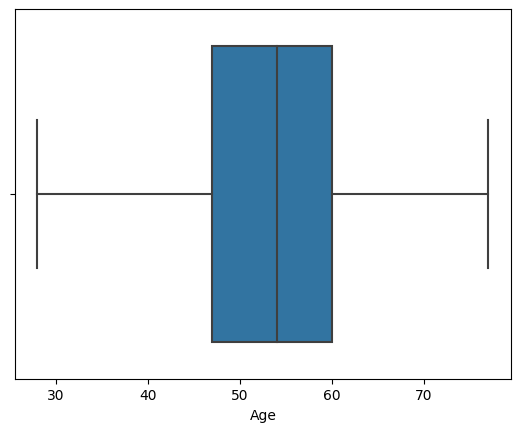

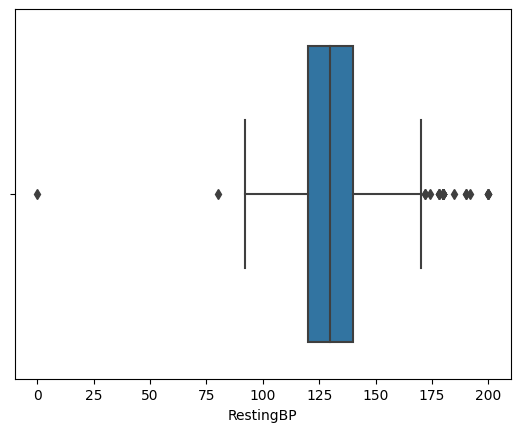

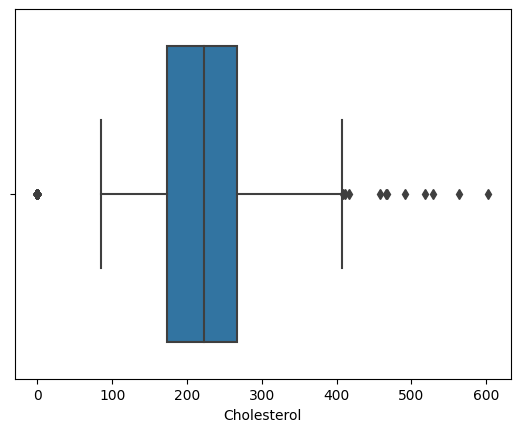

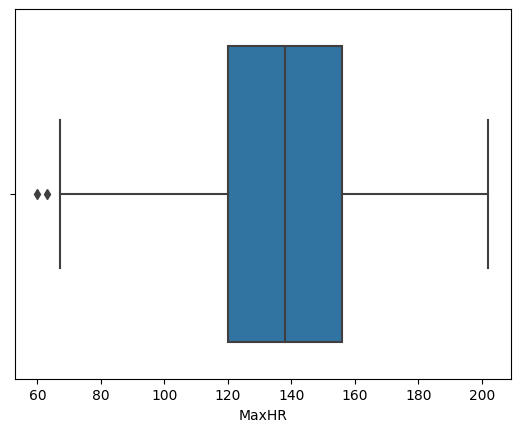

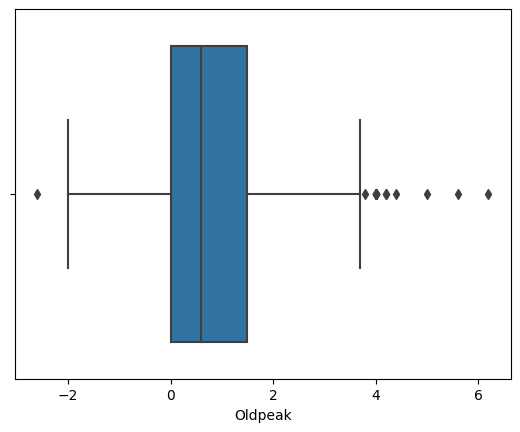

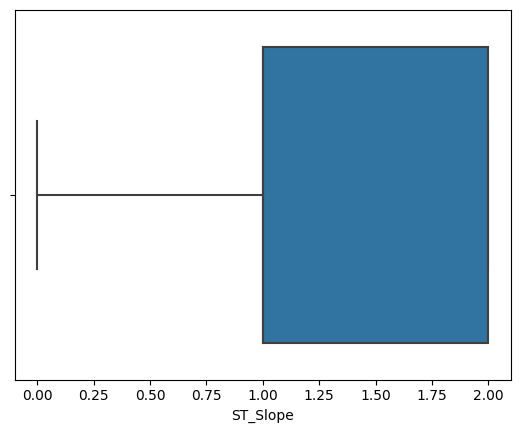

In [500]:
for i in ['Age', 'RestingBP', 'Cholesterol',
        'MaxHR', 'Oldpeak', 'ST_Slope']:
    sns.boxplot(data = df1,x = df1[i])
    plt.show()

In [501]:
df3.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [502]:
df3

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1.0,140,289,0,2.0,172,0,0.0,1.0,0
1,49,0,2.0,160,180,0,2.0,156,0,1.0,2.0,1
2,37,1,1.0,130,283,0,1.0,98,0,0.0,1.0,0
3,48,0,3.0,138,214,0,2.0,108,1,1.5,2.0,1
4,54,1,2.0,150,195,0,2.0,122,0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,0.0,110,264,0,2.0,132,0,1.2,2.0,1
914,68,1,3.0,144,193,1,2.0,141,0,3.4,2.0,1
915,57,1,3.0,130,131,0,2.0,115,1,1.2,2.0,1
916,57,0,1.0,130,236,0,0.0,174,0,0.0,2.0,1


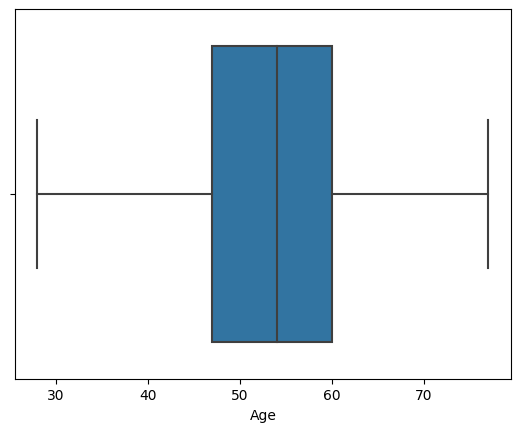

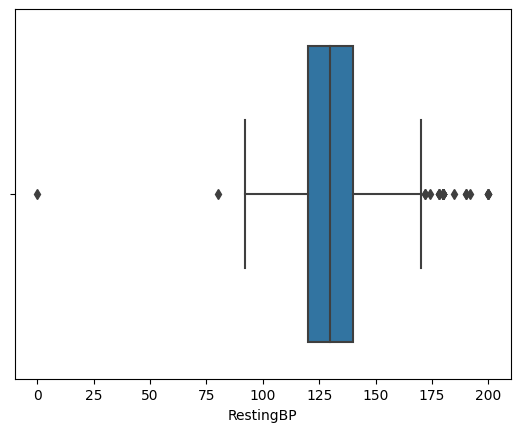

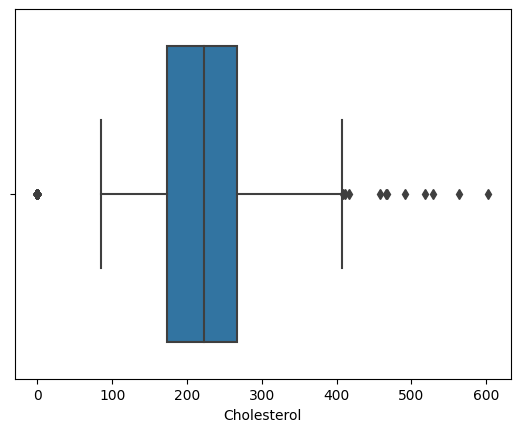

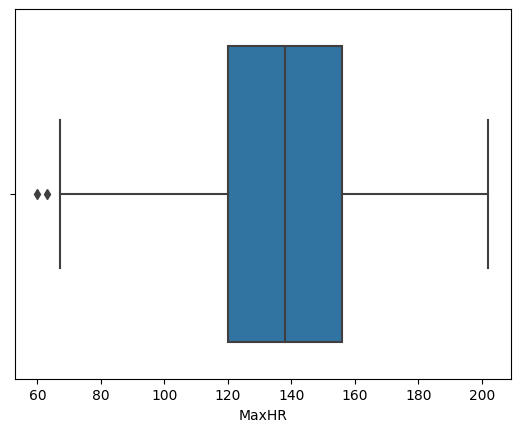

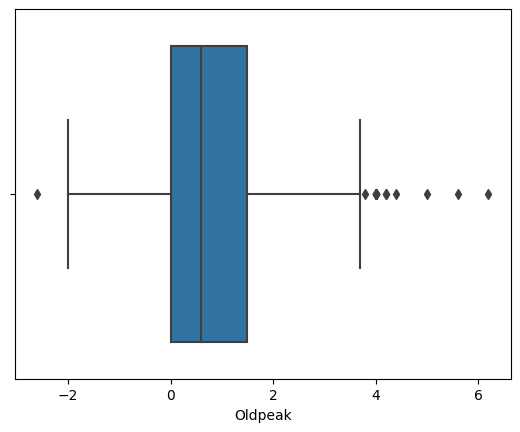

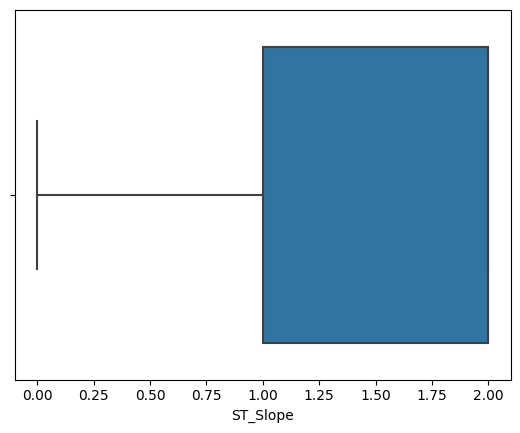

In [503]:
for i in ['Age', 'RestingBP', 'Cholesterol',
        'MaxHR', 'Oldpeak', 'ST_Slope']:
    sns.boxplot(data = df3,x = df3[i])
    plt.show()

Removing Outliers

In [504]:
# Replacing with whiskers
#df1_1 for df1
#df2_1 for df2
#df3_1 for df3
df1_1 = df1.copy()
df2_1 = df2.copy()
df3_1 = df3.copy()

In [505]:

Q1 = df1_1.quantile(0.25)
Q3 = df1_1.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR


for i in ['Age', 'RestingBP', 'Cholesterol',
        'MaxHR', 'Oldpeak', 'ST_Slope']:
    df1_1.loc[df1_1[i] < lower_whisker[i], i] = lower_whisker[i]
    df1_1.loc[df1_1[i] > upper_whisker[i], i] = upper_whisker[i]



In [506]:
df2.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [507]:
Q1 = df2_1.quantile(0.25)
Q3 = df2_1.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR


for i in ['Age', 'RestingBP', 'Cholesterol',
        'MaxHR', 'Oldpeak']:
    df2_1.loc[df2_1[i] < lower_whisker[i], i] = lower_whisker[i]
    df2_1.loc[df2_1[i] > upper_whisker[i], i] = upper_whisker[i]

In [508]:
Q1 = df3_1.quantile(0.25)
Q3 = df3_1.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR


for i in ['Age', 'RestingBP', 'Cholesterol',
        'MaxHR', 'Oldpeak', 'ST_Slope']:
    df3_1.loc[df3_1[i] < lower_whisker[i], i] = lower_whisker[i]
    df3_1.loc[df3_1[i] > upper_whisker[i], i] = upper_whisker[i]

In [509]:
# Replacing with mean
#df1_1 for df1
#df2_1 for df2
#df3_1 for df3
df1_2 = df1.copy()
df2_2 = df2.copy()
df3_2 = df3.copy()

In [510]:
Q1 = df1_2.quantile(0.25)
Q3 = df1_2.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR




for i in ['RestingBP', 'Cholesterol',
     'MaxHR', 'Oldpeak']:
    df1_2.loc[df1_2[i] < lower_whisker[i], i] = df1_2[i].mean()
    df1_2.loc[df1_2[i] > upper_whisker[i], i] = df1_2[i].mean() 

In [511]:
Q1 = df2_2.quantile(0.25)
Q3 = df2_2.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

for i in ['RestingBP', 'Cholesterol',
     'MaxHR', 'Oldpeak']:
    df2_2.loc[df2_2[i] < lower_whisker[i], i] = df2_2[i].mean()
    df2_2.loc[df2_2[i] > upper_whisker[i], i] = df2_2[i].mean()

In [512]:
Q1 = df3_2.quantile(0.25)
Q3 = df3_2.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

for i in ['RestingBP', 'Cholesterol',
     'MaxHR', 'Oldpeak']:
    df3_2.loc[df3_2[i] < lower_whisker[i], i] = df3_2[i].mean()
    df3_2.loc[df3_2[i] > upper_whisker[i], i] = df3_2[i].mean()

In [513]:
correlation = df1.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64

In [514]:
#dropping the columns with negative correlation
df1 = df1.drop(columns=['Cholesterol', 'ChestPainType', 'MaxHR','ST_Slope'])

In [515]:
correlation = df2.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina       0.494282
Oldpeak              0.392385
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.107589
RestingECG_ST        0.102527
RestingECG_LVH       0.010670
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [516]:
#dropping the columns with negative correlation
df2 = df2.drop(columns=['ChestPainType_TA', 'RestingECG_Normal', 'ChestPainType_NAP', 'Cholesterol', 'MaxHR', 'ChestPainType_ATA', 'ST_Slope_Up'])

In [517]:
correlation = df3.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
ChestPainType     0.471354
Oldpeak           0.403951
ST_Slope          0.397802
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG       -0.061011
Cholesterol      -0.232741
MaxHR            -0.400421
Name: HeartDisease, dtype: float64

In [518]:
# Dropping the columns with negative correlation
df3 = df3.drop(columns=['RestingECG', 'Cholesterol', 'MaxHR'])

In [519]:
correlation = df1_1.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.410211
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.113191
RestingECG        0.057384
Cholesterol      -0.225304
ChestPainType    -0.386828
MaxHR            -0.400519
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64

In [520]:
# Dropping the columns with negative correlation
df1_1 = df1_1.drop(columns=['Cholesterol', 'ChestPainType', 'MaxHR', 'ST_Slope'])

In [521]:
correlation = df1_2.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.407876
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.108948
RestingECG        0.057384
Cholesterol      -0.018065
ChestPainType    -0.386828
MaxHR            -0.398458
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64

In [522]:
# Dropping the columns with negative correlation
df1_2 = df1_2.drop(columns=['Cholesterol', 'ChestPainType', 'MaxHR', 'ST_Slope'])

In [523]:
correlation = df2_1.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina       0.494282
Oldpeak              0.412534
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.113191
RestingECG_ST        0.102527
RestingECG_LVH       0.010670
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.225304
MaxHR               -0.400519
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [524]:
# Dropping the columns with negative correlation
df2_1 = df2_1.drop(columns=['ChestPainType_TA', 'RestingECG_Normal', 'ChestPainType_NAP', 'Cholesterol', 'MaxHR', 'ChestPainType_ATA', 'ST_Slope_Up'])

In [525]:
correlation = df2_2.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina       0.494282
Oldpeak              0.392687
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.108948
RestingECG_ST        0.102527
RestingECG_LVH       0.010670
Cholesterol         -0.018065
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
MaxHR               -0.398458
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [526]:
# Dropping the columns with negative correlation
df2_2 = df2_2.drop(columns=['Cholesterol', 'ChestPainType_TA', 'RestingECG_Normal', 'ChestPainType_NAP', 'MaxHR', 'ChestPainType_ATA', 'ST_Slope_Up'])

In [527]:
correlation = df3_1.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
ChestPainType     0.471354
Oldpeak           0.410211
ST_Slope          0.397802
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.113191
RestingECG       -0.061011
Cholesterol      -0.225304
MaxHR            -0.400519
Name: HeartDisease, dtype: float64

In [528]:
# Dropping the columns with negative correlation
df3_1 = df3_1.drop(columns=['RestingECG', 'Cholesterol', 'MaxHR'])

In [529]:
correlation = df3_2.corr()
target_column = "HeartDisease"
sorted_corr = correlation[target_column].sort_values(ascending=False)
sorted_corr

HeartDisease      1.000000
ExerciseAngina    0.494282
ChestPainType     0.471354
Oldpeak           0.407876
ST_Slope          0.397802
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.108948
Cholesterol      -0.018065
RestingECG       -0.061011
MaxHR            -0.398458
Name: HeartDisease, dtype: float64

In [530]:
# Dropping the columns with negative correlation
df3_2= df3_2.drop(columns=['Cholesterol', 'RestingECG', 'MaxHR'])

In [531]:
#with outliers
# df1
# df2
# df3
# X1 = df1.drop(columns=["HeartDisease"])
# y1 = df1["HeartDisease"]

# X2 = df2.drop(columns=["HeartDisease"])
# y2 = df2["HeartDisease"]

# X3 = df3.drop(columns=["HeartDisease"])
# y3 = df3["HeartDisease"]


#outlier replaced with whisker
# df1_1 
# df2_1
# df3_1

#outlier replaced with mean
# df1_2 
# df2_2
# df3_2

In [532]:
results = {
    "KNN": {},
    "SVM": {},
    "Decision Tree": {},
    "Logistic Regression": {},
    "Random Forest": {}
}

# KNN

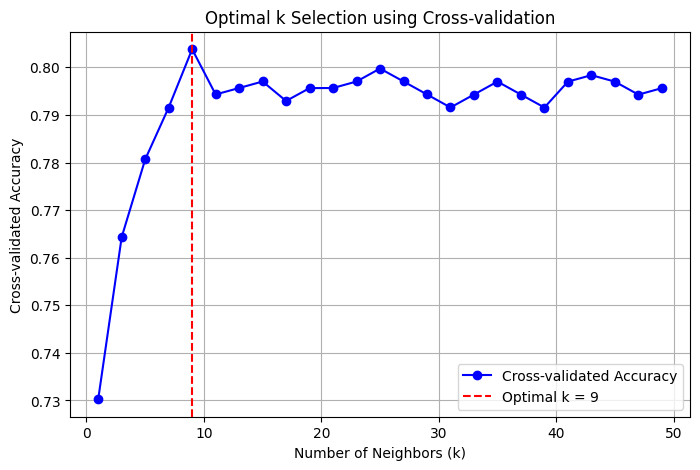

Optimal k for df1: 9
AUC-PR for df1: 0.8662
Cross-Validation PR AUC for df1: 0.8527
Accuracy for df1: 0.7391
Cross-Validation Accuracy for df1: 0.7943


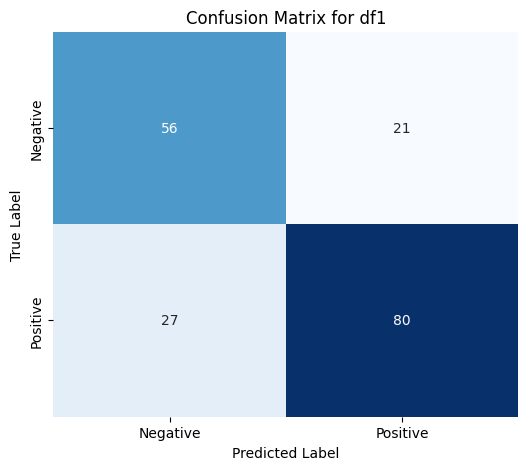

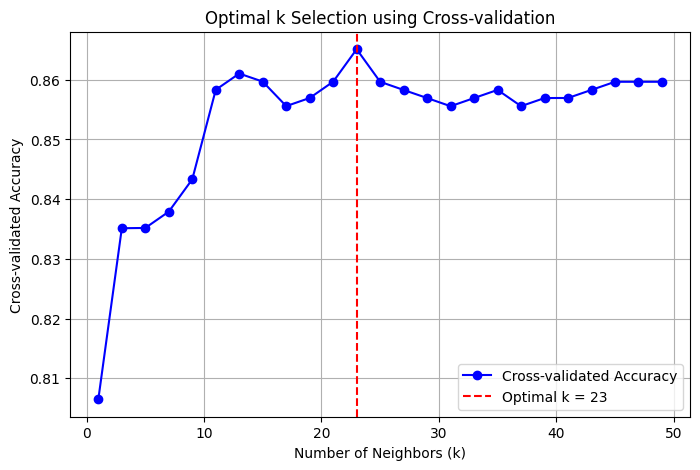

Optimal k for df2: 23
AUC-PR for df2: 0.9407
Cross-Validation PR AUC for df2: 0.9008
Accuracy for df2: 0.8587
Cross-Validation Accuracy for df2: 0.8611


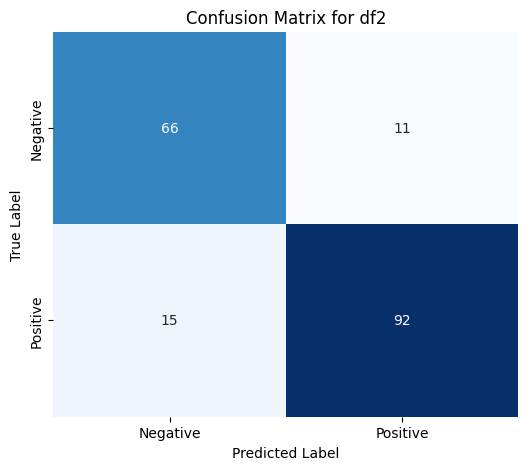

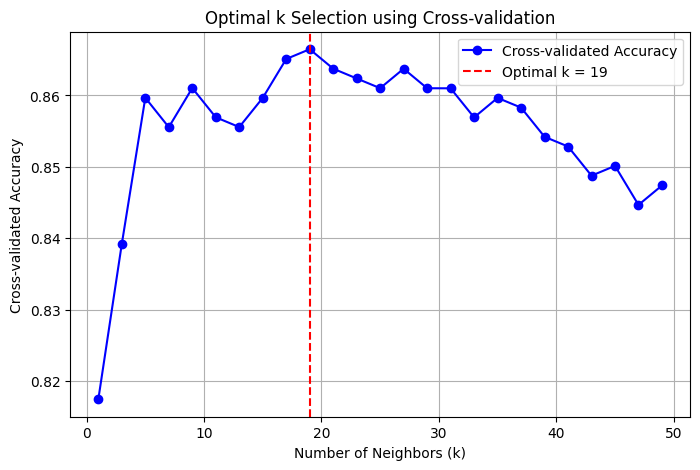

Optimal k for df3: 19
AUC-PR for df3: 0.9503
Cross-Validation PR AUC for df3: 0.9049
Accuracy for df3: 0.8587
Cross-Validation Accuracy for df3: 0.8665


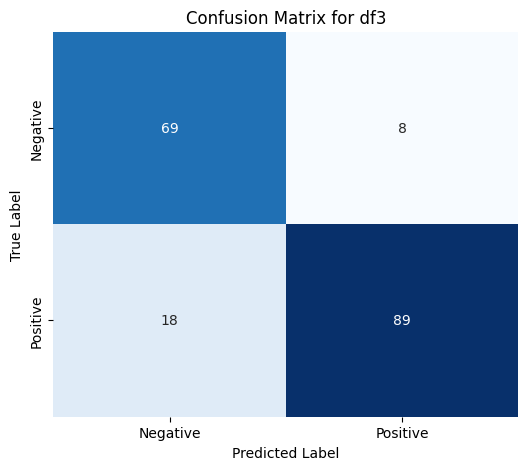

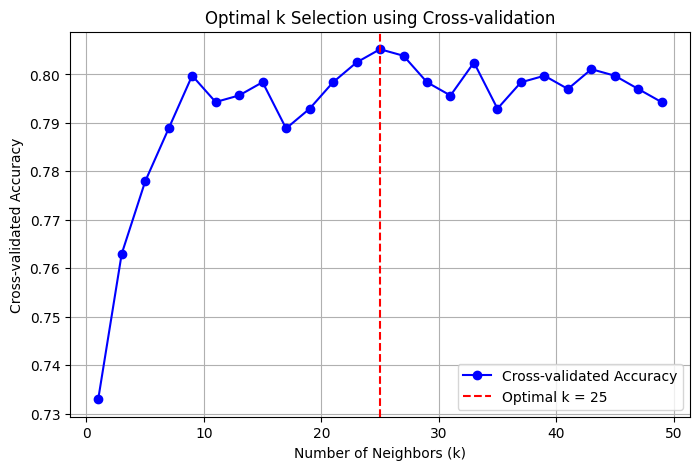

Optimal k for df1_1: 25
AUC-PR for df1_1: 0.8674
Cross-Validation PR AUC for df1_1: 0.8691
Accuracy for df1_1: 0.7446
Cross-Validation Accuracy for df1_1: 0.8025


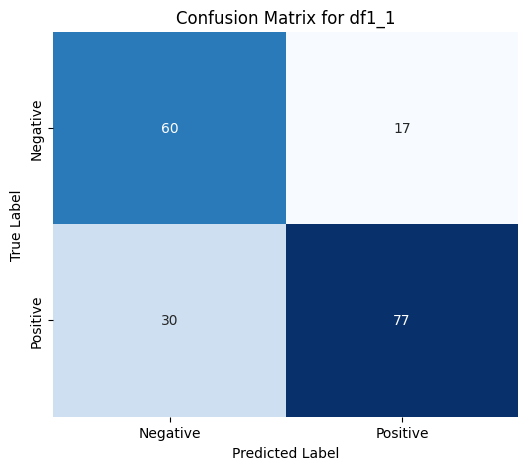

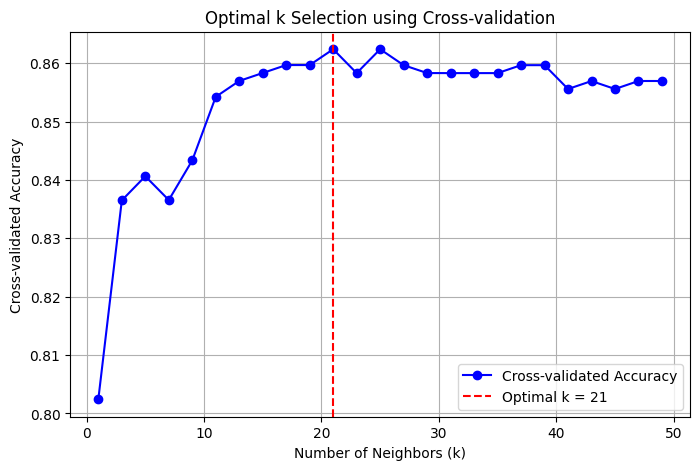

Optimal k for df2_1: 21
AUC-PR for df2_1: 0.9307
Cross-Validation PR AUC for df2_1: 0.8928
Accuracy for df2_1: 0.8533
Cross-Validation Accuracy for df2_1: 0.8516


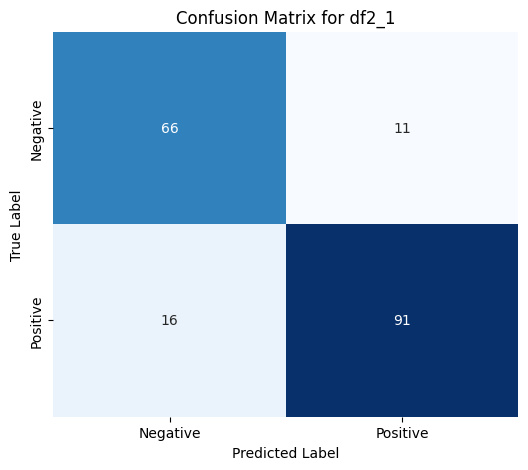

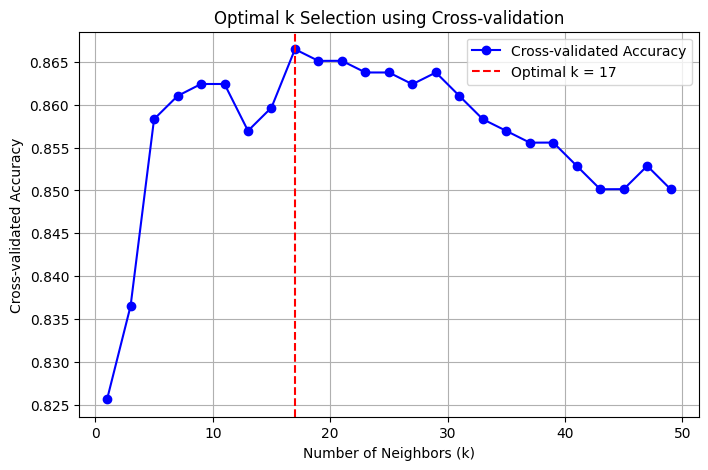

Optimal k for df3_1: 17
AUC-PR for df3_1: 0.9494
Cross-Validation PR AUC for df3_1: 0.9041
Accuracy for df3_1: 0.8696
Cross-Validation Accuracy for df3_1: 0.8637


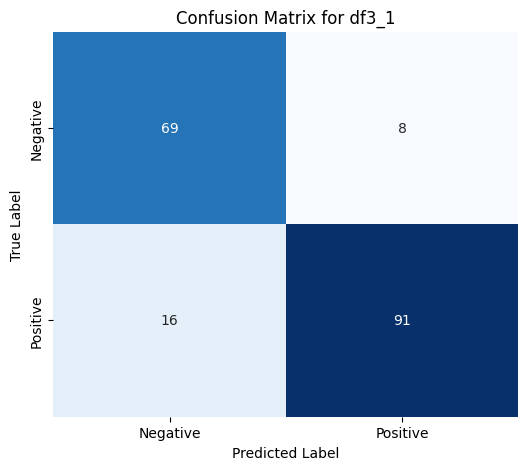

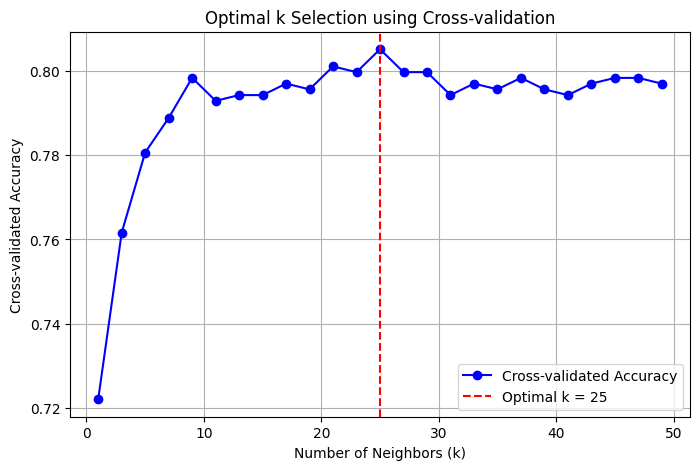

Optimal k for df1_2: 25
AUC-PR for df1_2: 0.8466
Cross-Validation PR AUC for df1_2: 0.8647
Accuracy for df1_2: 0.7446
Cross-Validation Accuracy for df1_2: 0.7970


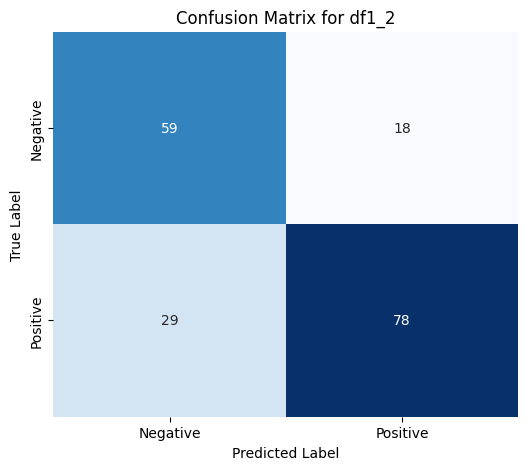

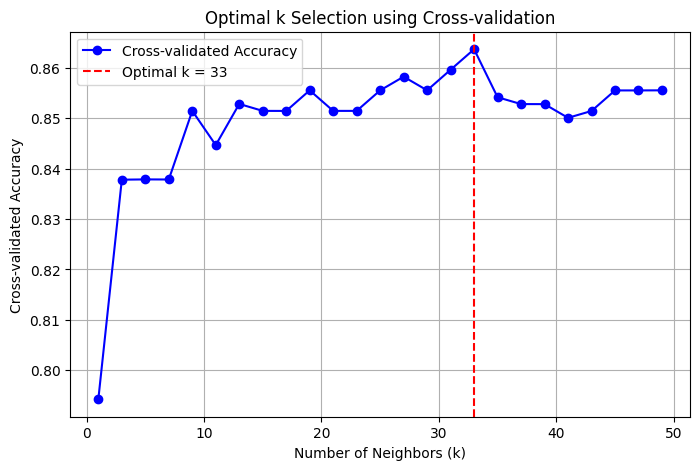

Optimal k for df2_2: 33
AUC-PR for df2_2: 0.9370
Cross-Validation PR AUC for df2_2: 0.9081
Accuracy for df2_2: 0.8424
Cross-Validation Accuracy for df2_2: 0.8502


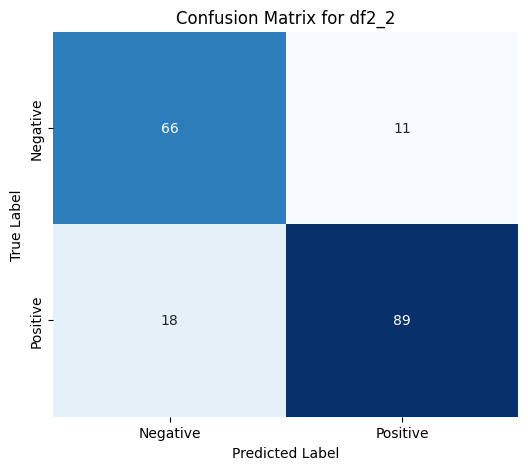

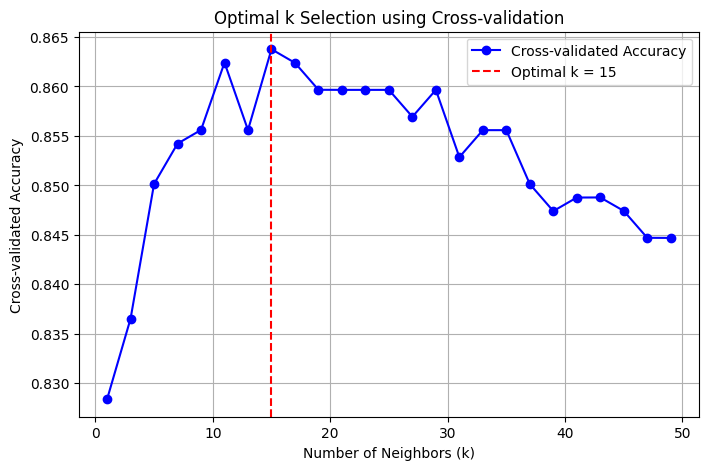

Optimal k for df3_2: 15
AUC-PR for df3_2: 0.9360
Cross-Validation PR AUC for df3_2: 0.9034
Accuracy for df3_2: 0.8641
Cross-Validation Accuracy for df3_2: 0.8692


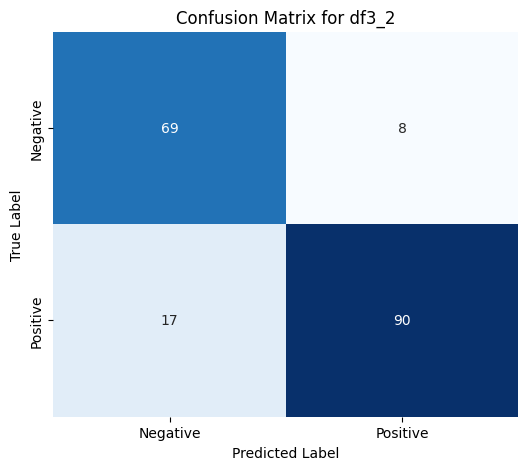

Combined PR curve image saved at pr_curves\combined_pr_curves.png


In [533]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image, ImageDraw, ImageFont

# Function to find the optimal k value using cross-validation
def find_optimal_k(X_train, y_train, max_k=50):
    k_values = range(1, max_k, 2)  # Odd values of k to avoid ties
    mean_accuracies = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        mean_accuracies.append(scores.mean())

    optimal_k = k_values[np.argmax(mean_accuracies)]
    
    # Plot k vs accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, mean_accuracies, marker='o', linestyle='-', color='b', label='Cross-validated Accuracy')
    plt.axvline(optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Cross-validated Accuracy')
    plt.title('Optimal k Selection using Cross-validation')
    plt.legend()
    plt.grid(True)
    plt.show()

    return optimal_k

# Create a directory to save PR curve images
output_dir = "pr_curves"
os.makedirs(output_dir, exist_ok=True)

# Store image paths for final combination
pr_curve_images = []
k_values = []


def knn_pr_curve_and_report(X, y, dataset_label):
    global pr_curve_images, k_values, results
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    optimal_k = find_optimal_k(X_train_scaled, y_train)
    knn = KNeighborsClassifier(n_neighbors=optimal_k)
    knn.fit(X_train_scaled, y_train)
    
    y_scores = knn.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    # Compute Cross-Validation PR AUC
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_pr_aucs = []
    cv_accuracy_scores = []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        knn.fit(X_tr, y_tr)
        y_val_scores = knn.predict_proba(X_val)[:, 1]
        val_precision, val_recall, _ = precision_recall_curve(y_val, y_val_scores)
        cv_pr_aucs.append(auc(val_recall, val_precision))
        
        # Compute Cross-Validation Accuracy
        y_val_pred = knn.predict(X_val)
        cv_accuracy_scores.append(accuracy_score(y_val, y_val_pred))

    cv_pr_auc = np.mean(cv_pr_aucs)  # Average over all folds
    cv_accuracy = np.mean(cv_accuracy_scores)  # Average over all folds
    
    # Store results in dictionary
    results["KNN"][dataset_label] = {
        "Optimal k": optimal_k,
        "PR AUC": pr_auc,
        "CV PR AUC": cv_pr_auc,
        "Accuracy": accuracy,
        "CV Accuracy": cv_accuracy  # Add Cross-Validation Accuracy
    }
    
    print(f"Optimal k for {dataset_label}: {optimal_k}")
    print(f"AUC-PR for {dataset_label}: {pr_auc:.4f}")
    print(f"Cross-Validation PR AUC for {dataset_label}: {cv_pr_auc:.4f}")
    print(f"Accuracy for {dataset_label}: {accuracy:.4f}")
    print(f"Cross-Validation Accuracy for {dataset_label}: {cv_accuracy:.4f}")

    # Plot PR curve
    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, marker='.', label=f'{dataset_label} (AUC = {pr_auc:.2f})', color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {dataset_label}')
    plt.legend()
    plt.grid(True)
    
    img_path = os.path.join(output_dir, f"pr_curve_{dataset_label}.png")
    plt.savefig(img_path)
    pr_curve_images.append(img_path)
    k_values.append(f"{dataset_label}: k={optimal_k}")
    plt.close()
    
    # Plot Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {dataset_label}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])
    plt.yticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])
    plt.show()

# Example datasets
datasets = {
    'df1': (df1, 'HeartDisease'),
    'df2': (df2, 'HeartDisease'),
    'df3': (df3, 'HeartDisease'),
    'df1_1': (df1_1, 'HeartDisease'),
    'df2_1': (df2_1, 'HeartDisease'),
    'df3_1': (df3_1, 'HeartDisease'),
    'df1_2': (df1_2, 'HeartDisease'),
    'df2_2': (df2_2, 'HeartDisease'),
    'df3_2': (df3_2, 'HeartDisease')
}

# Run KNN on each dataset
for label, (df, target) in datasets.items():
    X = df.drop(columns=[target])
    y = df[target]
    knn_pr_curve_and_report(X, y, label)

# Combine PR curve images horizontally
images = [Image.open(img) for img in pr_curve_images]
widths, heights = zip(*(img.size for img in images))
total_width = sum(widths)
max_height = max(heights)

combined_img = Image.new('RGB', (total_width, max_height + 50), (255, 255, 255))
x_offset = 0
for img in images:
    combined_img.paste(img, (x_offset, 0))
    x_offset += img.width

# Add dataset labels and k values at the bottom
try:
    font = ImageFont.truetype("arial.ttf", 20)
except IOError:
    font = ImageFont.load_default()

draw = ImageDraw.Draw(combined_img)
k_text = " | ".join(k_values)
draw.text((10, max_height + 10), k_text, fill=(0, 0, 0), font=font)

final_img_path = os.path.join(output_dir, "combined_pr_curves.png")
combined_img.save(final_img_path)
print(f"Combined PR curve image saved at {final_img_path}")


In [534]:
print(results)

{'KNN': {'df1': {'Optimal k': 9, 'PR AUC': 0.8661767055663664, 'CV PR AUC': 0.8526974940210609, 'Accuracy': 0.7391304347826086, 'CV Accuracy': 0.7943062156369397}, 'df2': {'Optimal k': 23, 'PR AUC': 0.940724184328848, 'CV PR AUC': 0.9007984213041823, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8610753890597334}, 'df3': {'Optimal k': 19, 'PR AUC': 0.9503411952365282, 'CV PR AUC': 0.9049450132273993, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8664616531544125}, 'df1_1': {'Optimal k': 25, 'PR AUC': 0.8673937896519223, 'CV PR AUC': 0.8691450042725279, 'Accuracy': 0.7445652173913043, 'CV Accuracy': 0.8024601621470506}, 'df2_1': {'Optimal k': 21, 'PR AUC': 0.9306504181321884, 'CV PR AUC': 0.8928091809027695, 'Accuracy': 0.8532608695652174, 'CV Accuracy': 0.8515515795359239}, 'df3_1': {'Optimal k': 17, 'PR AUC': 0.9493758927476706, 'CV PR AUC': 0.9041115771224879, 'Accuracy': 0.8695652173913043, 'CV Accuracy': 0.8637405647190383}, 'df1_2': {'Optimal k': 25, 'PR AUC': 0.846583214543

# Logistic Regression

In [535]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_curve, classification_report


Results for df1:
Accuracy: 0.8315
Precision: 0.8660
Recall: 0.8235
F1 Score: 0.8442
ROC AUC Score: 0.9125
PR AUC Score: 0.9316
Cross-validation accuracy: 0.7865 ± 0.0280
Cross-validation PR AUC: 0.8728

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        82
           1       0.87      0.82      0.84       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184


Confusion Matrix:
[[69 13]
 [18 84]]


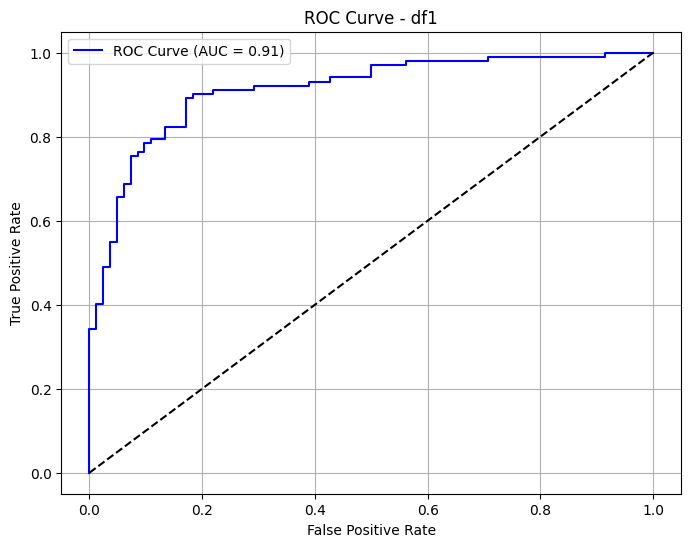

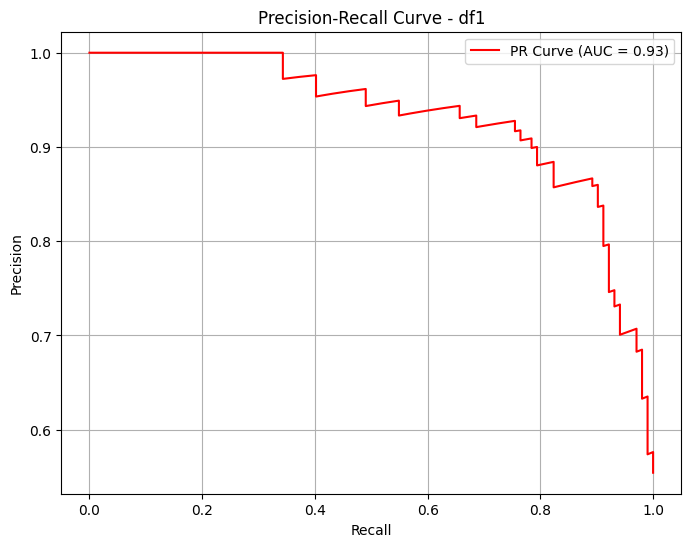

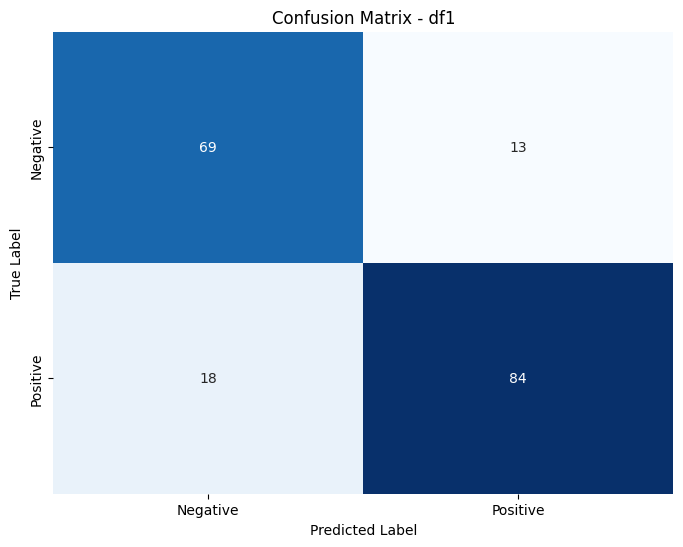


Results for df2:
Accuracy: 0.8804
Precision: 0.9082
Recall: 0.8725
F1 Score: 0.8900
ROC AUC Score: 0.9363
PR AUC Score: 0.9451
Cross-validation accuracy: 0.8486 ± 0.0233
Cross-validation PR AUC: 0.9231

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        82
           1       0.91      0.87      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
[[73  9]
 [13 89]]


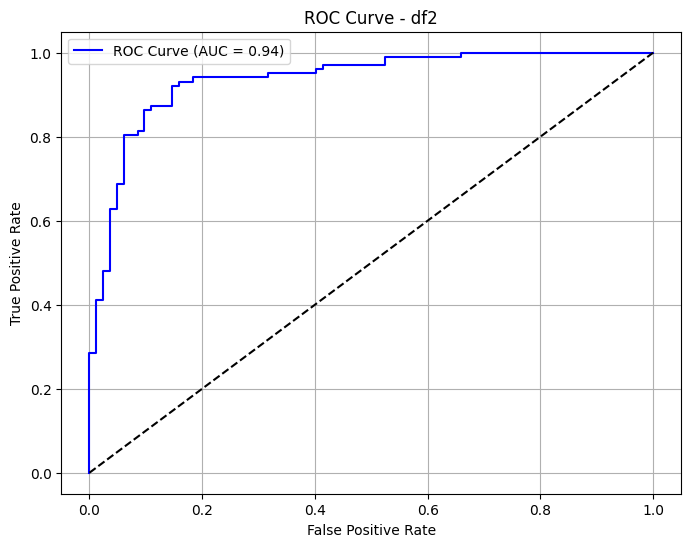

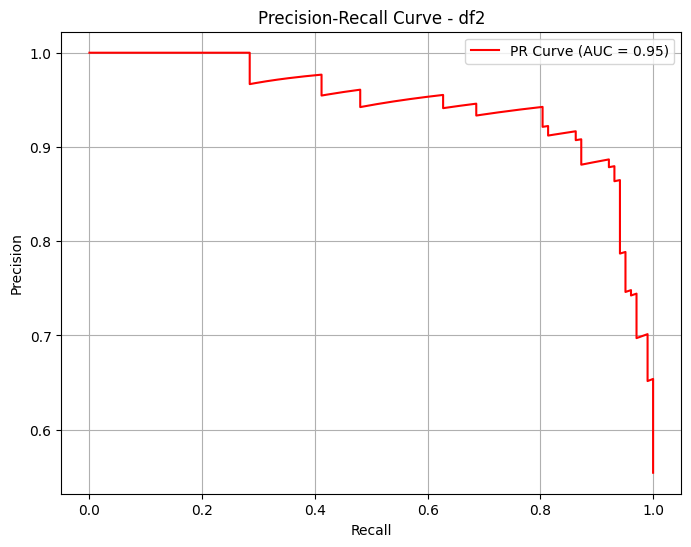

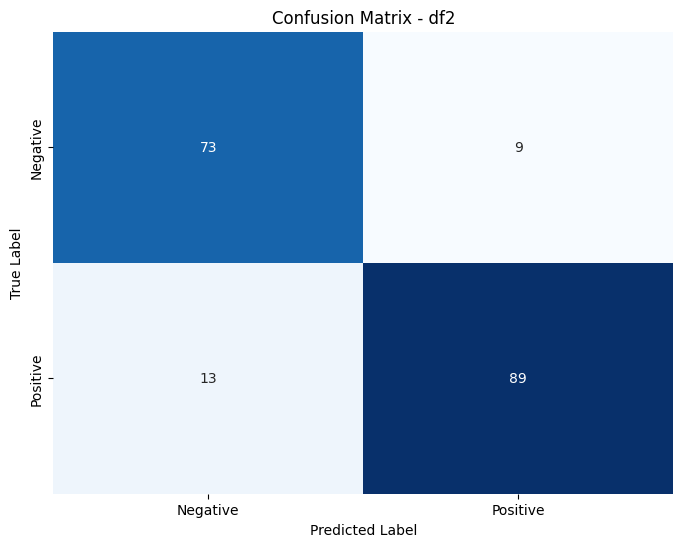


Results for df3:
Accuracy: 0.8750
Precision: 0.9072
Recall: 0.8627
F1 Score: 0.8844
ROC AUC Score: 0.9457
PR AUC Score: 0.9549
Cross-validation accuracy: 0.8508 ± 0.0307
Cross-validation PR AUC: 0.9149

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        82
           1       0.91      0.86      0.88       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
[[73  9]
 [14 88]]


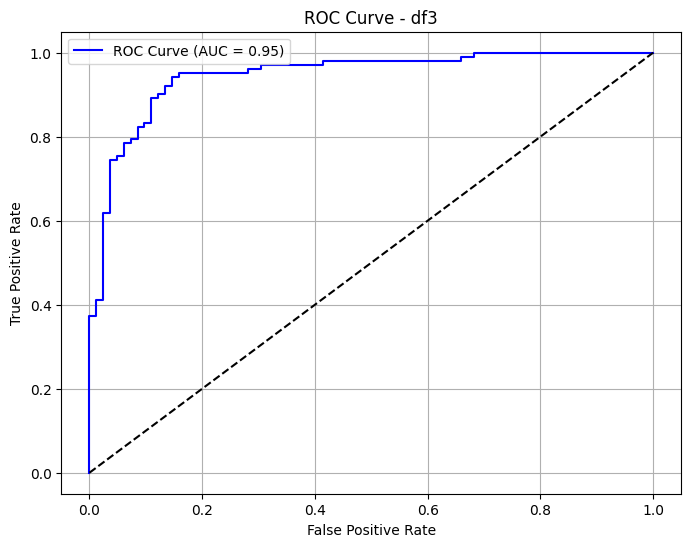

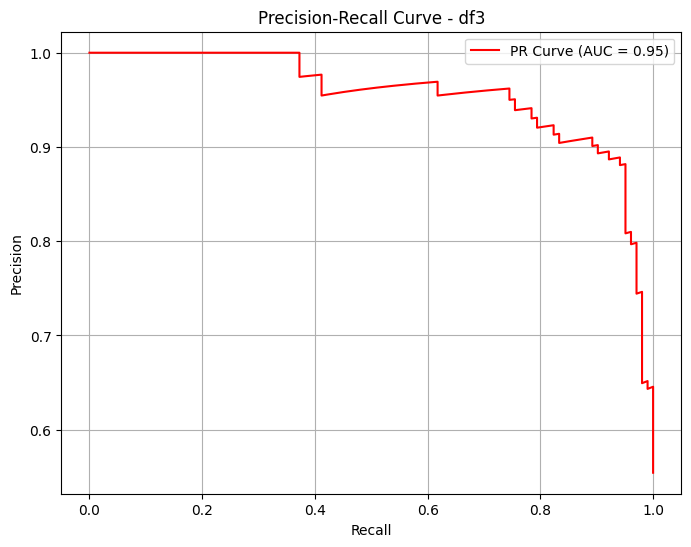

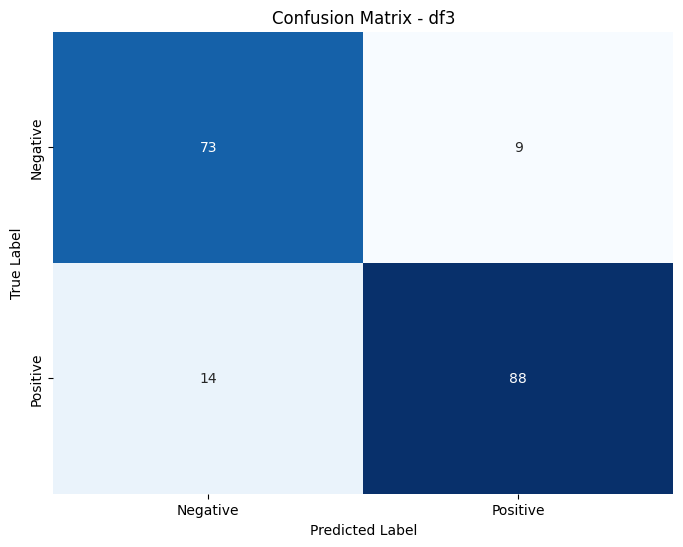


Results for df1_1:
Accuracy: 0.8261
Precision: 0.8646
Recall: 0.8137
F1 Score: 0.8384
ROC AUC Score: 0.9114
PR AUC Score: 0.9308
Cross-validation accuracy: 0.7876 ± 0.0261
Cross-validation PR AUC: 0.8726

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        82
           1       0.86      0.81      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184


Confusion Matrix:
[[69 13]
 [19 83]]


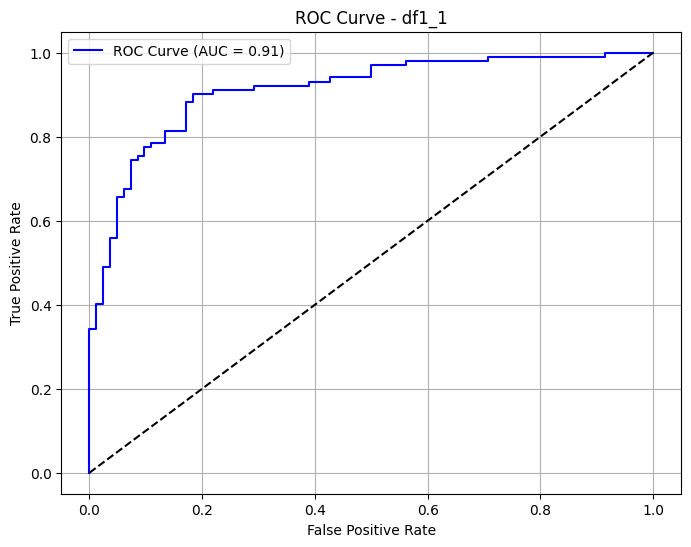

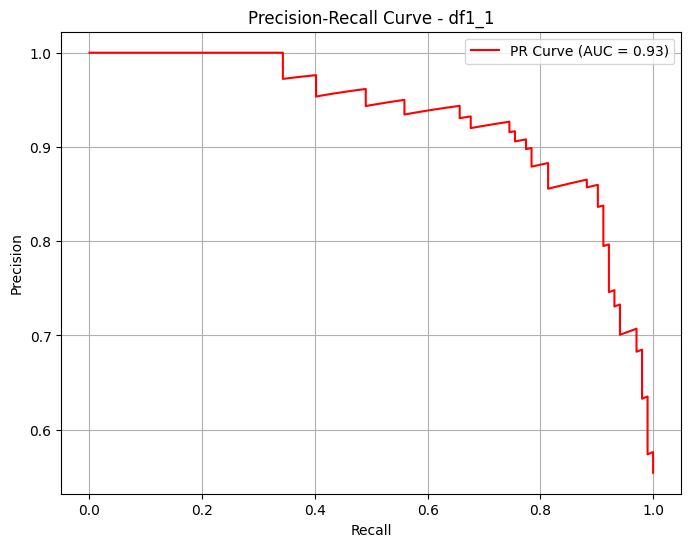

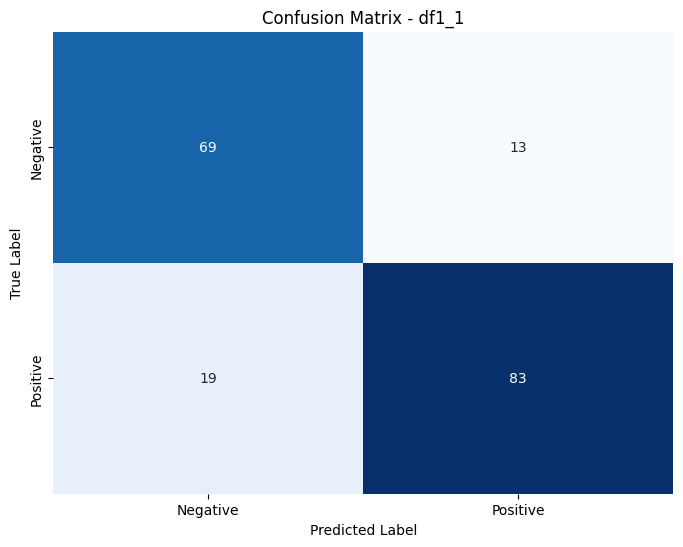


Results for df2_1:
Accuracy: 0.8750
Precision: 0.8990
Recall: 0.8725
F1 Score: 0.8856
ROC AUC Score: 0.9356
PR AUC Score: 0.9444
Cross-validation accuracy: 0.8497 ± 0.0246
Cross-validation PR AUC: 0.9220

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        82
           1       0.90      0.87      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
[[72 10]
 [13 89]]


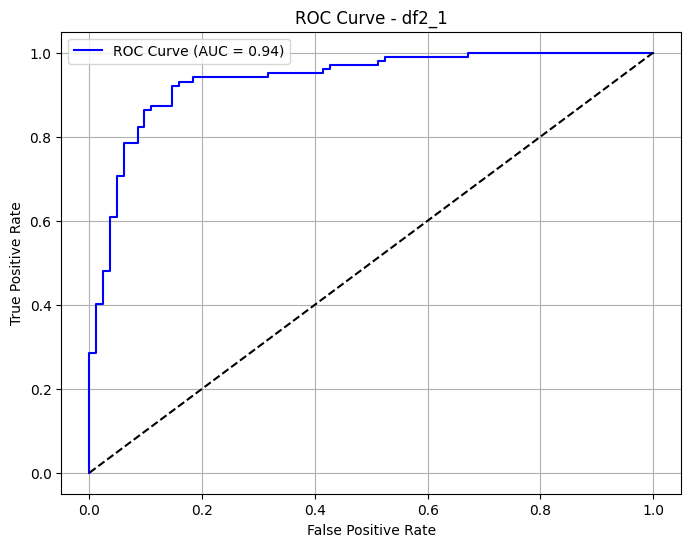

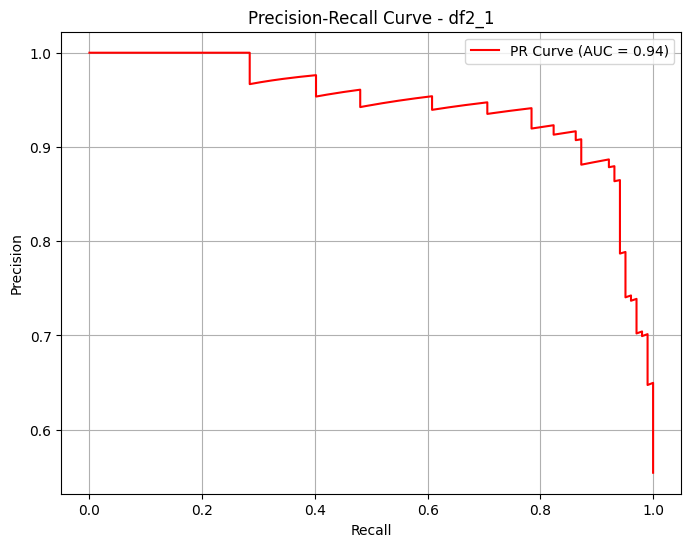

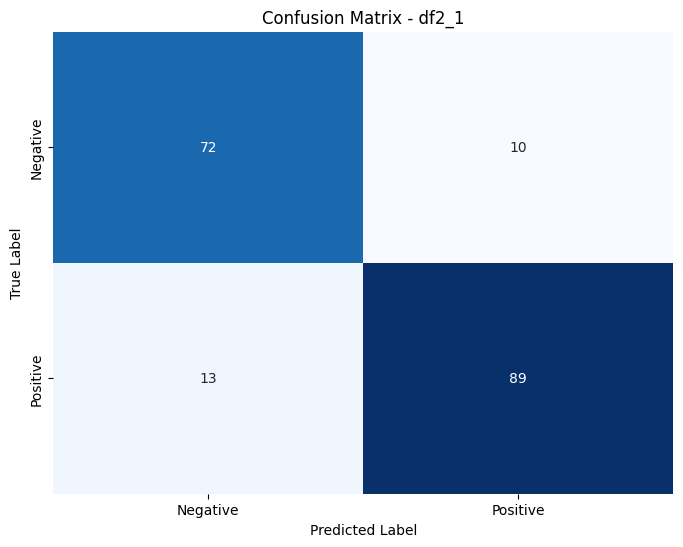


Results for df3_1:
Accuracy: 0.8750
Precision: 0.9072
Recall: 0.8627
F1 Score: 0.8844
ROC AUC Score: 0.9445
PR AUC Score: 0.9543
Cross-validation accuracy: 0.8475 ± 0.0322
Cross-validation PR AUC: 0.9140

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        82
           1       0.91      0.86      0.88       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
[[73  9]
 [14 88]]


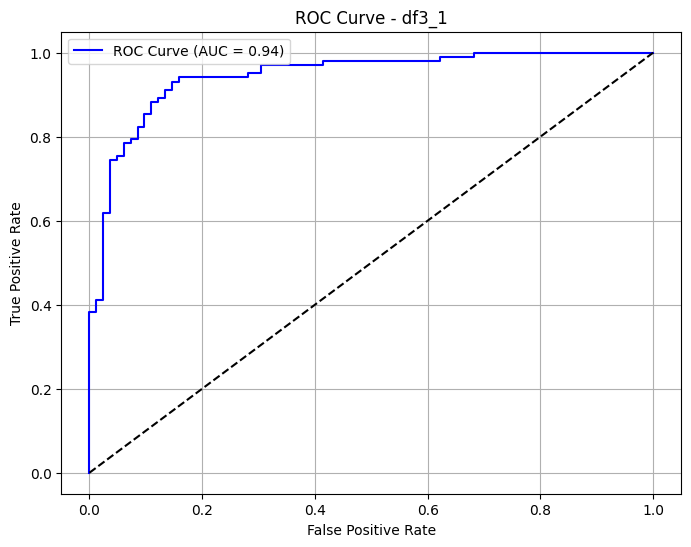

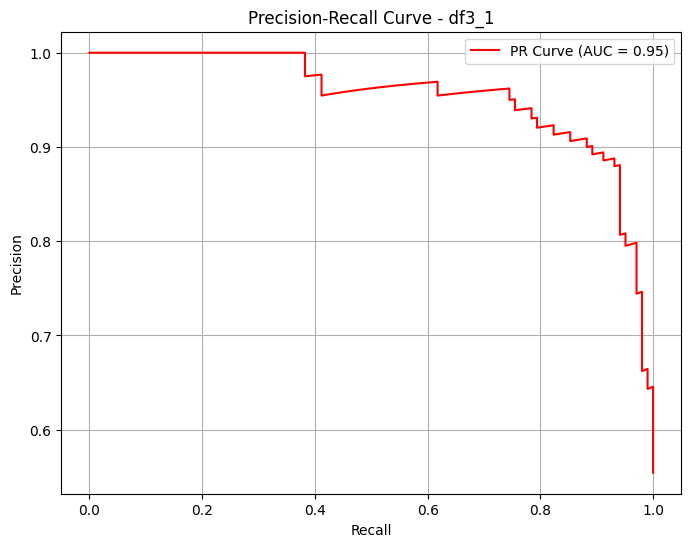

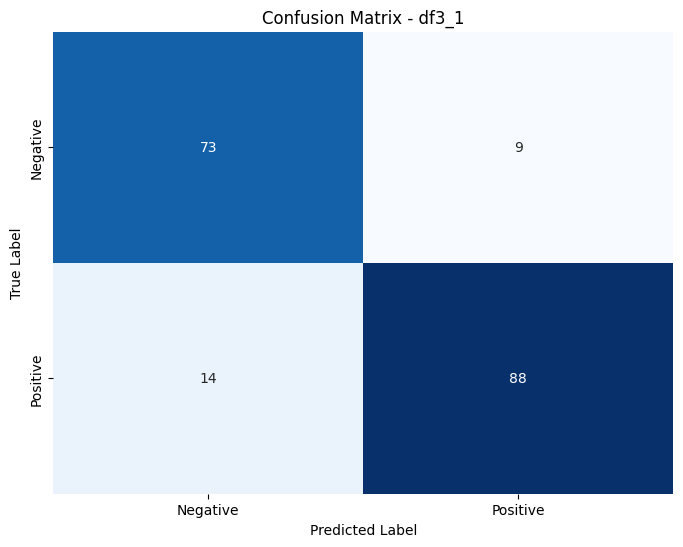


Results for df1_2:
Accuracy: 0.8261
Precision: 0.8646
Recall: 0.8137
F1 Score: 0.8384
ROC AUC Score: 0.9055
PR AUC Score: 0.9272
Cross-validation accuracy: 0.7854 ± 0.0278
Cross-validation PR AUC: 0.8681

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        82
           1       0.86      0.81      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184


Confusion Matrix:
[[69 13]
 [19 83]]


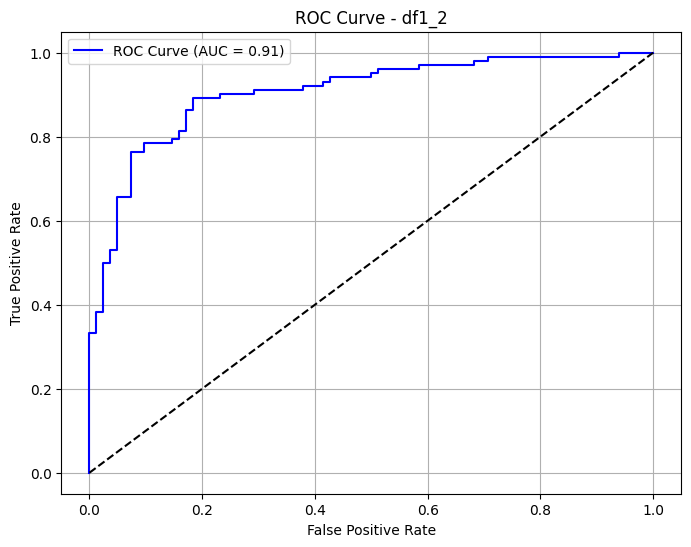

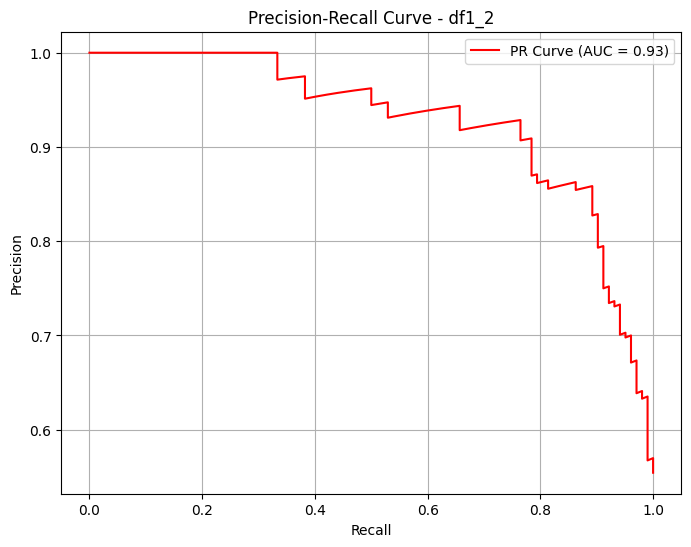

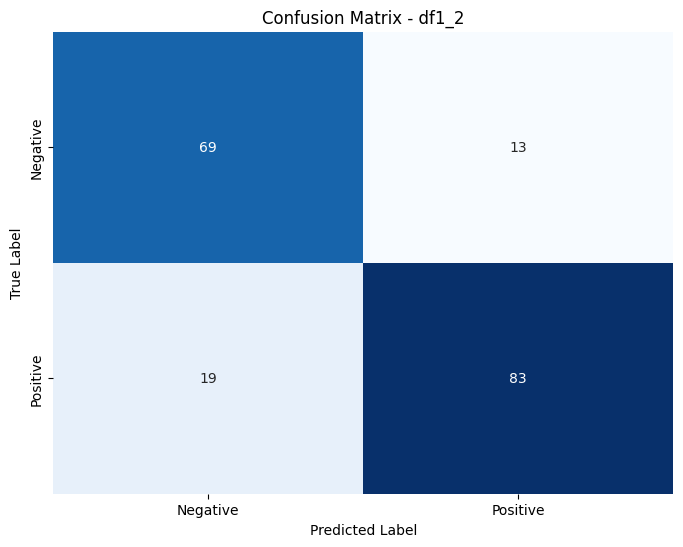


Results for df2_2:
Accuracy: 0.8587
Precision: 0.8878
Recall: 0.8529
F1 Score: 0.8700
ROC AUC Score: 0.9308
PR AUC Score: 0.9398
Cross-validation accuracy: 0.8486 ± 0.0268
Cross-validation PR AUC: 0.9189

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        82
           1       0.89      0.85      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix:
[[71 11]
 [15 87]]


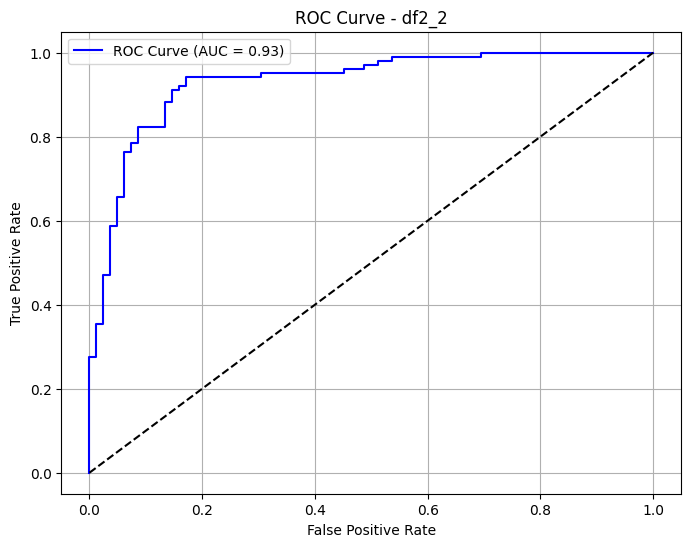

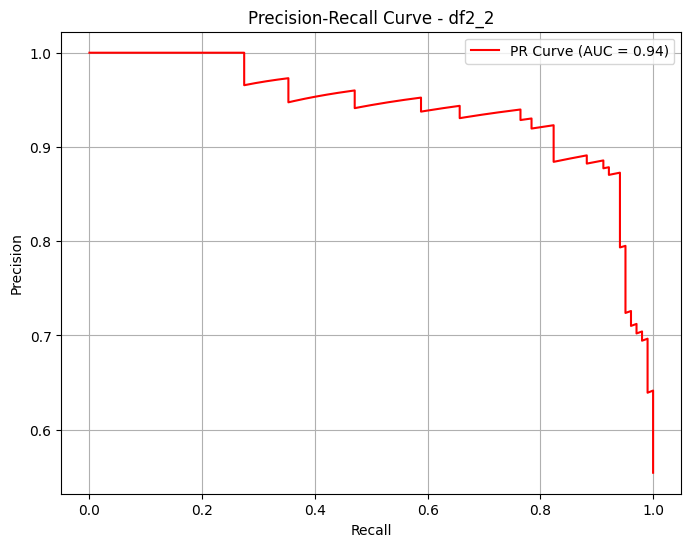

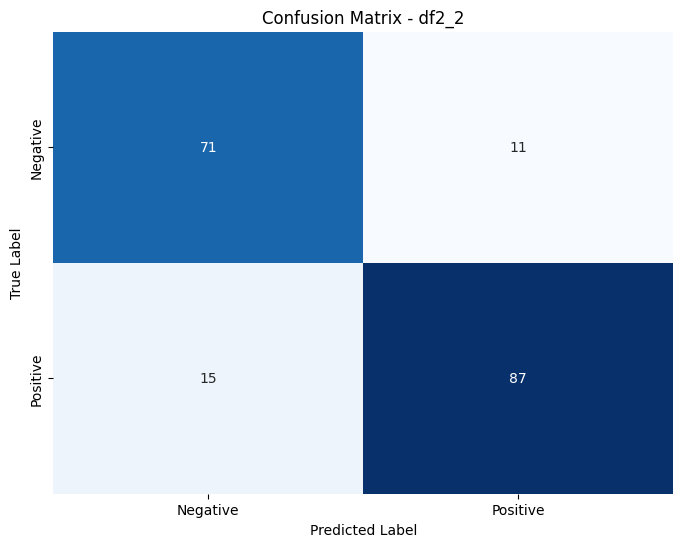


Results for df3_2:
Accuracy: 0.8696
Precision: 0.9062
Recall: 0.8529
F1 Score: 0.8788
ROC AUC Score: 0.9376
PR AUC Score: 0.9493
Cross-validation accuracy: 0.8399 ± 0.0328
Cross-validation PR AUC: 0.9110

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        82
           1       0.91      0.85      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix:
[[73  9]
 [15 87]]


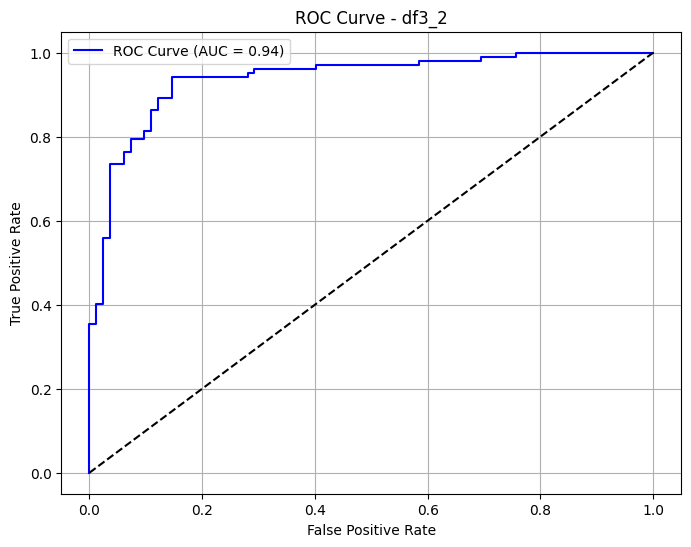

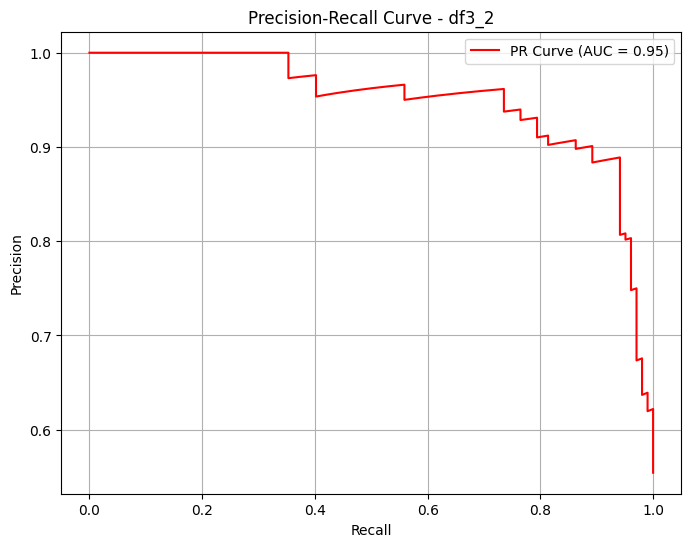

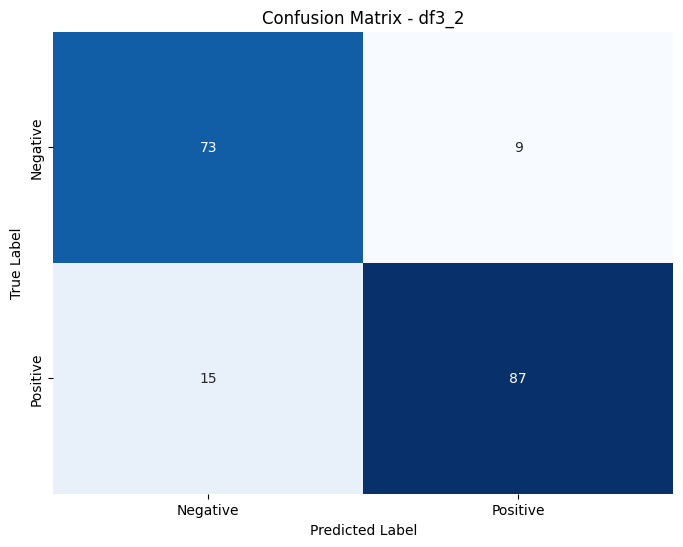

In [536]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, auc, classification_report, precision_recall_curve, roc_auc_score
)

def logistic_regression(X, y, dataset_label):
    # Stratified split to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Standardizing the dataset
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_scaled = scaler.transform(X)  # Scale for cross-validation

    # Train Logistic Regression with increased iterations and balanced class weight
    logreg = LogisticRegression(random_state=42, max_iter=10000, solver='saga', class_weight='balanced', n_jobs=-1)
    logreg.fit(X_train, y_train)

    # Get predictions
    y_pred = logreg.predict(X_test)
    y_score_logreg = logreg.predict_proba(X_test)[:, 1]

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_score_logreg)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score_logreg)
    pr_auc = auc(recall_vals, precision_vals)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(logreg, X_scaled, y, cv=cv, scoring='accuracy')

    # Compute Cross-Validation PR AUC
    y_cv_scores = cross_val_predict(logreg, X_scaled, y, cv=cv, method="predict_proba")[:, 1]
    precision_vals_cv, recall_vals_cv, _ = precision_recall_curve(y, y_cv_scores)
    cv_pr_auc = auc(recall_vals_cv, precision_vals_cv)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results["Logistic Regression"][dataset_label] = {
        "Accuracy": accuracy,
        "PR AUC": pr_auc,
        "CV Accuracy": cv_scores.mean(),
        "CV PR AUC": cv_pr_auc  # Added Cross-Validation PR AUC
    }

    # Print results
    print(f"\n{'='*50}\nResults for {dataset_label}:\n{'='*50}")
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC Score: {roc_auc:.4f}')
    print(f'PR AUC Score: {pr_auc:.4f}')
    print(f'Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'Cross-validation PR AUC: {cv_pr_auc:.4f}')
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print(f"\nConfusion Matrix:\n{cm}\n{'='*50}")

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_score_logreg)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {dataset_label}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {dataset_label}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {dataset_label}')
    plt.show()

# Example usage
datasets = {
    'df1': (df1, 'HeartDisease'),
    'df2': (df2, 'HeartDisease'),
    'df3': (df3, 'HeartDisease'),
    'df1_1': (df1_1, 'HeartDisease'),
    'df2_1': (df2_1, 'HeartDisease'),
    'df3_1': (df3_1, 'HeartDisease'),
    'df1_2': (df1_2, 'HeartDisease'),
    'df2_2': (df2_2, 'HeartDisease'),
    'df3_2': (df3_2, 'HeartDisease')
}

for label, (df, target) in datasets.items():
    X = df.drop(columns=[target])
    y = df[target]
    logistic_regression(X, y, label)


In [537]:
print(results)

{'KNN': {'df1': {'Optimal k': 9, 'PR AUC': 0.8661767055663664, 'CV PR AUC': 0.8526974940210609, 'Accuracy': 0.7391304347826086, 'CV Accuracy': 0.7943062156369397}, 'df2': {'Optimal k': 23, 'PR AUC': 0.940724184328848, 'CV PR AUC': 0.9007984213041823, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8610753890597334}, 'df3': {'Optimal k': 19, 'PR AUC': 0.9503411952365282, 'CV PR AUC': 0.9049450132273993, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8664616531544125}, 'df1_1': {'Optimal k': 25, 'PR AUC': 0.8673937896519223, 'CV PR AUC': 0.8691450042725279, 'Accuracy': 0.7445652173913043, 'CV Accuracy': 0.8024601621470506}, 'df2_1': {'Optimal k': 21, 'PR AUC': 0.9306504181321884, 'CV PR AUC': 0.8928091809027695, 'Accuracy': 0.8532608695652174, 'CV Accuracy': 0.8515515795359239}, 'df3_1': {'Optimal k': 17, 'PR AUC': 0.9493758927476706, 'CV PR AUC': 0.9041115771224879, 'Accuracy': 0.8695652173913043, 'CV Accuracy': 0.8637405647190383}, 'df1_2': {'Optimal k': 25, 'PR AUC': 0.846583214543

# Decision Tree

In [538]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import auc, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score,precision_recall_curve, make_scorer, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from six import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.7907 ± 0.0488
Cross-validation PR AUC: 0.8053 ± 0.0205
Classification Report for df1: 
              precision    recall  f1-score   support

           0       0.57      0.79      0.66        77
           1       0.79      0.57      0.66       107

    accuracy                           0.66       184
   macro avg       0.68      0.68      0.66       184
weighted avg       0.70      0.66      0.66       184

PR AUC: 0.8323169045027146
Accuracy for df1: 0.66


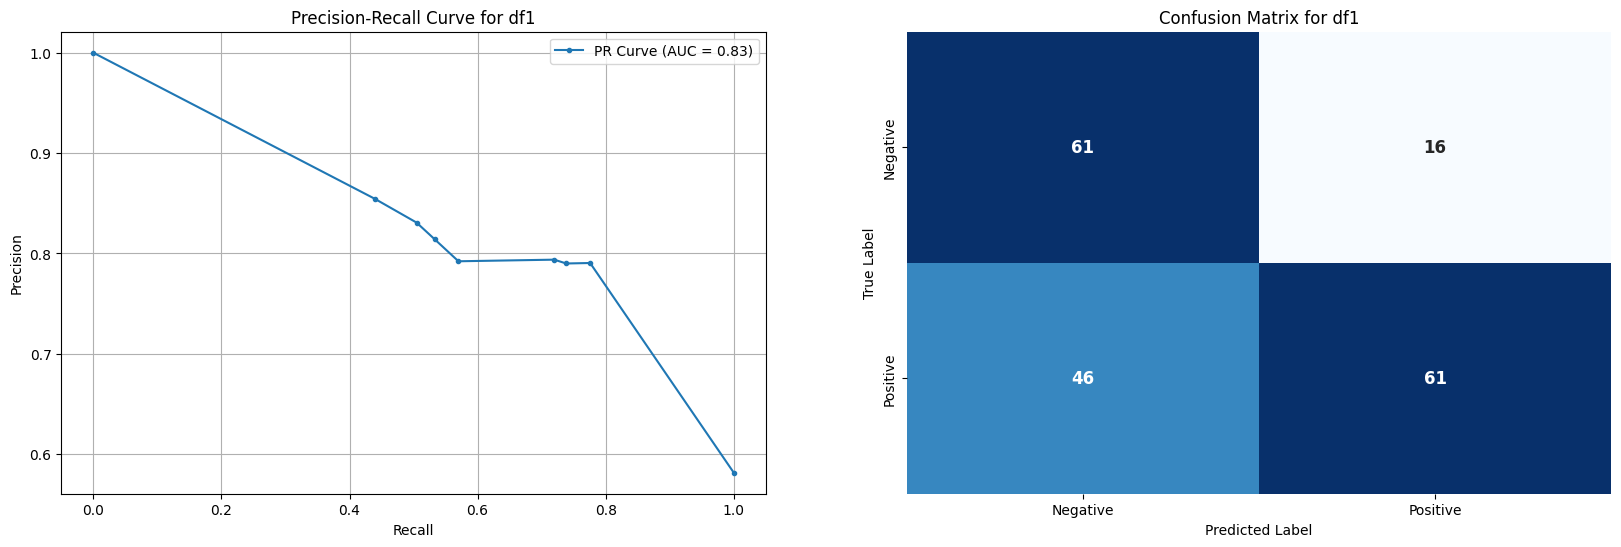

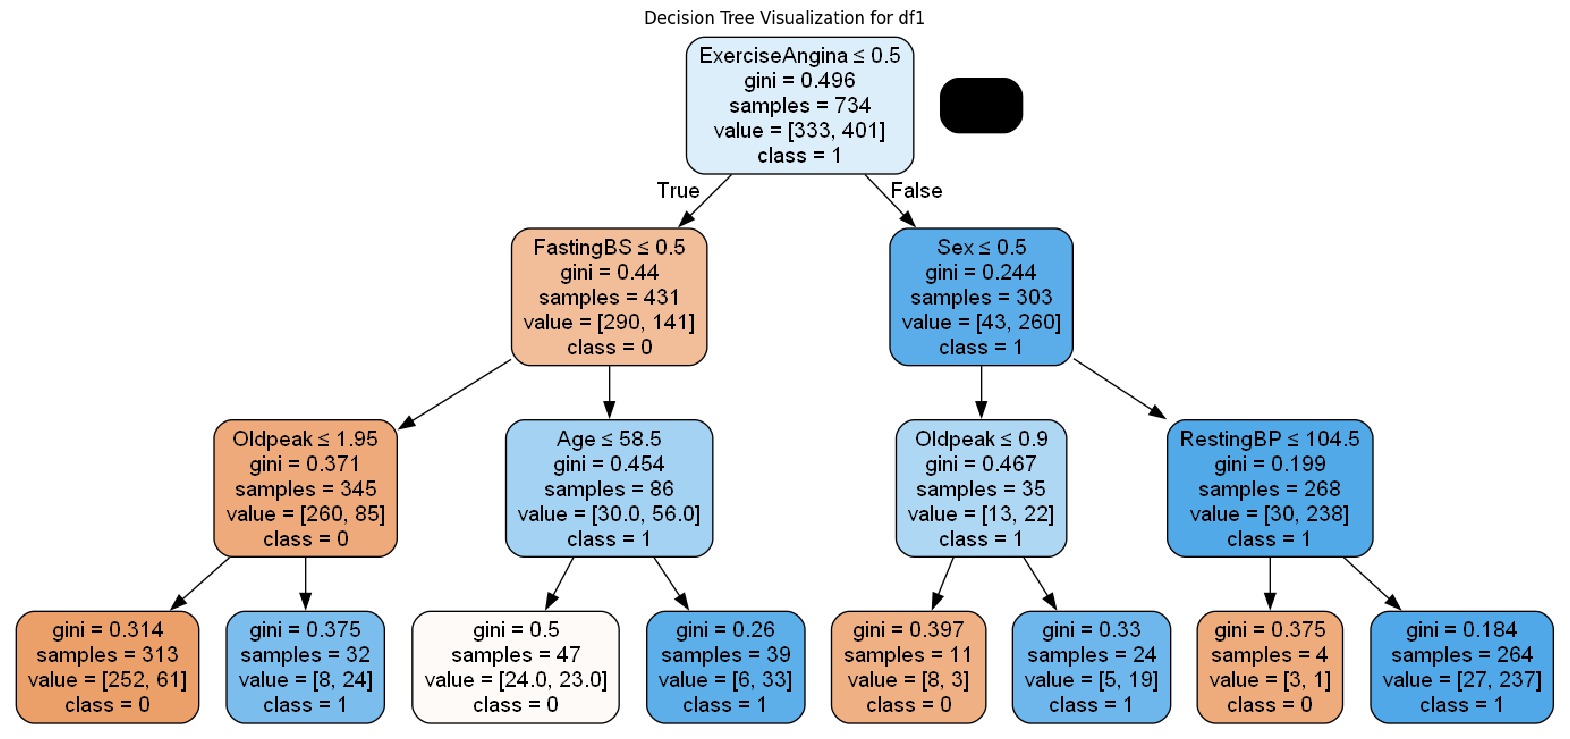

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.8093 ± 0.0360
Cross-validation PR AUC: 0.8499 ± 0.0473
Classification Report for df2: 
              precision    recall  f1-score   support

           0       0.71      0.82      0.76        77
           1       0.85      0.76      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184

PR AUC: 0.9062227481716154
Accuracy for df2: 0.78


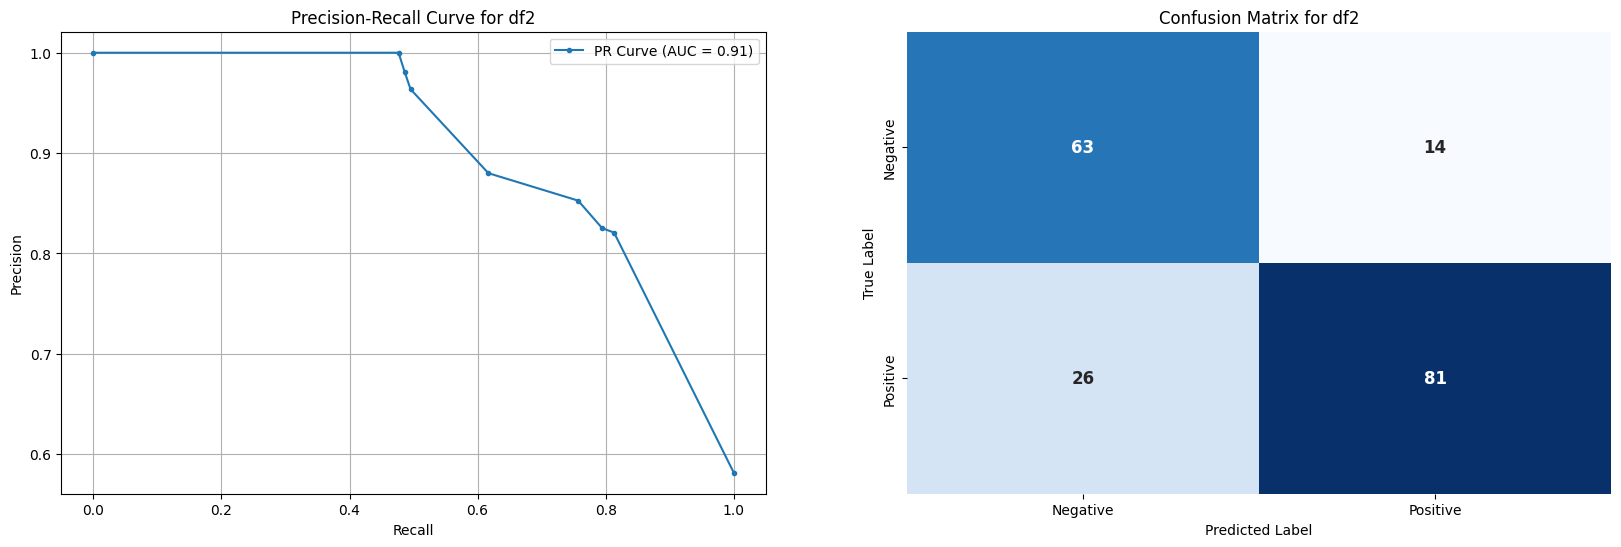

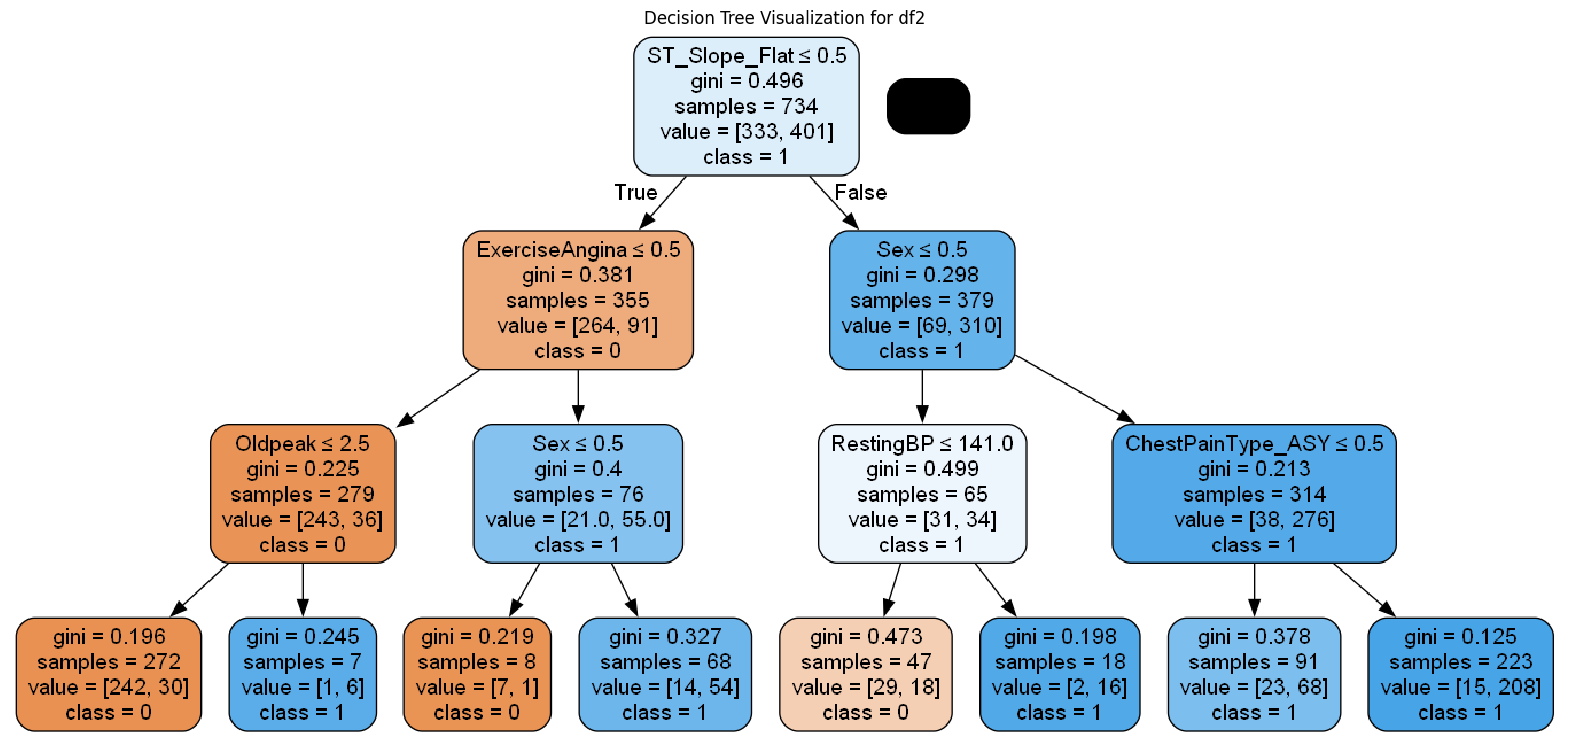

Optimal parameters: {'criterion': 'entropy', 'max_depth': 6}
Cross-validation Accuracy: 0.8006 ± 0.0543
Cross-validation PR AUC: 0.8385 ± 0.0604
Classification Report for df3: 
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        77
           1       0.89      0.79      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184

PR AUC: 0.9231186897082495
Accuracy for df3: 0.82


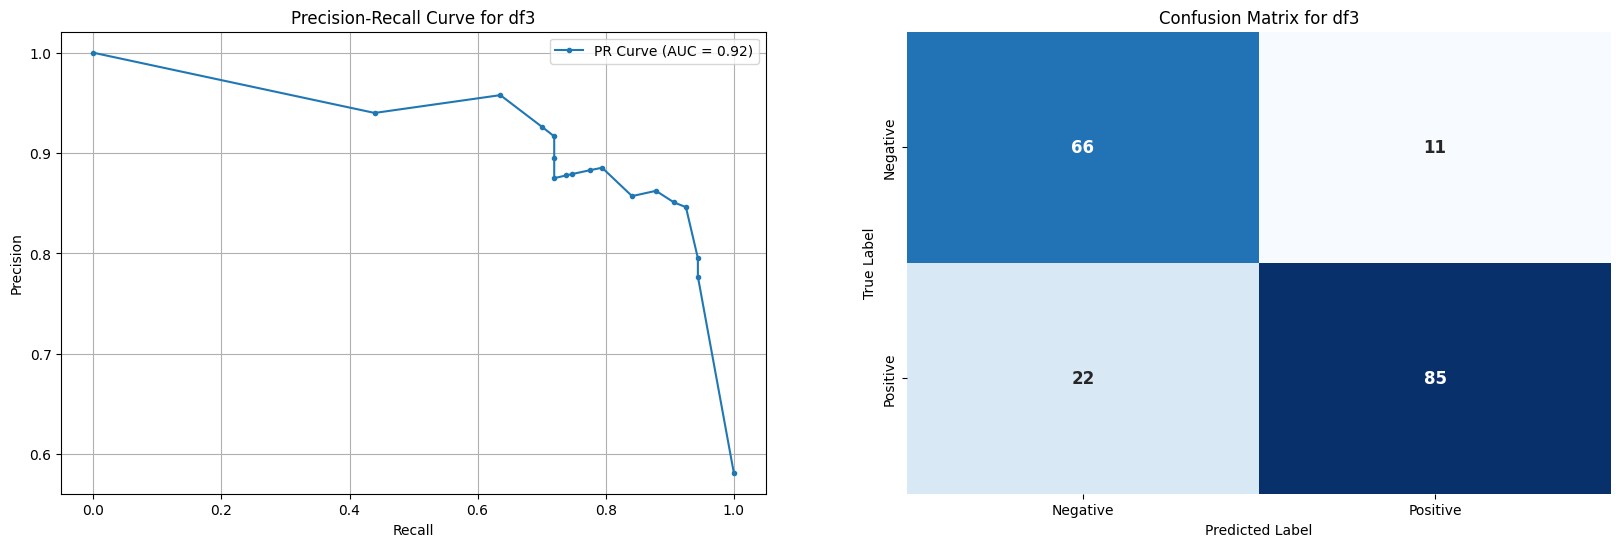

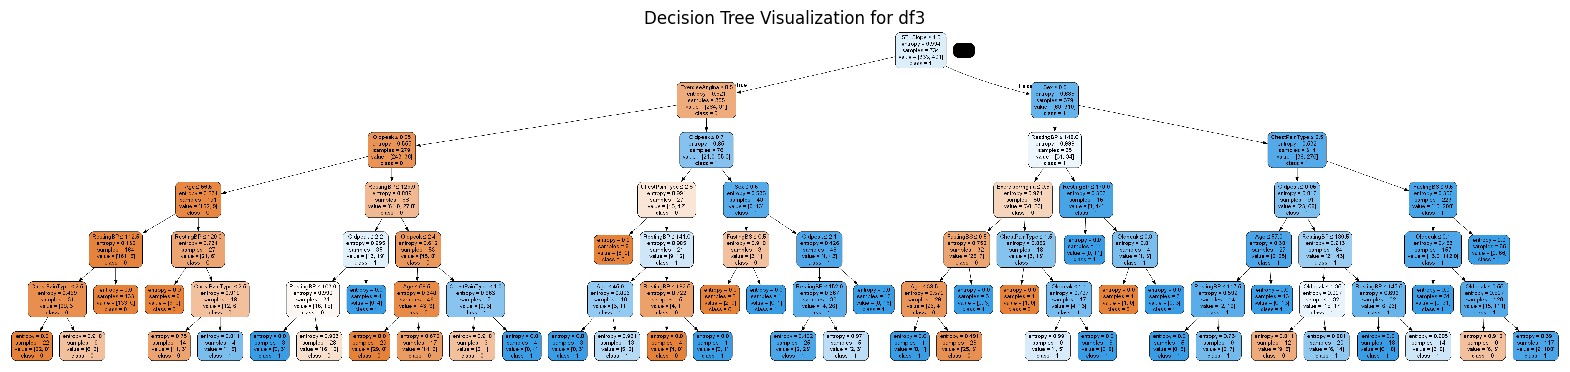

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.7907 ± 0.0488
Cross-validation PR AUC: 0.8053 ± 0.0205
Classification Report for df1_1: 
              precision    recall  f1-score   support

           0       0.57      0.79      0.66        77
           1       0.79      0.57      0.66       107

    accuracy                           0.66       184
   macro avg       0.68      0.68      0.66       184
weighted avg       0.70      0.66      0.66       184

PR AUC: 0.8323169045027146
Accuracy for df1_1: 0.66


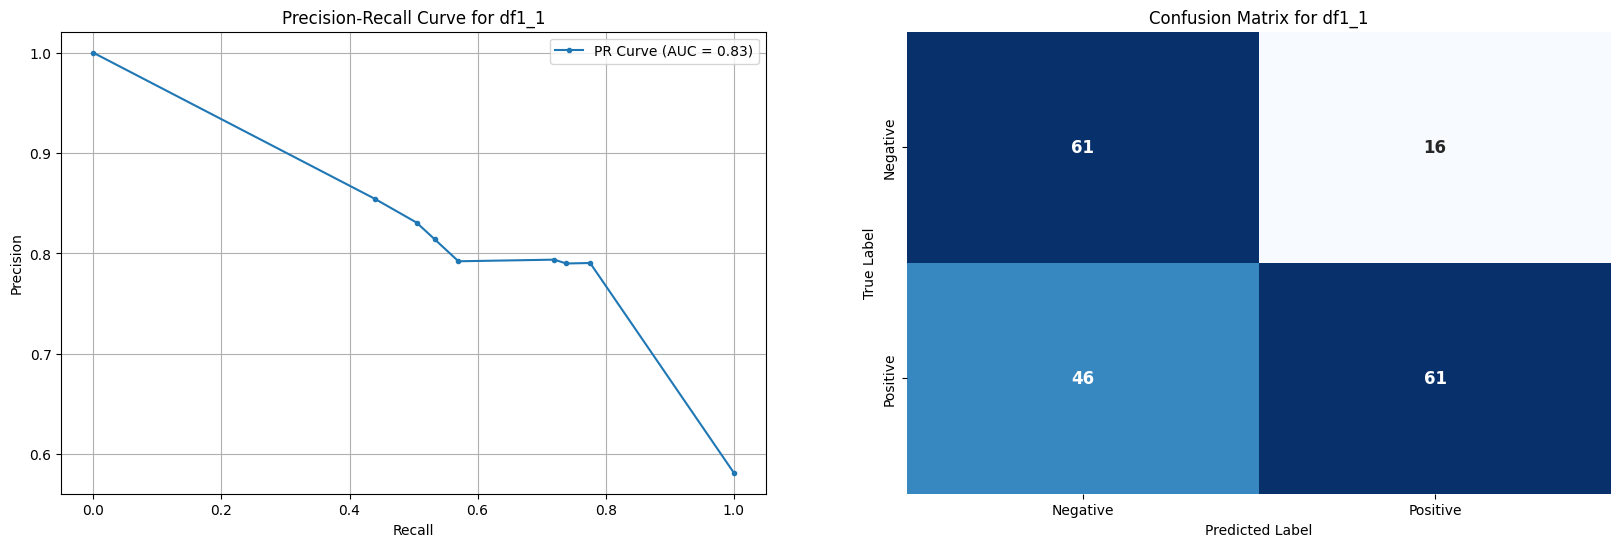

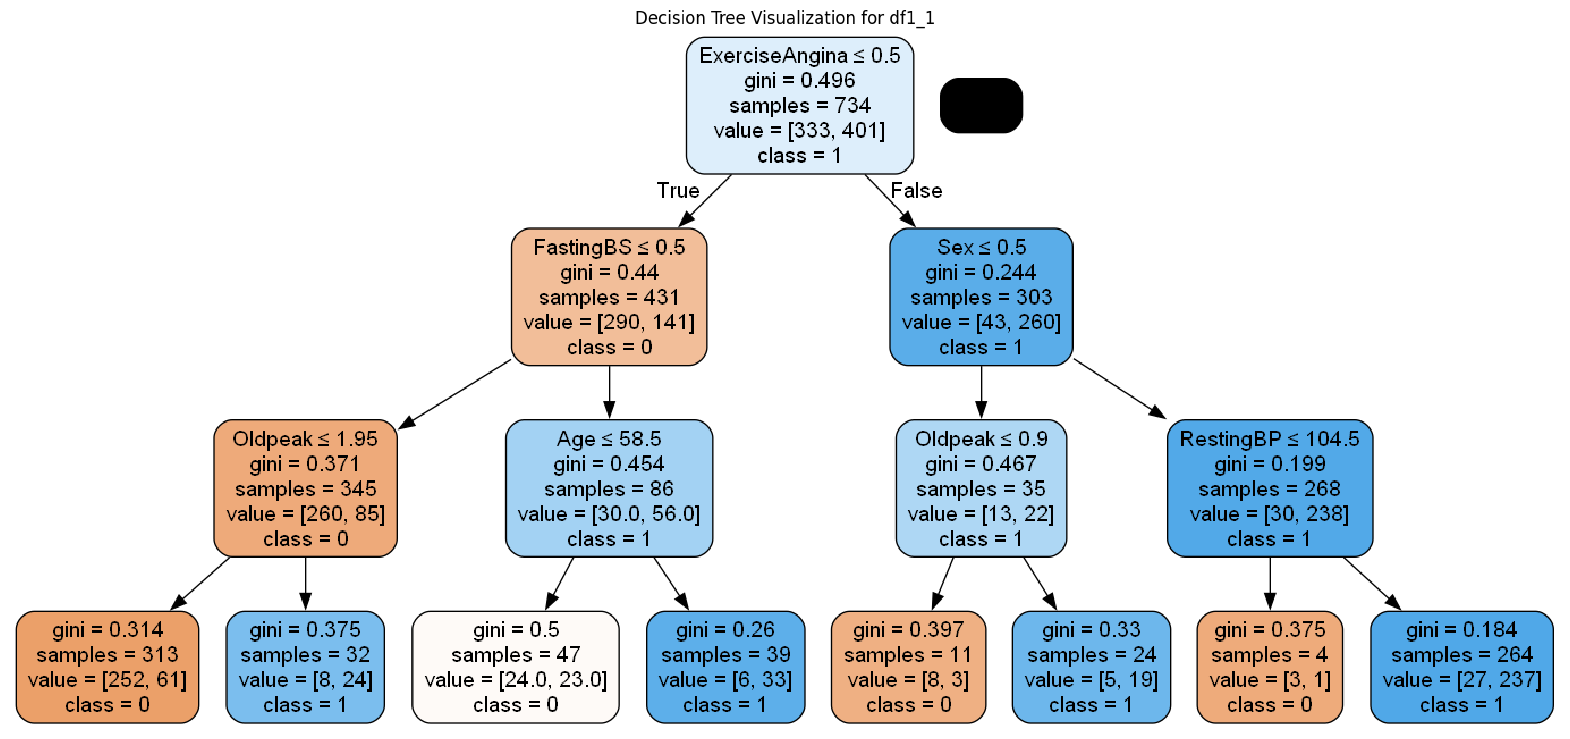

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.8093 ± 0.0360
Cross-validation PR AUC: 0.8499 ± 0.0473
Classification Report for df2_1: 
              precision    recall  f1-score   support

           0       0.71      0.82      0.76        77
           1       0.85      0.76      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184

PR AUC: 0.9062227481716154
Accuracy for df2_1: 0.78


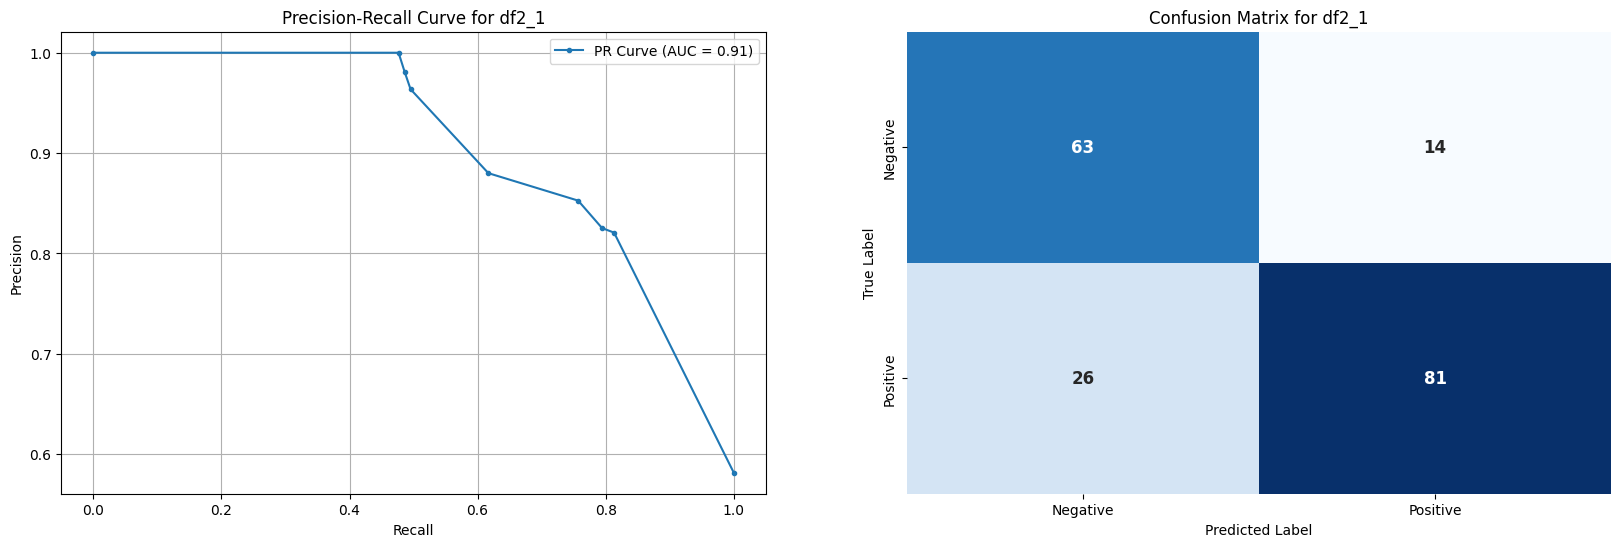

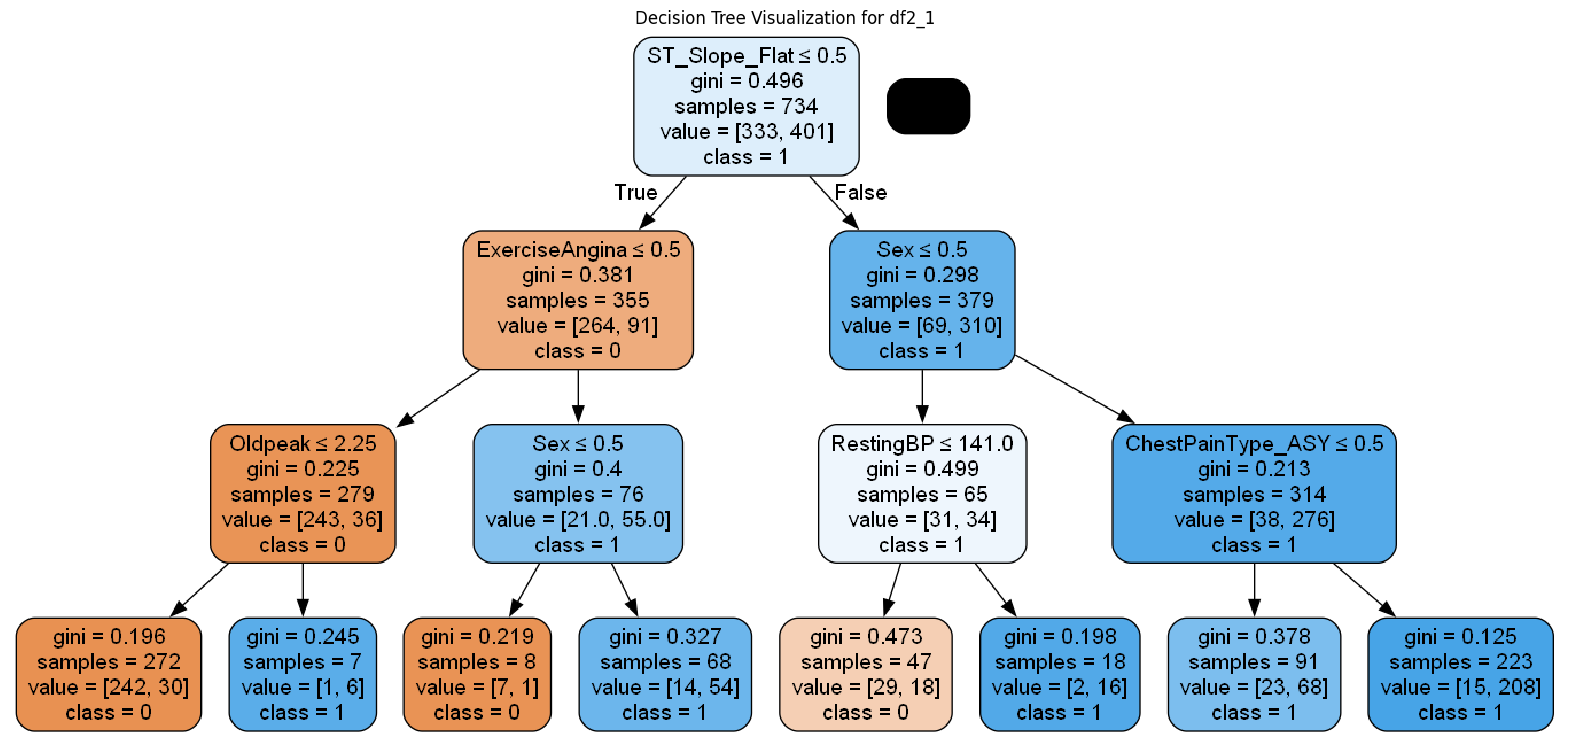

Optimal parameters: {'criterion': 'entropy', 'max_depth': 6}
Cross-validation Accuracy: 0.8017 ± 0.0560
Cross-validation PR AUC: 0.8413 ± 0.0622
Classification Report for df3_1: 
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        77
           1       0.89      0.79      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184

PR AUC: 0.9231186897082495
Accuracy for df3_1: 0.82


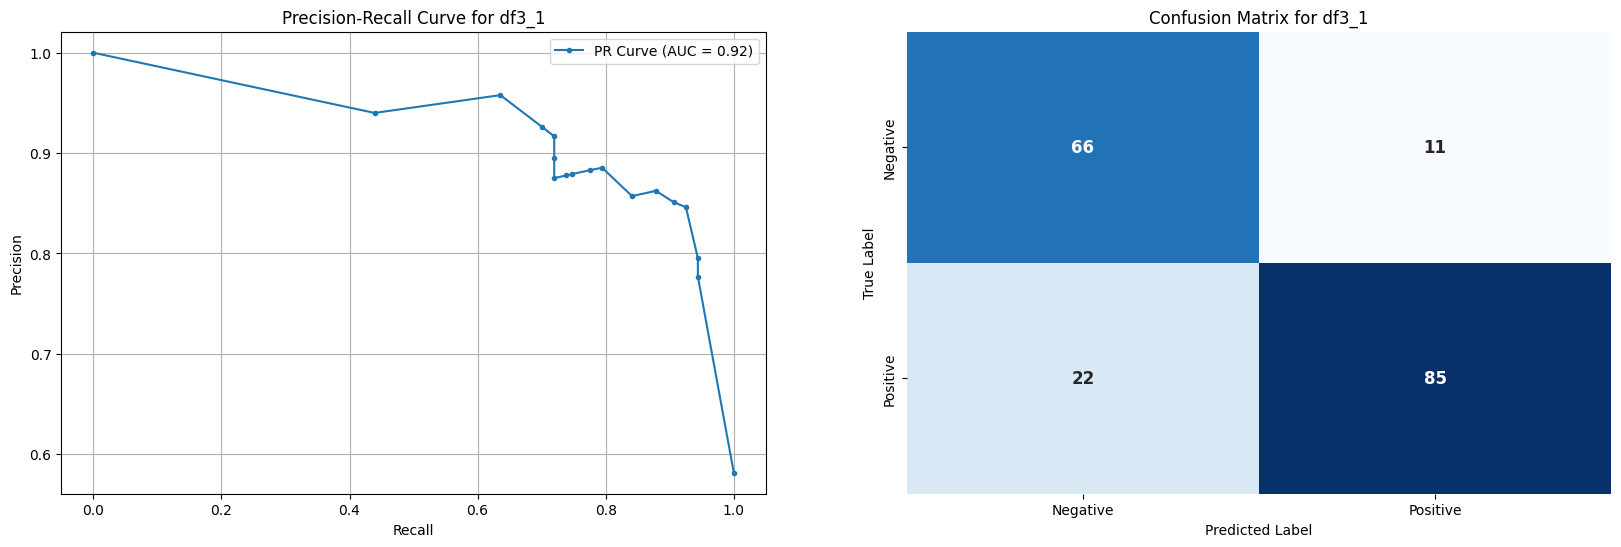

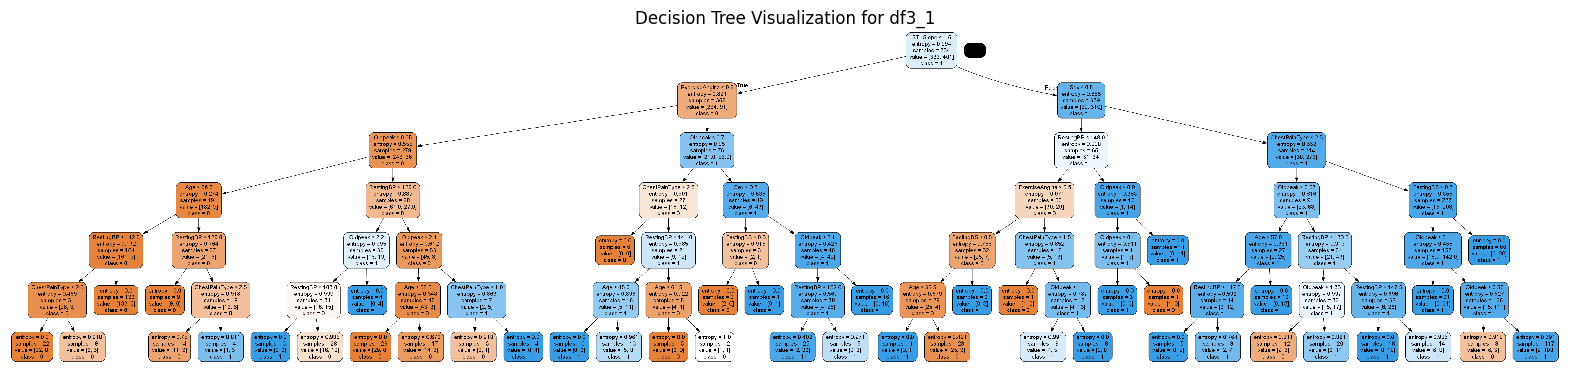

Optimal parameters: {'criterion': 'gini', 'max_depth': 4}
Cross-validation Accuracy: 0.7614 ± 0.0403
Cross-validation PR AUC: 0.8112 ± 0.0261
Classification Report for df1_2: 
              precision    recall  f1-score   support

           0       0.58      0.78      0.66        77
           1       0.79      0.59      0.67       107

    accuracy                           0.67       184
   macro avg       0.68      0.68      0.67       184
weighted avg       0.70      0.67      0.67       184

PR AUC: 0.7941880061697386
Accuracy for df1_2: 0.67


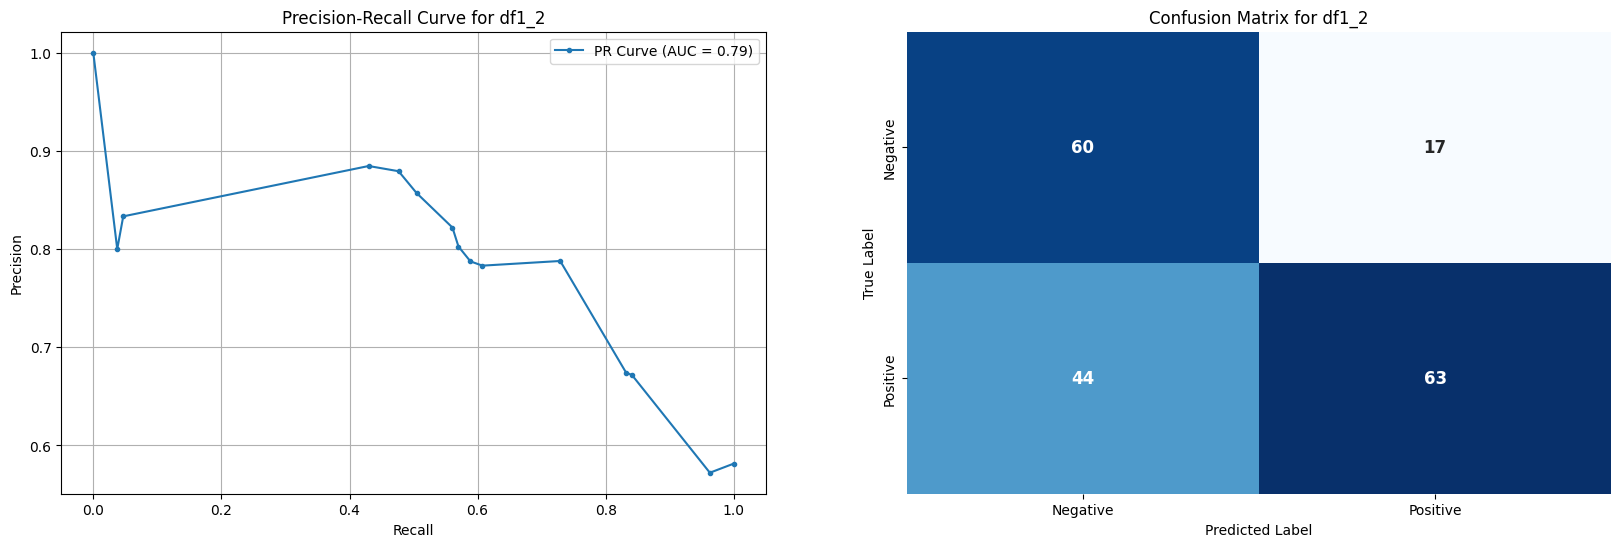

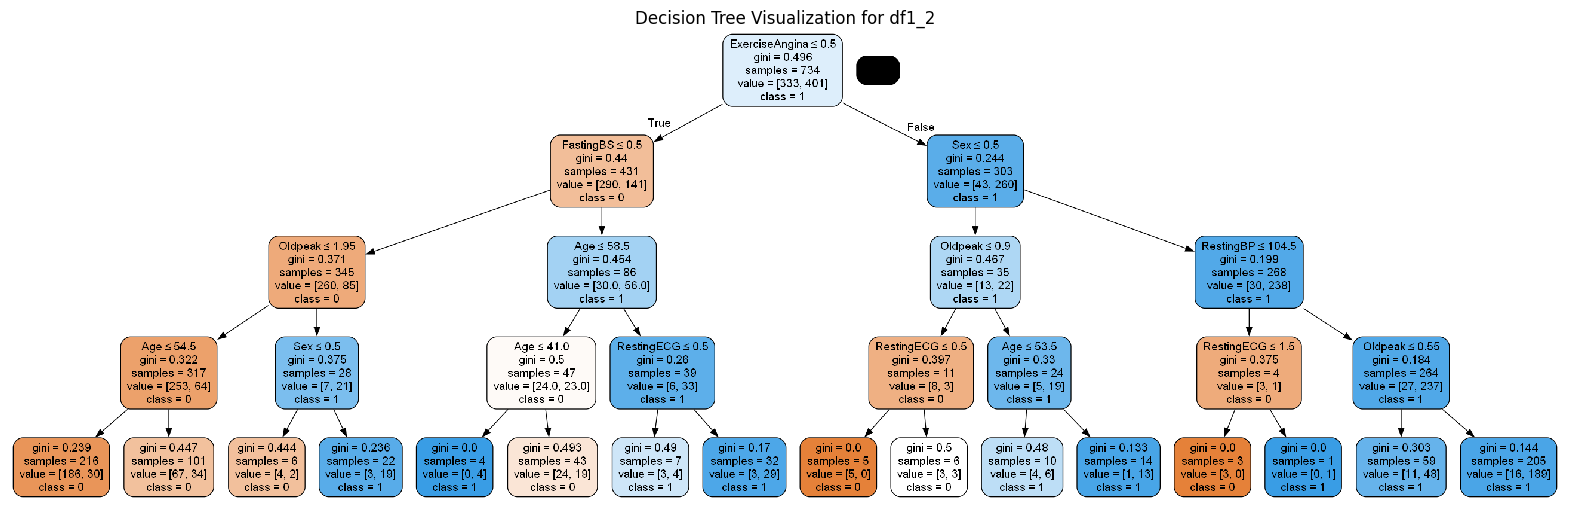

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.8093 ± 0.0348
Cross-validation PR AUC: 0.8535 ± 0.0501
Classification Report for df2_2: 
              precision    recall  f1-score   support

           0       0.71      0.81      0.76        77
           1       0.85      0.77      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184

PR AUC: 0.9117772213410942
Accuracy for df2_2: 0.78


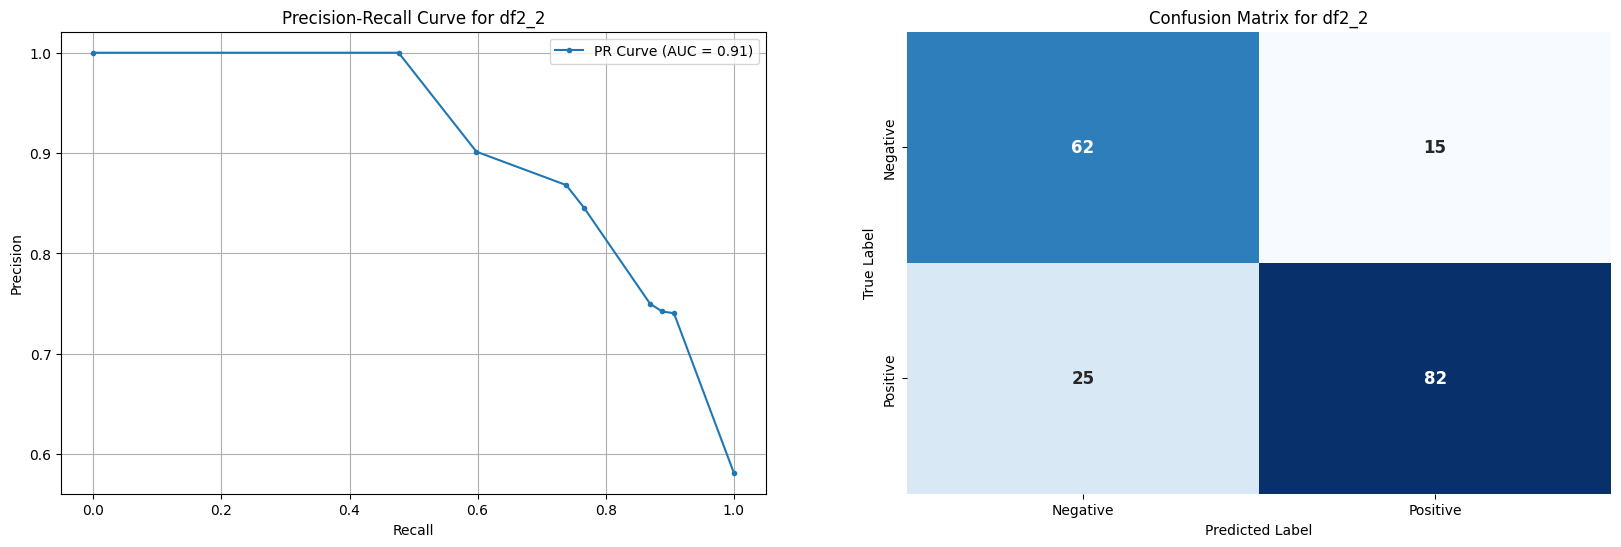

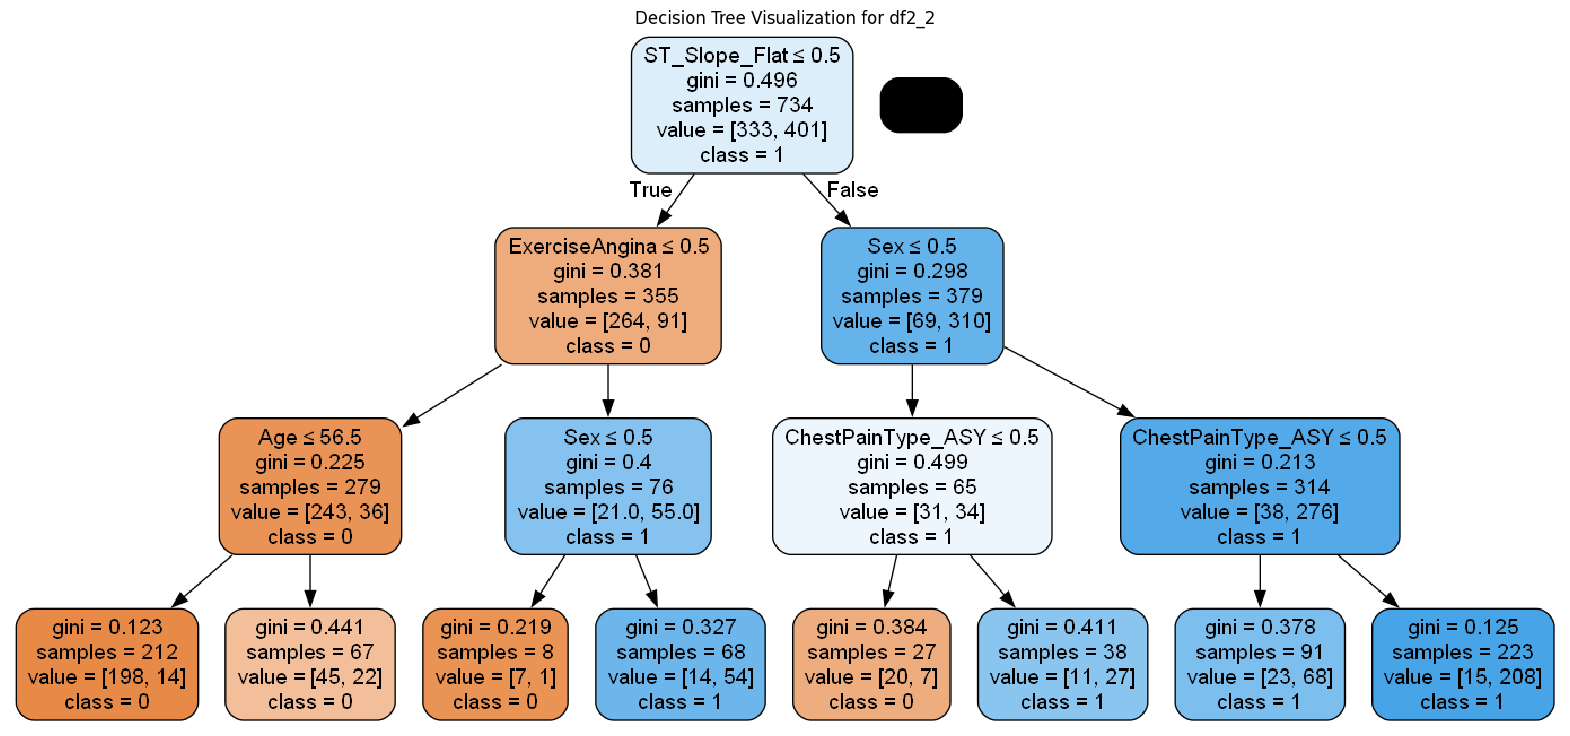

Optimal parameters: {'criterion': 'gini', 'max_depth': 3}
Cross-validation Accuracy: 0.8192 ± 0.0327
Cross-validation PR AUC: 0.8416 ± 0.0496
Classification Report for df3_2: 
              precision    recall  f1-score   support

           0       0.74      0.84      0.79        77
           1       0.88      0.79      0.83       107

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.81      0.81       184

PR AUC: 0.9222288277024597
Accuracy for df3_2: 0.81


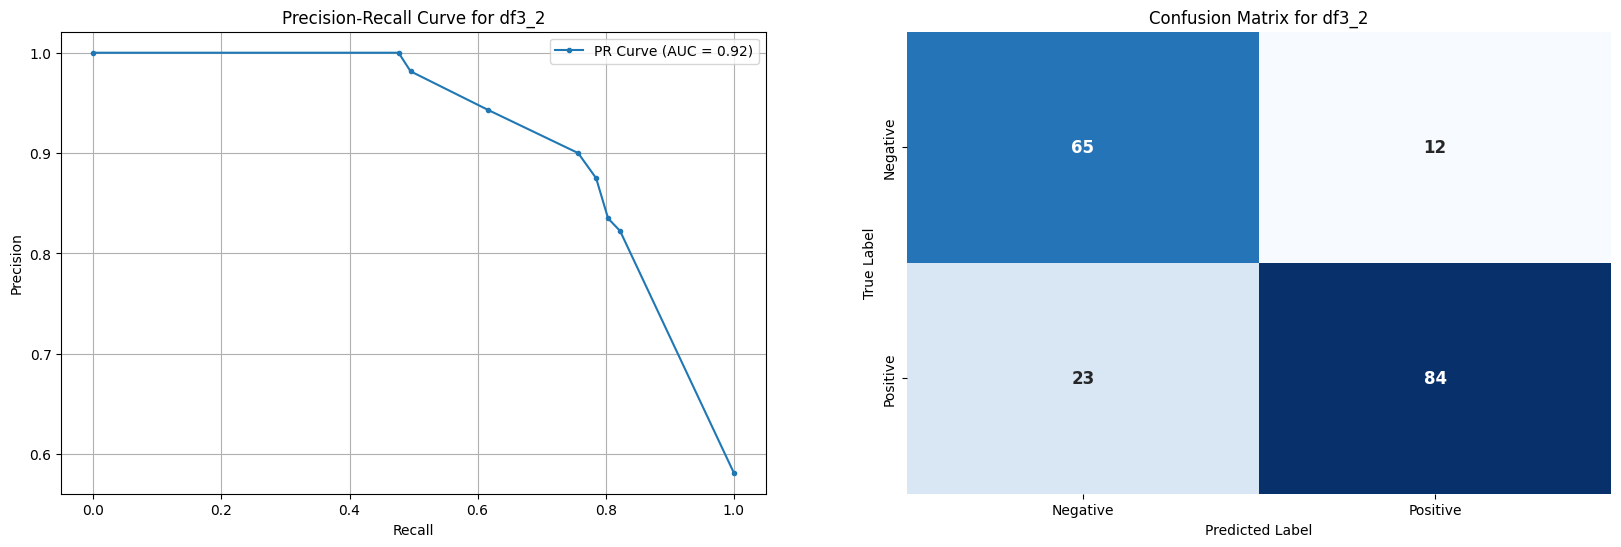

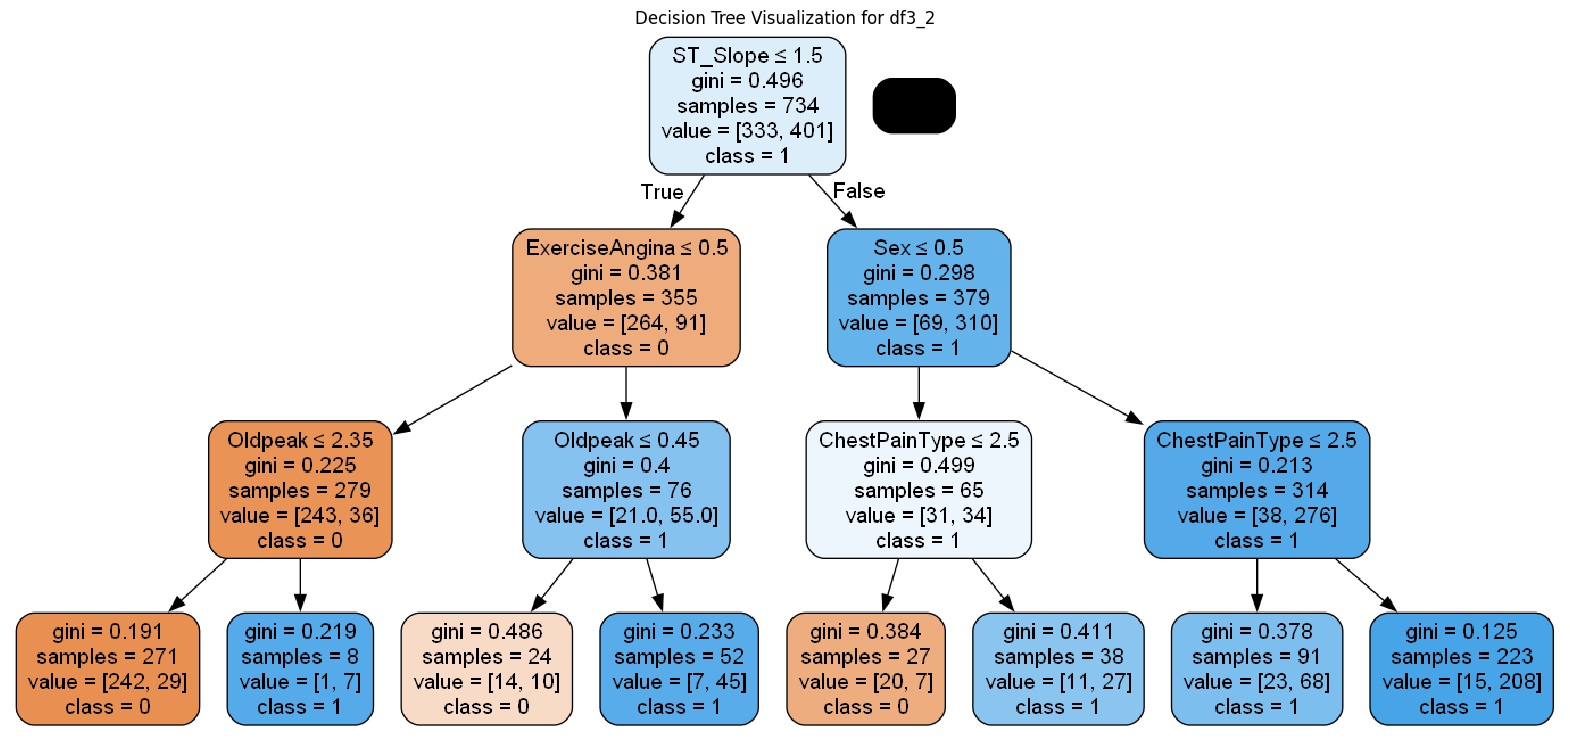

In [539]:
def evaluate_decision_tree(X, y, dataset_label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define the hyperparameter grid for GridSearchCV
    param_grid = {'max_depth': range(3, 11),
                  'criterion': ['gini', 'entropy'] }

    # Initialize GridSearchCV with cross-validation and average precision score as the scoring metric
    grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, 
                               scoring=make_scorer(average_precision_score), cv=5)
    grid_search.fit(X_train, y_train)

    # Get the best hyperparameters and the best model
    best_params = grid_search.best_params_
    print(f'Optimal parameters: {best_params}')
    best_decisiontree = grid_search.best_estimator_

    # Perform cross-validation on the best model
    cv_scores = cross_val_score(best_decisiontree, X, y, cv=5, scoring='accuracy')
    cv_pr_auc_scores = cross_val_score(best_decisiontree, X, y, cv=5, scoring='average_precision')

    print(f'Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'Cross-validation PR AUC: {cv_pr_auc_scores.mean():.4f} ± {cv_pr_auc_scores.std():.4f}')

    # Get the predicted probabilities for the positive class
    y_scores = best_decisiontree.predict_proba(X_test)[:, 1]
    y_pred = best_decisiontree.predict(X_test)

    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Generate classification report
    class_report = classification_report(y_test, y_pred)
    print(f'Classification Report for {dataset_label}: \n{class_report}')

    # Calculate precision and recall values
    precision, recall, _ = precision_recall_curve(y_test, y_scores)

    # Calculate the area under the PR curve
    pr_auc = auc(recall, precision)
    print(f'PR AUC: {pr_auc}')

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy for {dataset_label}: {accuracy:.2f}')

    # Store results
    results["Decision Tree"][dataset_label] = {
        "Accuracy": accuracy,
        "PR AUC": pr_auc,
        "CV Accuracy": cv_scores.mean(),
        "CV PR AUC": cv_pr_auc_scores.mean()
    }

    # Create subplots for the PR curve and confusion matrix
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    
    # Plot the PR curve
    ax[0].plot(recall, precision, marker='.', label=f'PR Curve (AUC = {pr_auc:.2f})')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title(f'Precision-Recall Curve for {dataset_label}')
    ax[0].legend()
    ax[0].grid(True)

    # Plot confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
                annot_kws={"fontsize": 12, "fontweight": "bold", "ha": "center", "va": "center"}, ax=ax[1])
    ax[1].set_title(f'Confusion Matrix for {dataset_label}')
    ax[1].set_xlabel('Predicted Label')
    ax[1].set_ylabel('True Label')
    ax[1].set_xticklabels(['Negative', 'Positive'])
    ax[1].set_yticklabels(['Negative', 'Positive'])

    plt.show()

    # Visualize the Decision Tree
    dot_data = StringIO()
    filename = f"{dataset_label}_tree.png"
    feature_names = X.columns
    target_names = y.unique().astype(str)

    export_graphviz(best_decisiontree, out_file=dot_data, 
                    feature_names=feature_names, 
                    class_names=target_names,
                    filled=True, rounded=True, 
                    special_characters=True)
    
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    graph.write_png(filename)
    
    img = mpimg.imread(filename)
    plt.figure(figsize=(20, 20))
    plt.imshow(img, interpolation='nearest')
    plt.title(f'Decision Tree Visualization for {dataset_label}')
    plt.axis('off')
    plt.show()


# Dataset labels and data
datasets = {
    'df1': (df1, 'HeartDisease'),
    'df2': (df2, 'HeartDisease'),
    'df3': (df3, 'HeartDisease'),
    'df1_1': (df1_1, 'HeartDisease'),
    'df2_1': (df2_1, 'HeartDisease'),
    'df3_1': (df3_1, 'HeartDisease'),
    'df1_2': (df1_2, 'HeartDisease'),
    'df2_2': (df2_2, 'HeartDisease'),
    'df3_2': (df3_2, 'HeartDisease')
}

for label, (df, target) in datasets.items():
    X = df.drop(columns=[target])
    y = df[target]
    evaluate_decision_tree(X, y, label)

# Random Forest

In [540]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

Optimal parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 50}
Cross-validation Accuracy: 0.7331 ± 0.0158
Cross-validation PR AUC: 0.8481 ± 0.0270
Classification Report for df1: 
              precision    recall  f1-score   support

           0       0.65      0.66      0.66        77
           1       0.75      0.75      0.75       107

    accuracy                           0.71       184
   macro avg       0.70      0.71      0.70       184
weighted avg       0.71      0.71      0.71       184

PR AUC: 0.8378455978522785
Accuracy for df1: 0.71


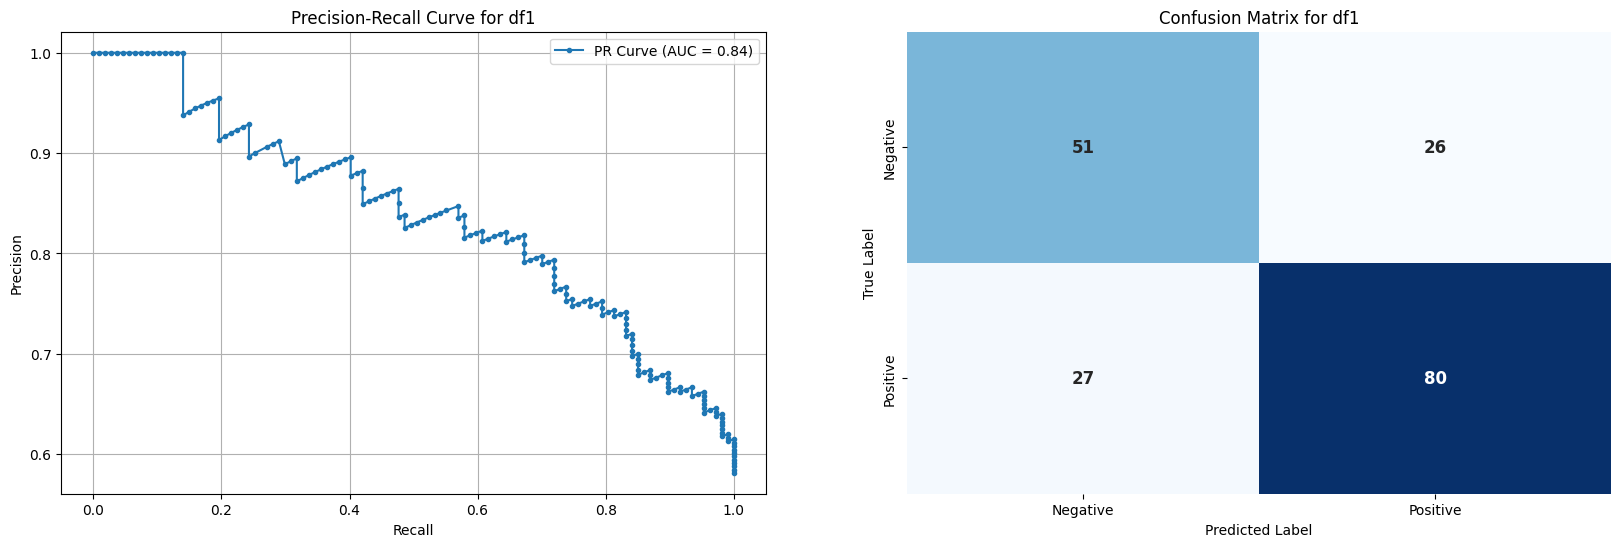

Optimal parameters: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Cross-validation Accuracy: 0.8452 ± 0.0472
Cross-validation PR AUC: 0.9137 ± 0.0353
Classification Report for df2: 
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

PR AUC: 0.9447755232852257
Accuracy for df2: 0.87


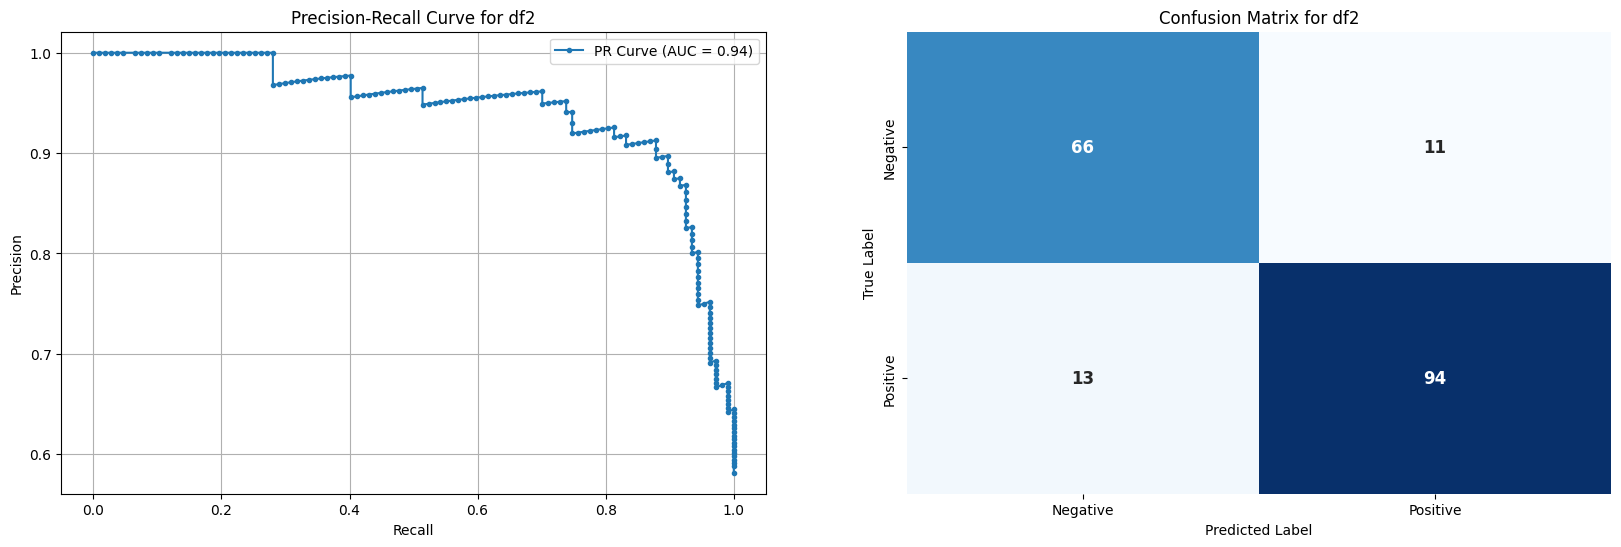

Optimal parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 200}
Cross-validation Accuracy: 0.8311 ± 0.0490
Cross-validation PR AUC: 0.9142 ± 0.0312
Classification Report for df3: 
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        77
           1       0.89      0.83      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.84      0.84       184

PR AUC: 0.9394548805023637
Accuracy for df3: 0.84


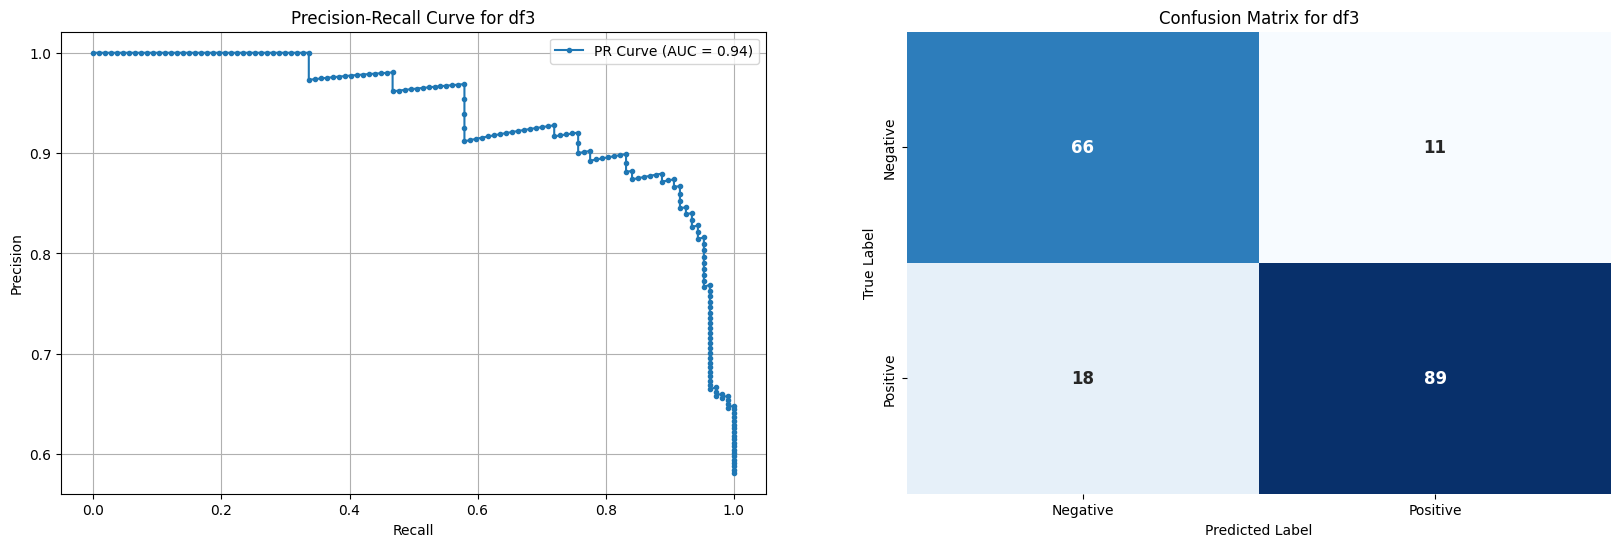

Optimal parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 50}
Cross-validation Accuracy: 0.7320 ± 0.0221
Cross-validation PR AUC: 0.8388 ± 0.0276
Classification Report for df1_1: 
              precision    recall  f1-score   support

           0       0.65      0.66      0.66        77
           1       0.75      0.75      0.75       107

    accuracy                           0.71       184
   macro avg       0.70      0.71      0.70       184
weighted avg       0.71      0.71      0.71       184

PR AUC: 0.8374692005433455
Accuracy for df1_1: 0.71


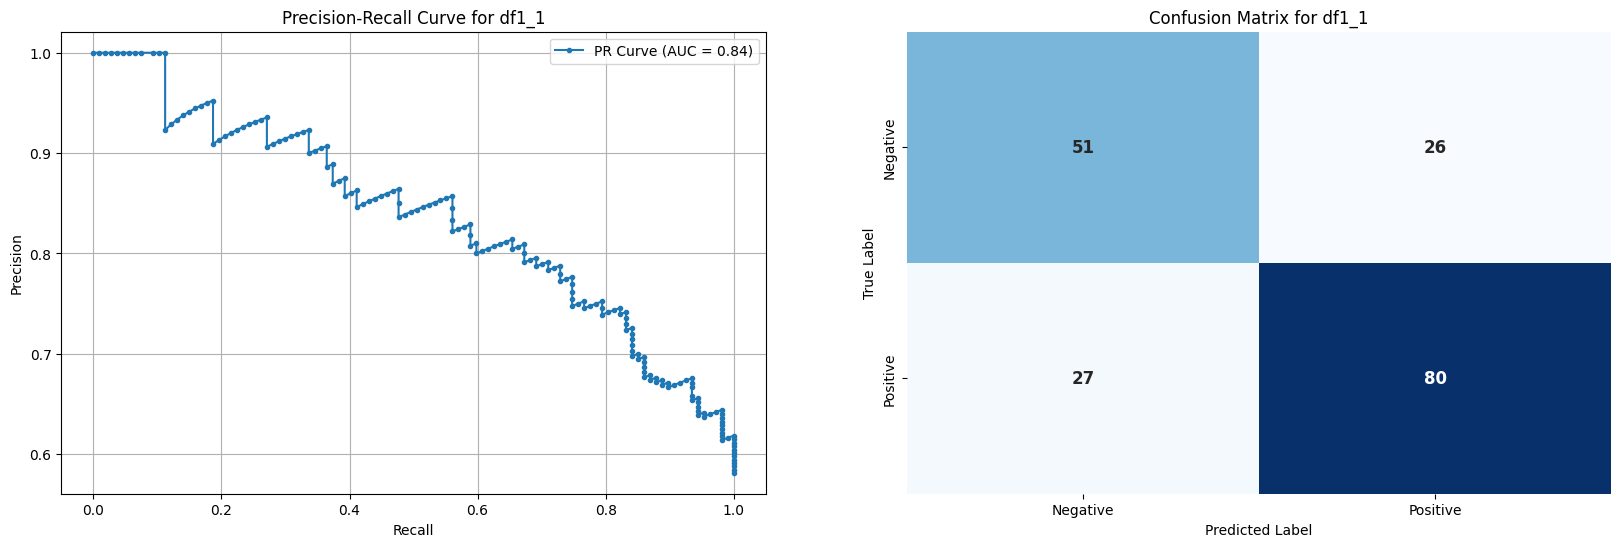

Optimal parameters: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Cross-validation Accuracy: 0.8387 ± 0.0424
Cross-validation PR AUC: 0.9075 ± 0.0363
Classification Report for df2_1: 
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        77
           1       0.90      0.89      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

PR AUC: 0.9437739565567209
Accuracy for df2_1: 0.88


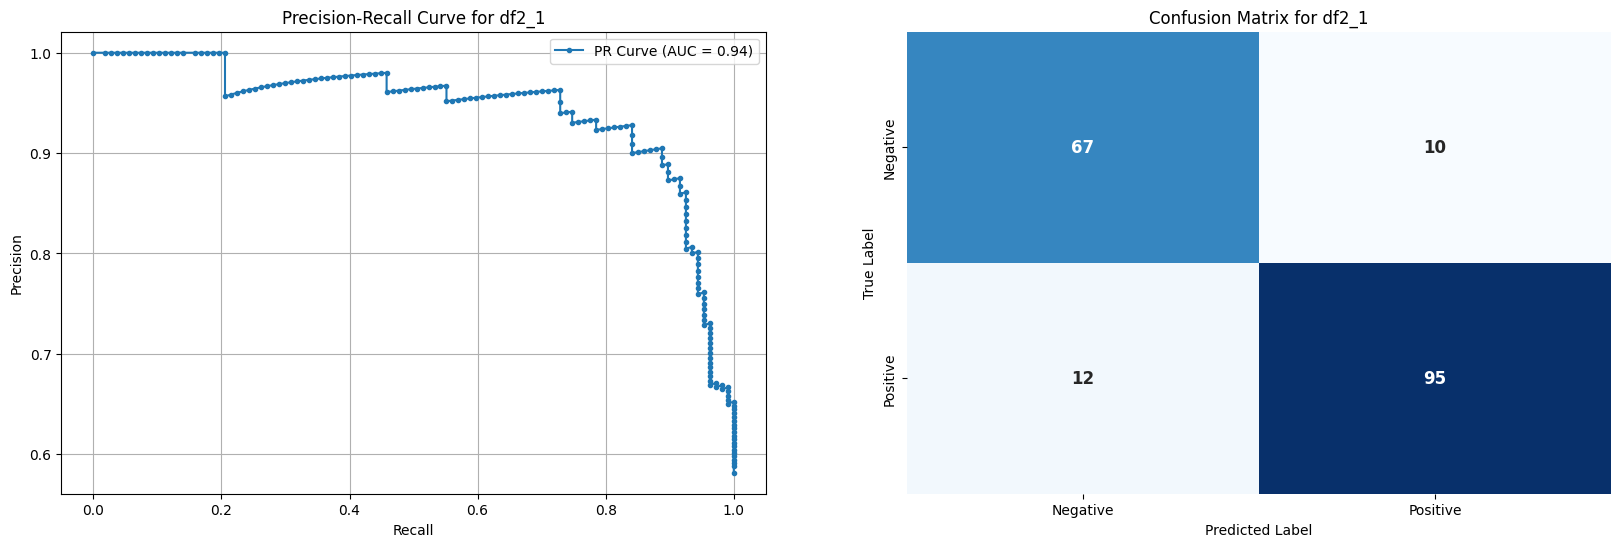

Optimal parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}
Cross-validation Accuracy: 0.8300 ± 0.0534
Cross-validation PR AUC: 0.9131 ± 0.0322
Classification Report for df3_1: 
              precision    recall  f1-score   support

           0       0.78      0.86      0.81        77
           1       0.89      0.82      0.85       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184

PR AUC: 0.941184568409784
Accuracy for df3_1: 0.84


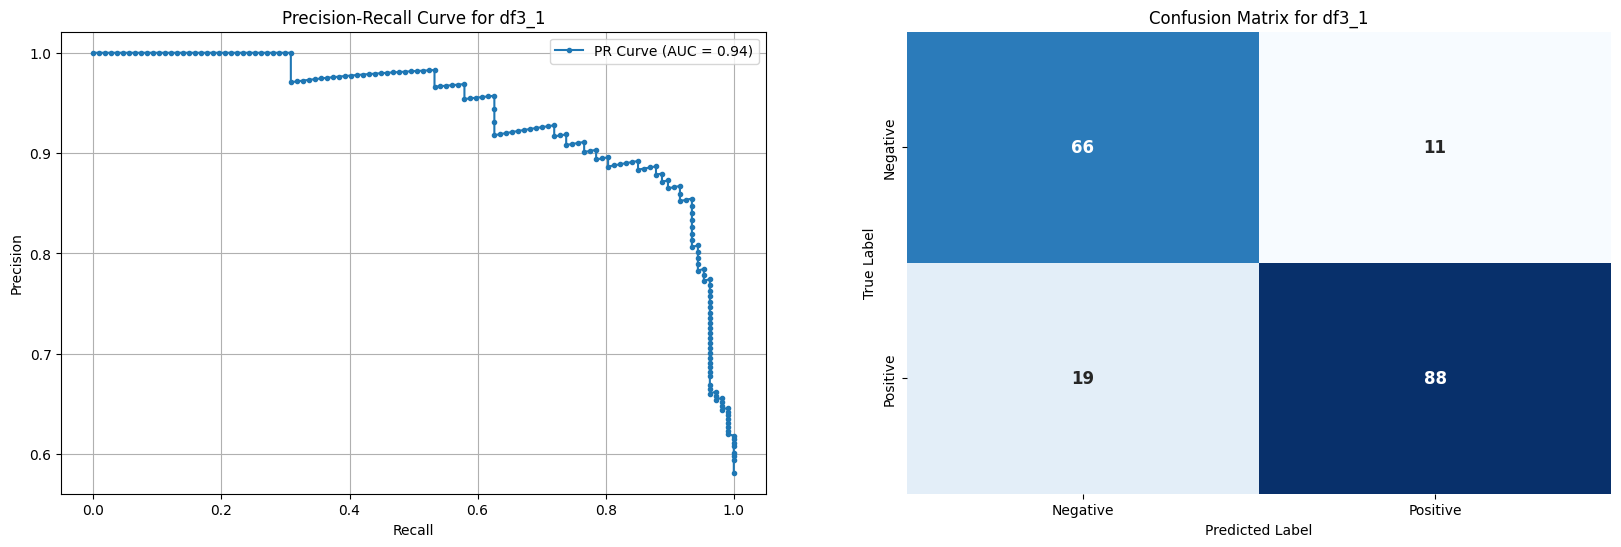

Optimal parameters: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 50}
Cross-validation Accuracy: 0.7309 ± 0.0244
Cross-validation PR AUC: 0.8261 ± 0.0269
Classification Report for df1_2: 
              precision    recall  f1-score   support

           0       0.62      0.60      0.61        77
           1       0.72      0.74      0.73       107

    accuracy                           0.68       184
   macro avg       0.67      0.67      0.67       184
weighted avg       0.68      0.68      0.68       184

PR AUC: 0.824306953506727
Accuracy for df1_2: 0.68


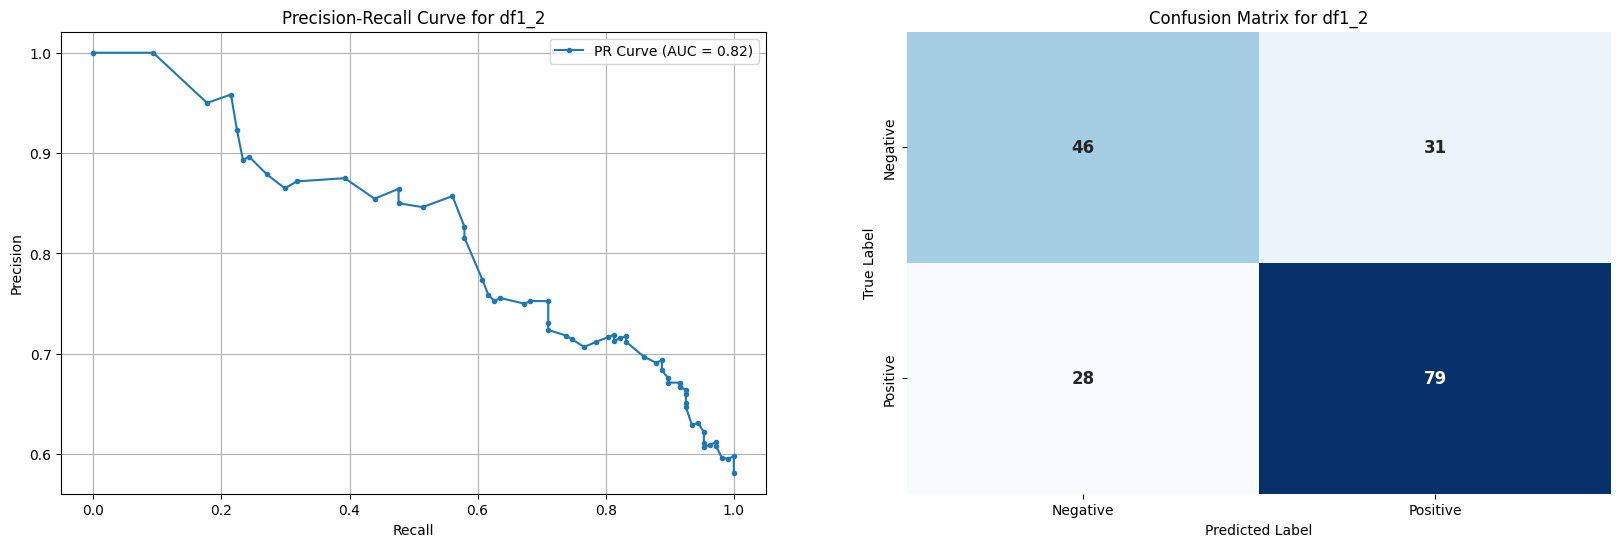

Optimal parameters: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}
Cross-validation Accuracy: 0.8246 ± 0.0463
Cross-validation PR AUC: 0.9003 ± 0.0336
Classification Report for df2_2: 
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        77
           1       0.92      0.84      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184

PR AUC: 0.9343793912180922
Accuracy for df2_2: 0.86


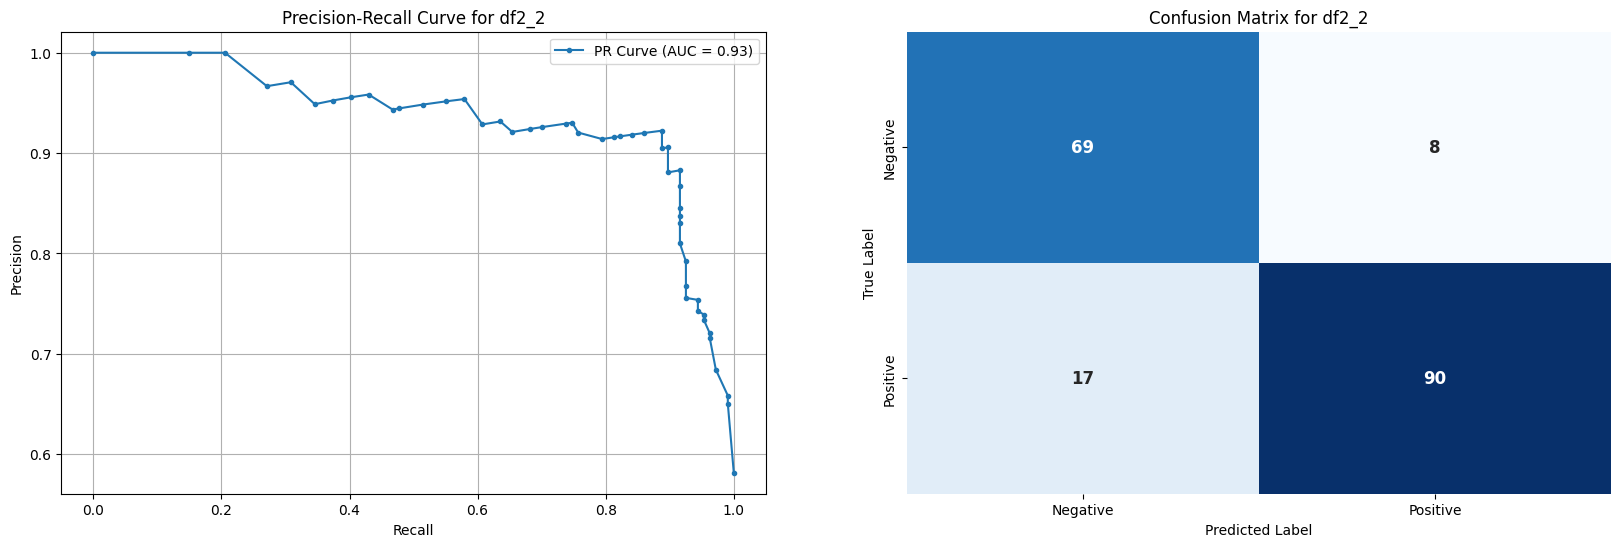

Optimal parameters: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Cross-validation Accuracy: 0.8387 ± 0.0510
Cross-validation PR AUC: 0.9161 ± 0.0351
Classification Report for df3_2: 
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        77
           1       0.87      0.84      0.86       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184

PR AUC: 0.9246470475563788
Accuracy for df3_2: 0.84


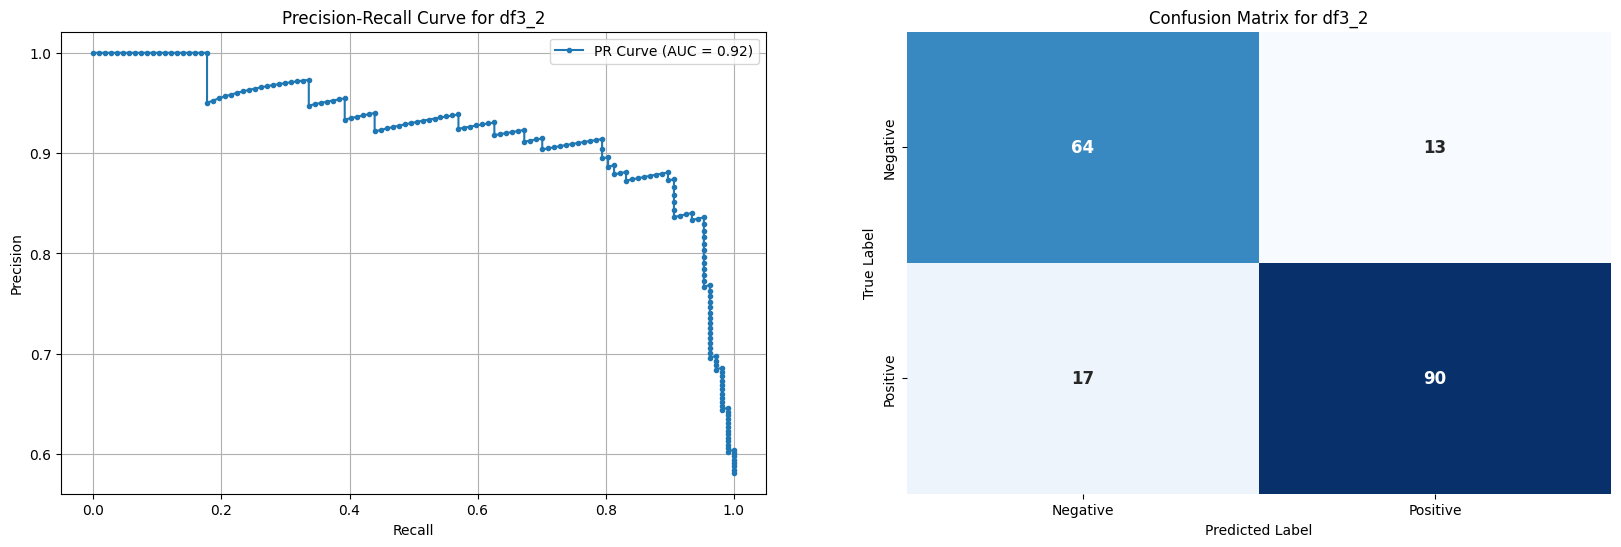

In [541]:
def evaluate_random_forest(X, y, dataset_label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define hyperparameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],  # Number of trees
        'max_depth': [None, 10, 20],     # Maximum depth of each tree
        'criterion': ['gini', 'entropy']
    }

    # Use GridSearchCV with cross-validation
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, 
                               scoring=make_scorer(average_precision_score), cv=5)
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_params = grid_search.best_params_
    print(f'Optimal parameters: {best_params}')
    best_rf = grid_search.best_estimator_

    # Perform cross-validation on the best model
    cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')
    cv_pr_auc_scores = cross_val_score(best_rf, X, y, cv=5, scoring='average_precision')

    print(f'Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'Cross-validation PR AUC: {cv_pr_auc_scores.mean():.4f} ± {cv_pr_auc_scores.std():.4f}')

    # Predictions on test set
    y_scores = best_rf.predict_proba(X_test)[:, 1]
    y_pred = best_rf.predict(X_test)

    # Generate classification report
    class_report = classification_report(y_test, y_pred)
    print(f'Classification Report for {dataset_label}: \n{class_report}')

    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Compute Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_scores)

    # Compute PR AUC
    pr_auc = auc(recall, precision)
    print(f'PR AUC: {pr_auc}')

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy for {dataset_label}: {accuracy:.2f}')

    # Store results
    results["Random Forest"][dataset_label] = {
        "Accuracy": accuracy,
        "PR AUC": pr_auc,
        "CV Accuracy": cv_scores.mean(),
        "CV PR AUC": cv_pr_auc_scores.mean()
    }

    # Create subplots for PR curve and confusion matrix
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))

    # Plot the PR curve
    ax[0].plot(recall, precision, marker='.', label=f'PR Curve (AUC = {pr_auc:.2f})')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title(f'Precision-Recall Curve for {dataset_label}')
    ax[0].legend()
    ax[0].grid(True)

    # Plot confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
                annot_kws={"fontsize": 12, "fontweight": "bold", "ha": "center", "va": "center"}, ax=ax[1])
    ax[1].set_title(f'Confusion Matrix for {dataset_label}')
    ax[1].set_xlabel('Predicted Label')
    ax[1].set_ylabel('True Label')
    ax[1].set_xticklabels(['Negative', 'Positive'])
    ax[1].set_yticklabels(['Negative', 'Positive'])

    plt.show()


# Dataset labels and data
datasets = {
    'df1': (df1, 'HeartDisease'),
    'df2': (df2, 'HeartDisease'),
    'df3': (df3, 'HeartDisease'),
    'df1_1': (df1_1, 'HeartDisease'),
    'df2_1': (df2_1, 'HeartDisease'),
    'df3_1': (df3_1, 'HeartDisease'),
    'df1_2': (df1_2, 'HeartDisease'),
    'df2_2': (df2_2, 'HeartDisease'),
    'df3_2': (df3_2, 'HeartDisease')
}

for label, (df, target) in datasets.items():
    X = df.drop(columns=[target])
    y = df[target]
    evaluate_random_forest(X, y, label)


# SVM

In [542]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

Best parameters for df1: {'kernel': 'rbf'}
Cross-Validated Accuracy for df1: 0.76
Cross-Validated PR AUC for df1: 0.83
Classification Report for df1: 
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       410
           1       0.84      0.85      0.84       508

    accuracy                           0.83       918
   macro avg       0.82      0.82      0.82       918
weighted avg       0.83      0.83      0.83       918



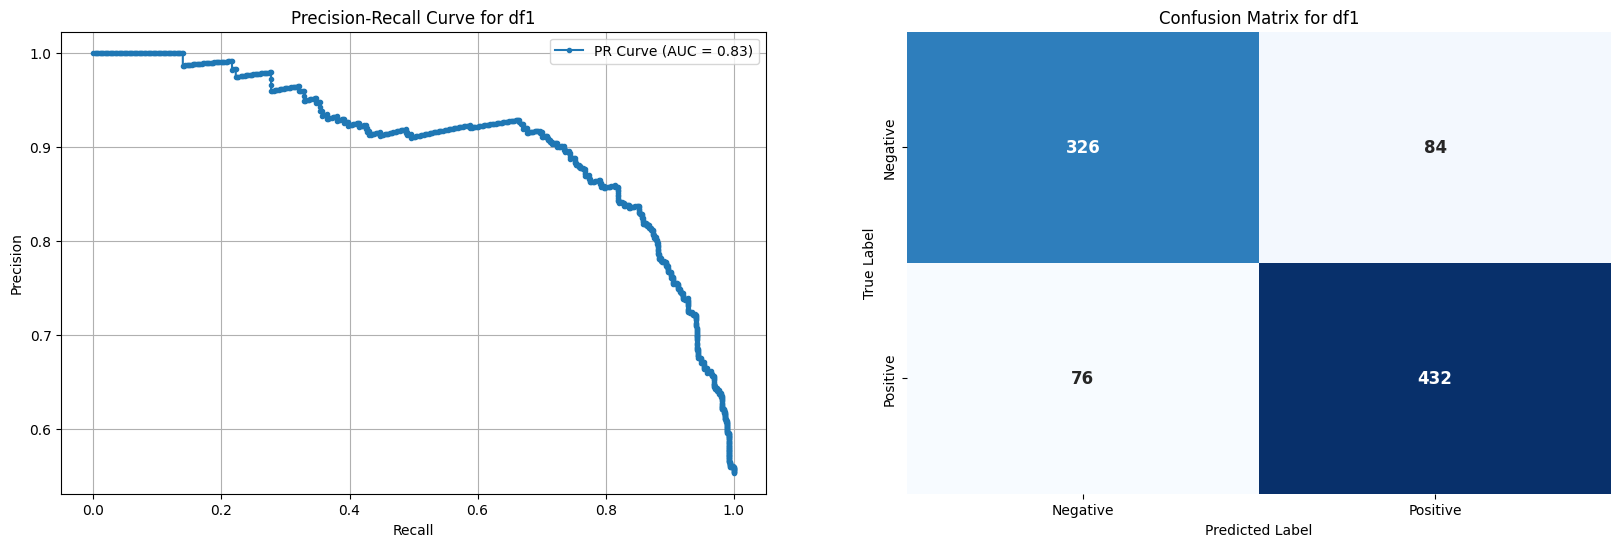

Best parameters for df2: {'kernel': 'linear'}
Cross-Validated Accuracy for df2: 0.84
Cross-Validated PR AUC for df2: 0.92
Classification Report for df2: 
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       410
           1       0.87      0.89      0.88       508

    accuracy                           0.87       918
   macro avg       0.87      0.86      0.86       918
weighted avg       0.87      0.87      0.87       918



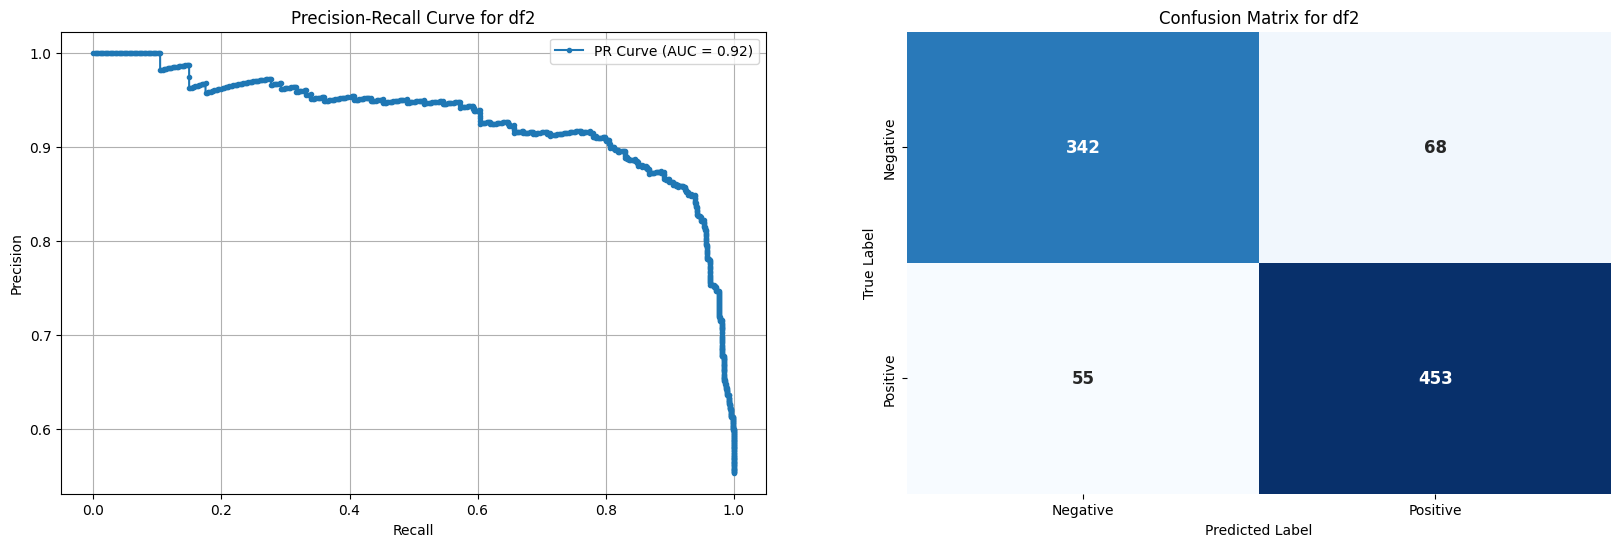

Best parameters for df3: {'kernel': 'rbf'}
Cross-Validated Accuracy for df3: 0.85
Cross-Validated PR AUC for df3: 0.92
Classification Report for df3: 
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       410
           1       0.88      0.93      0.90       508

    accuracy                           0.89       918
   macro avg       0.89      0.89      0.89       918
weighted avg       0.89      0.89      0.89       918



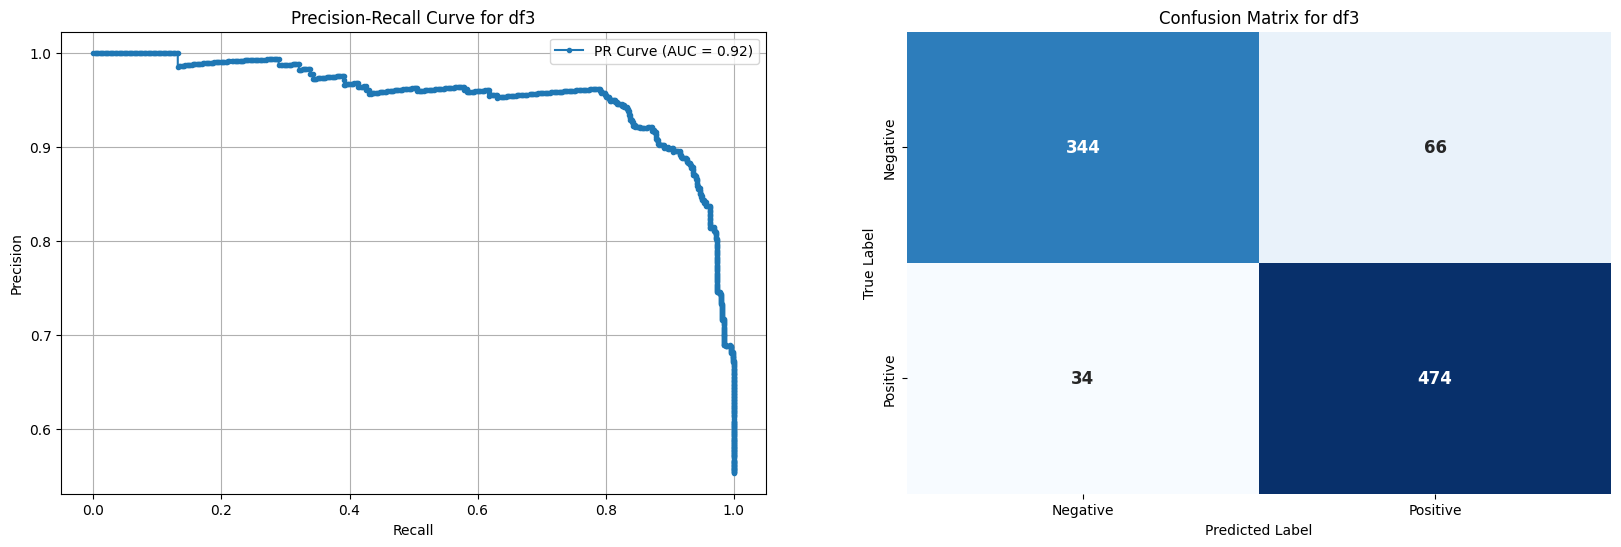

Best parameters for df1_1: {'kernel': 'rbf'}
Cross-Validated Accuracy for df1_1: 0.76
Cross-Validated PR AUC for df1_1: 0.83
Classification Report for df1_1: 
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       410
           1       0.84      0.85      0.84       508

    accuracy                           0.83       918
   macro avg       0.82      0.82      0.82       918
weighted avg       0.83      0.83      0.83       918



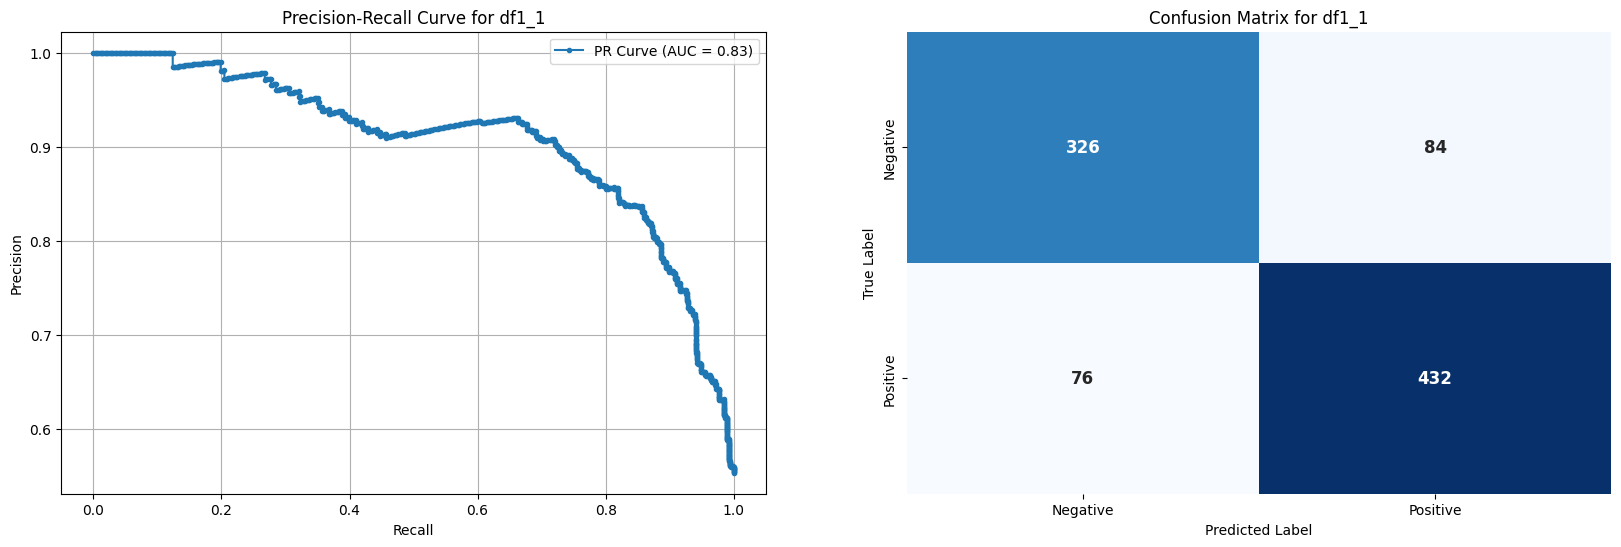

Best parameters for df2_1: {'kernel': 'rbf'}
Cross-Validated Accuracy for df2_1: 0.84
Cross-Validated PR AUC for df2_1: 0.91
Classification Report for df2_1: 
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       410
           1       0.88      0.95      0.91       508

    accuracy                           0.90       918
   macro avg       0.90      0.89      0.90       918
weighted avg       0.90      0.90      0.90       918



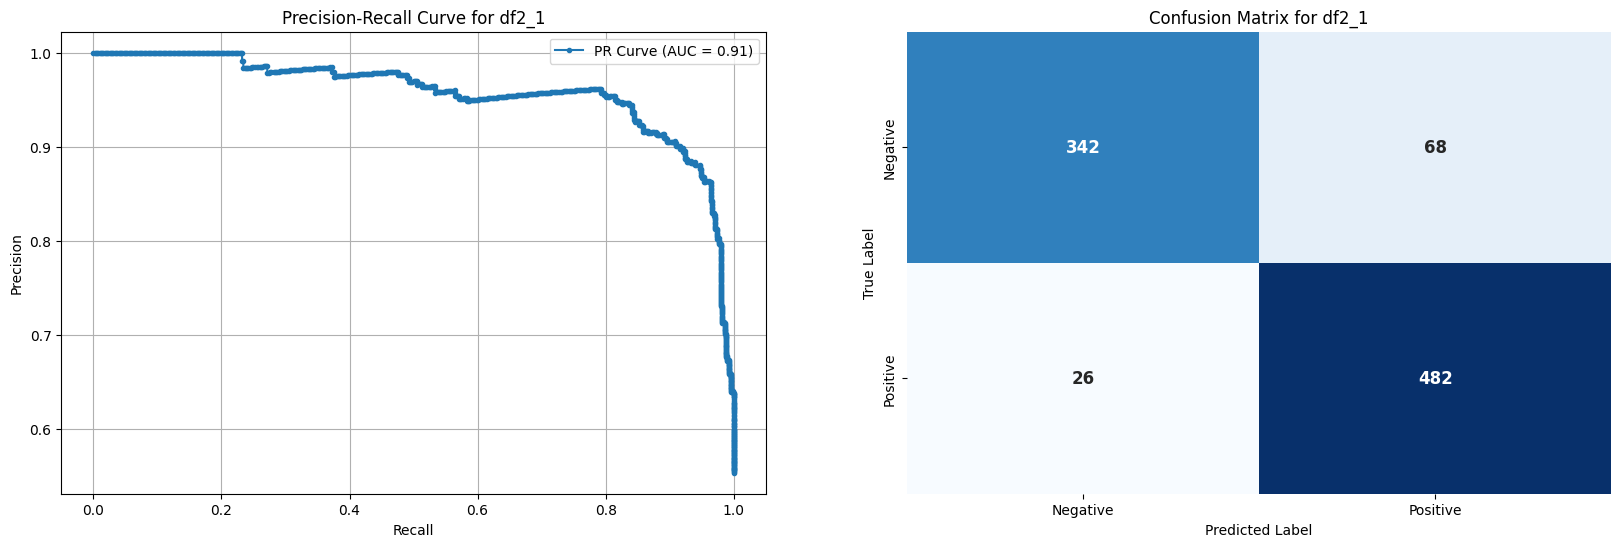

Best parameters for df3_1: {'kernel': 'rbf'}
Cross-Validated Accuracy for df3_1: 0.85
Cross-Validated PR AUC for df3_1: 0.92
Classification Report for df3_1: 
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       410
           1       0.88      0.94      0.91       508

    accuracy                           0.89       918
   macro avg       0.90      0.89      0.89       918
weighted avg       0.89      0.89      0.89       918



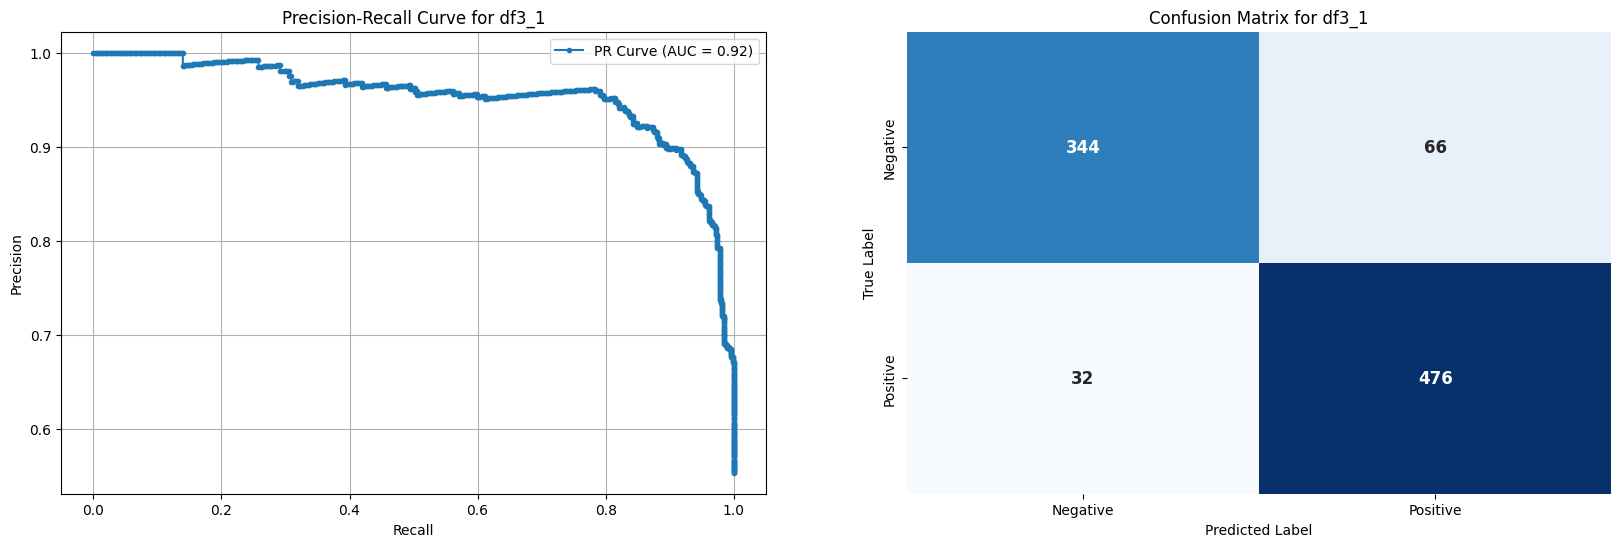

Best parameters for df1_2: {'kernel': 'rbf'}
Cross-Validated Accuracy for df1_2: 0.76
Cross-Validated PR AUC for df1_2: 0.83
Classification Report for df1_2: 
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       410
           1       0.83      0.84      0.84       508

    accuracy                           0.82       918
   macro avg       0.82      0.82      0.82       918
weighted avg       0.82      0.82      0.82       918



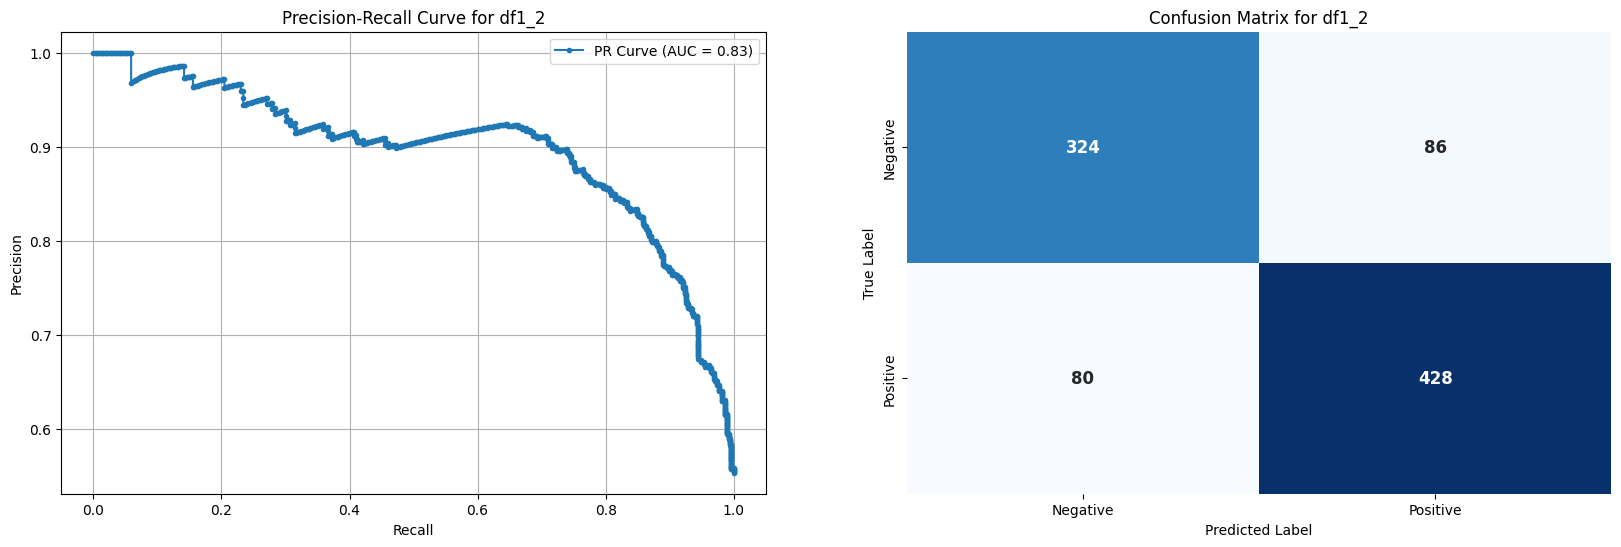

Best parameters for df2_2: {'kernel': 'rbf'}
Cross-Validated Accuracy for df2_2: 0.84
Cross-Validated PR AUC for df2_2: 0.91
Classification Report for df2_2: 
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       410
           1       0.88      0.94      0.91       508

    accuracy                           0.89       918
   macro avg       0.90      0.89      0.89       918
weighted avg       0.90      0.89      0.89       918



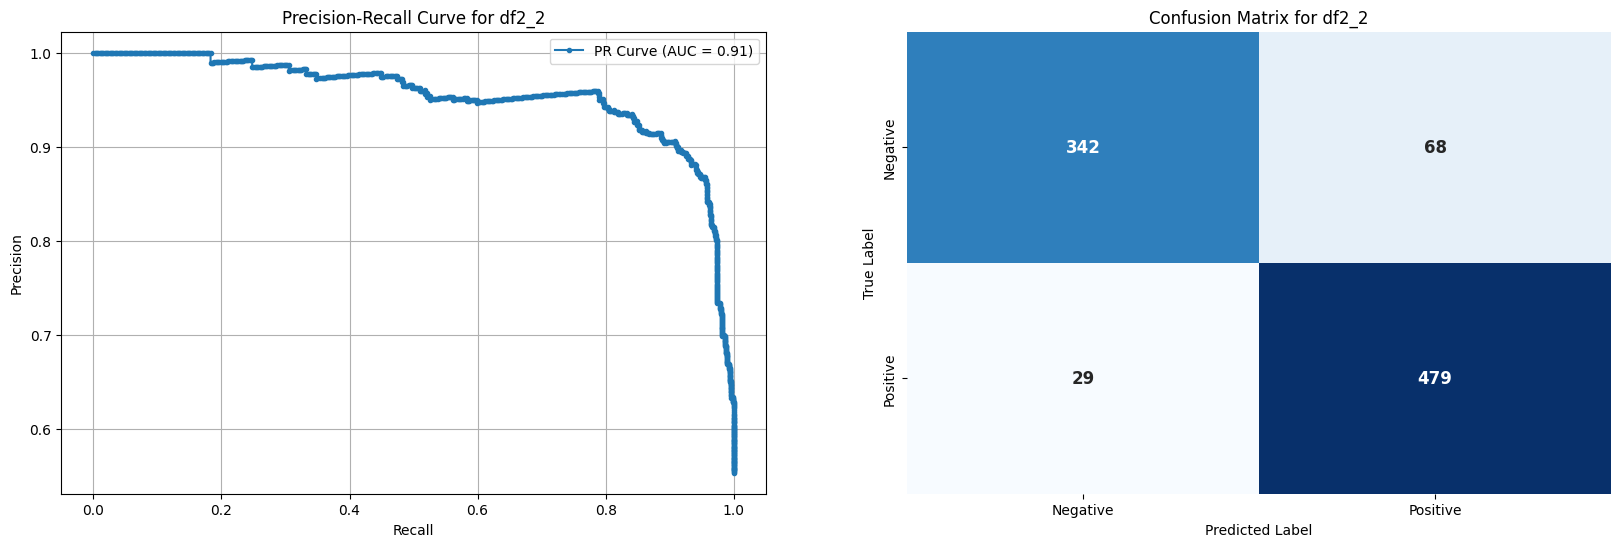

Best parameters for df3_2: {'kernel': 'rbf'}
Cross-Validated Accuracy for df3_2: 0.85
Cross-Validated PR AUC for df3_2: 0.91
Classification Report for df3_2: 
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       410
           1       0.88      0.94      0.91       508

    accuracy                           0.89       918
   macro avg       0.90      0.89      0.89       918
weighted avg       0.89      0.89      0.89       918



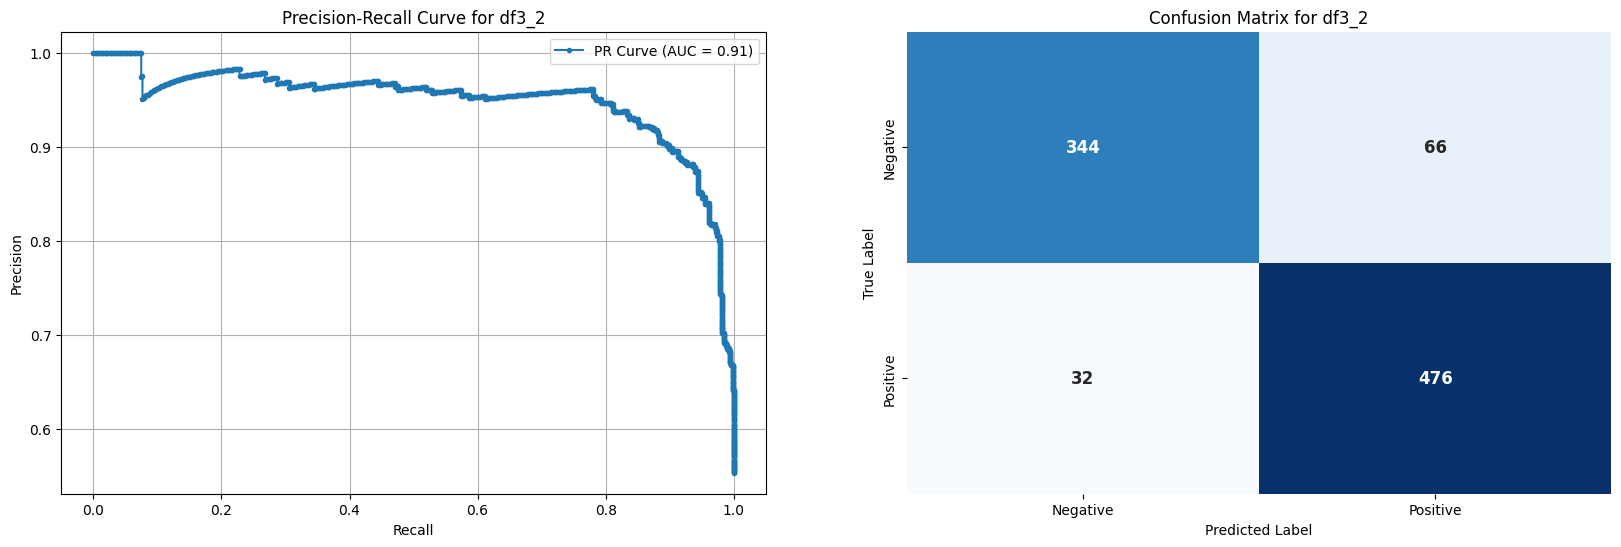

In [543]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, accuracy_score

def evaluate_svm(X, y, dataset_label):
    # Scale the dataset
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialize the SVM classifier
    svm_clf = SVC(C=1.0, probability=True)

    # Define the parameter grid for GridSearchCV
    param_grid = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

    # Perform Grid Search with 5-fold cross-validation to find the best parameters
    grid_search = GridSearchCV(estimator=svm_clf, param_grid=param_grid, cv=5)
    grid_search.fit(X_scaled, y)

    # Get the best parameters
    best_params = grid_search.best_params_
    print(f'Best parameters for {dataset_label}: {best_params}')

    # Train the best model with cross-validation
    best_svm_clf = SVC(**best_params, probability=True)

    # Use cross-validation to evaluate accuracy and PR AUC
    accuracy_scores = cross_val_score(best_svm_clf, X_scaled, y, cv=5, scoring='accuracy')
    pr_auc_scores = cross_val_score(best_svm_clf, X_scaled, y, cv=5, scoring='average_precision')

    # Compute mean accuracy and PR AUC
    mean_accuracy = accuracy_scores.mean()
    mean_pr_auc = pr_auc_scores.mean()

    print(f'Cross-Validated Accuracy for {dataset_label}: {mean_accuracy:.2f}')
    print(f'Cross-Validated PR AUC for {dataset_label}: {mean_pr_auc:.2f}')

    results["SVM"][dataset_label] = {
        "Accuracy": mean_accuracy,
        "PR AUC": mean_pr_auc,
        "CV Accuracy": mean_accuracy,
        "CV PR AUC": mean_pr_auc,
    }

    # Train the final model on the whole dataset
    best_svm_clf.fit(X_scaled, y)
    
    # Get predicted probabilities for PR curve
    y_scores = best_svm_clf.predict_proba(X_scaled)[:, 1]
    y_pred = best_svm_clf.predict(X_scaled)

    # Generate classification report
    class_report = classification_report(y, y_pred)
    print(f'Classification Report for {dataset_label}: \n{class_report}')

    # Generate confusion matrix
    conf_matrix = confusion_matrix(y, y_pred)

    # Calculate precision-recall curve
    precision, recall, _ = precision_recall_curve(y, y_scores)

    # Plot PR curve and confusion matrix
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))

    # PR Curve
    ax[0].plot(recall, precision, marker='.', label=f'PR Curve (AUC = {mean_pr_auc:.2f})')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title(f'Precision-Recall Curve for {dataset_label}')
    ax[0].legend()
    ax[0].grid(True)

    # Confusion Matrix
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"fontsize": 12, "fontweight": "bold"}, ax=ax[1])
    ax[1].set_title(f'Confusion Matrix for {dataset_label}')
    ax[1].set_xlabel('Predicted Label')
    ax[1].set_ylabel('True Label')
    ax[1].set_xticklabels(['Negative', 'Positive'])
    ax[1].set_yticklabels(['Negative', 'Positive'])

    plt.show()

# Dataset labels and data
datasets = {
    'df1': (df1, 'HeartDisease'),
    'df2': (df2, 'HeartDisease'),
    'df3': (df3, 'HeartDisease'),
    'df1_1': (df1_1, 'HeartDisease'),
    'df2_1': (df2_1, 'HeartDisease'),
    'df3_1': (df3_1, 'HeartDisease'),
    'df1_2': (df1_2, 'HeartDisease'),
    'df2_2': (df2_2, 'HeartDisease'),
    'df3_2': (df3_2, 'HeartDisease')
}

# Iterate through each dataset and evaluate SVM
for label, (df, target) in datasets.items():
    X = df.drop(columns=[target])
    y = df[target]
    evaluate_svm(X, y, label)


In [544]:
print(results)

{'KNN': {'df1': {'Optimal k': 9, 'PR AUC': 0.8661767055663664, 'CV PR AUC': 0.8526974940210609, 'Accuracy': 0.7391304347826086, 'CV Accuracy': 0.7943062156369397}, 'df2': {'Optimal k': 23, 'PR AUC': 0.940724184328848, 'CV PR AUC': 0.9007984213041823, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8610753890597334}, 'df3': {'Optimal k': 19, 'PR AUC': 0.9503411952365282, 'CV PR AUC': 0.9049450132273993, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8664616531544125}, 'df1_1': {'Optimal k': 25, 'PR AUC': 0.8673937896519223, 'CV PR AUC': 0.8691450042725279, 'Accuracy': 0.7445652173913043, 'CV Accuracy': 0.8024601621470506}, 'df2_1': {'Optimal k': 21, 'PR AUC': 0.9306504181321884, 'CV PR AUC': 0.8928091809027695, 'Accuracy': 0.8532608695652174, 'CV Accuracy': 0.8515515795359239}, 'df3_1': {'Optimal k': 17, 'PR AUC': 0.9493758927476706, 'CV PR AUC': 0.9041115771224879, 'Accuracy': 0.8695652173913043, 'CV Accuracy': 0.8637405647190383}, 'df1_2': {'Optimal k': 25, 'PR AUC': 0.846583214543

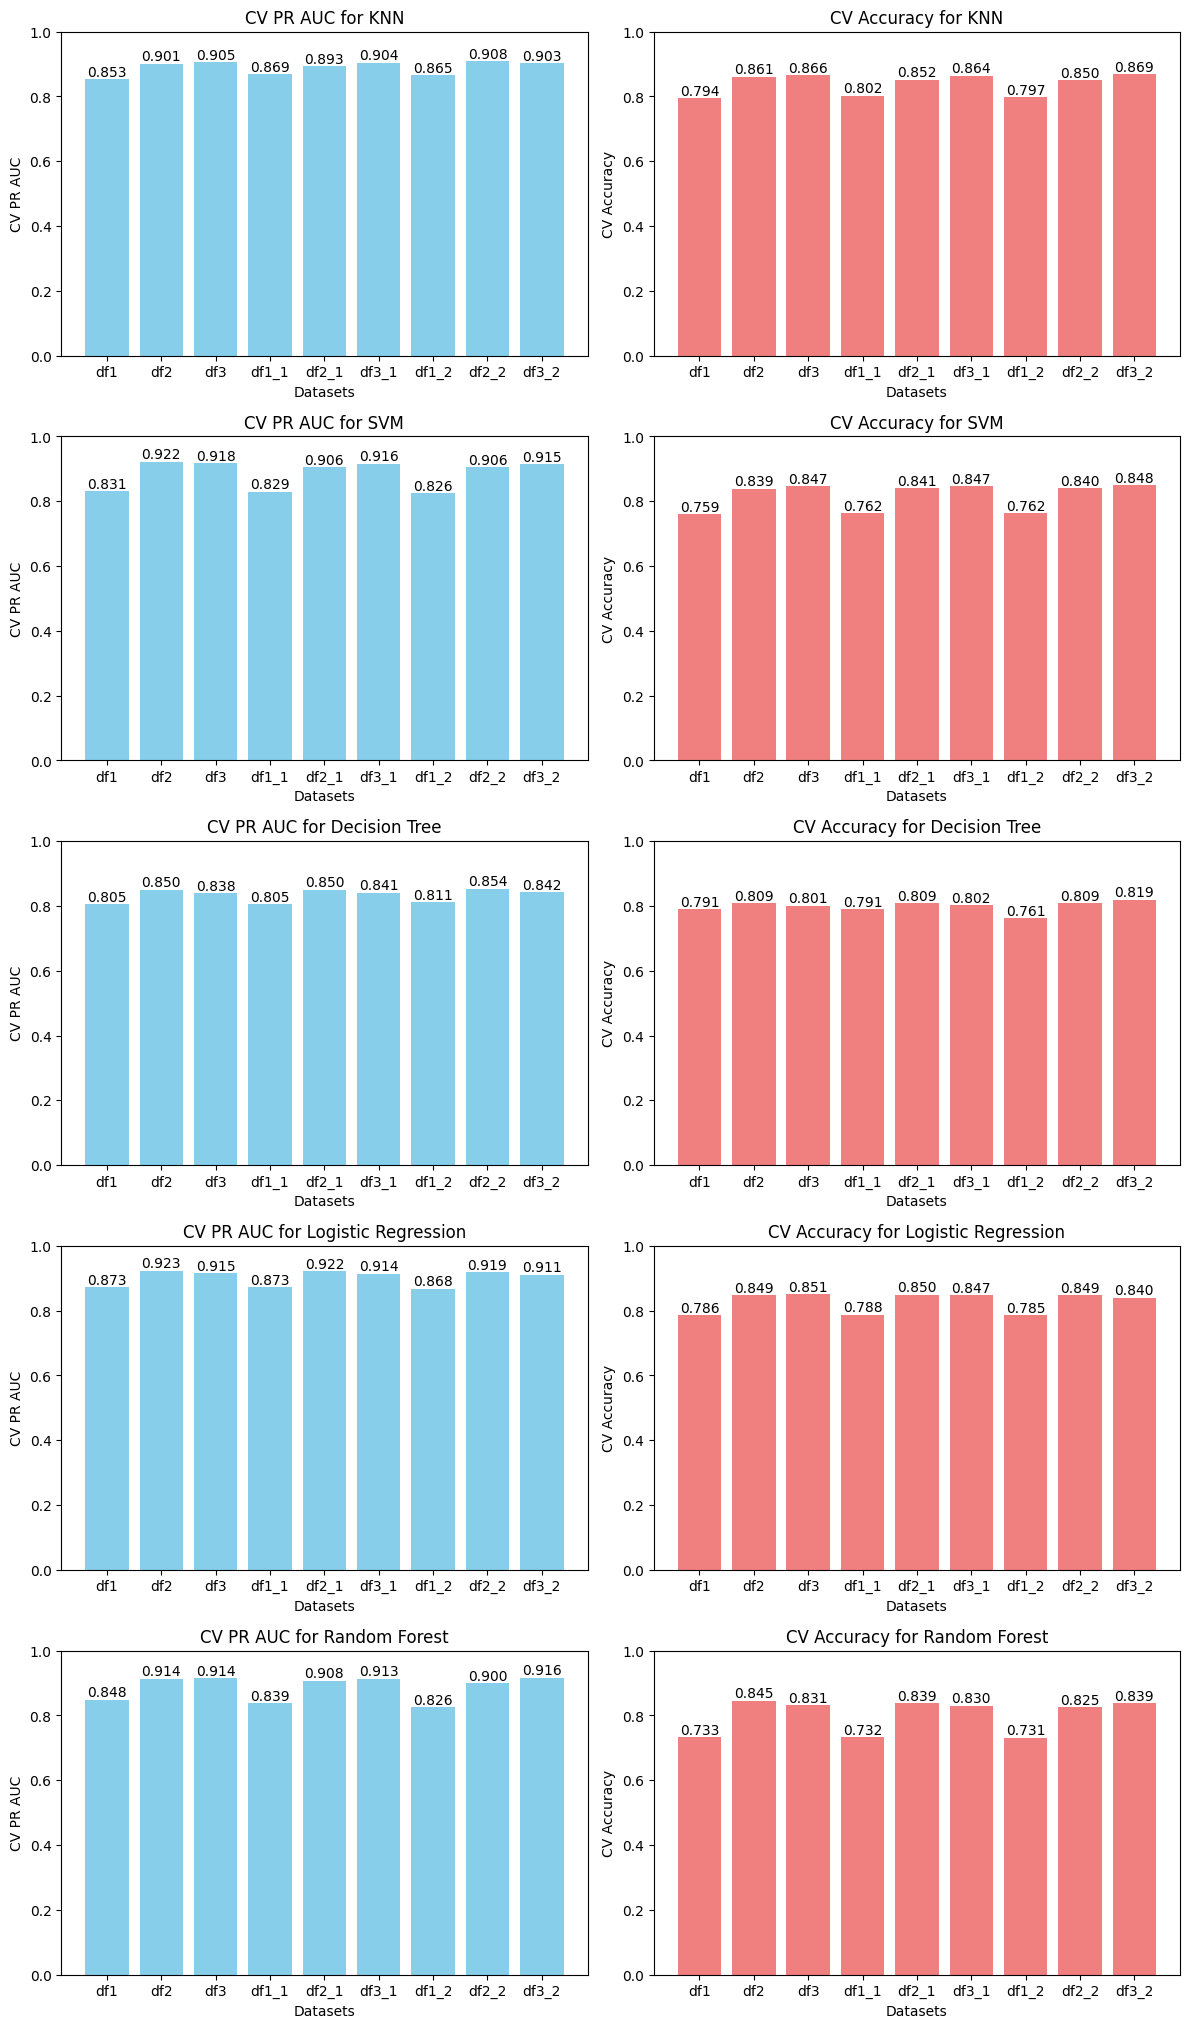

In [545]:
import matplotlib.pyplot as plt
import math

# Define the number of models
num_models = len(results)

# Set the number of columns per row
cols = 2
rows = math.ceil(num_models / cols)  # Calculate required rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=rows * 2, ncols=cols, figsize=(6 * cols, 4 * rows * 2))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate through models and plot
for idx, (model, data) in enumerate(results.items()):
    datasets = list(data.keys())

    # CV PR AUC Plot
    cv_pr_auc_values = [data[ds]['CV PR AUC'] for ds in datasets]
    bars = axes[2 * idx].bar(datasets, cv_pr_auc_values, color='skyblue')

    # Add values on top of bars
    for bar, value in zip(bars, cv_pr_auc_values):
        axes[2 * idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
                           f'{value:.3f}', ha='center', va='bottom', fontsize=10)

    axes[2 * idx].set_xlabel('Datasets')
    axes[2 * idx].set_ylabel('CV PR AUC')
    axes[2 * idx].set_title(f'CV PR AUC for {model}')
    axes[2 * idx].set_ylim(0, 1)

    # CV Accuracy Plot
    cv_accuracy_values = [data[ds]['CV Accuracy'] for ds in datasets]
    bars = axes[2 * idx + 1].bar(datasets, cv_accuracy_values, color='lightcoral')

    # Add values on top of bars
    for bar, value in zip(bars, cv_accuracy_values):
        axes[2 * idx + 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
                               f'{value:.3f}', ha='center', va='bottom', fontsize=10)

    axes[2 * idx + 1].set_xlabel('Datasets')
    axes[2 * idx + 1].set_ylabel('CV Accuracy')
    axes[2 * idx + 1].set_title(f'CV Accuracy for {model}')
    axes[2 * idx + 1].set_ylim(0, 1)

# Remove unused subplots if number of models is odd
for i in range(2 * num_models, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [546]:
print(results)
for model, data in results.items():
    # Get the dataset with the highest CV PR AUC
    best_cv_pr_auc_dataset = max(data, key=lambda ds: data[ds]['CV PR AUC'])
    best_cv_pr_auc_value = data[best_cv_pr_auc_dataset]['CV PR AUC']
    
    # Get the dataset with the highest CV Accuracy
    best_cv_accuracy_dataset = max(data, key=lambda ds: data[ds]['CV Accuracy'])
    best_cv_accuracy_value = data[best_cv_accuracy_dataset]['CV Accuracy']
    
    print(f"Model: {model}")
    print(f"  🔹 Best dataset for CV PR AUC: {best_cv_pr_auc_dataset} ({best_cv_pr_auc_value:.3f})")
    print(f"  🔹 Best dataset for CV Accuracy: {best_cv_accuracy_dataset} ({best_cv_accuracy_value:.3f})")
    print("-" * 50)

{'KNN': {'df1': {'Optimal k': 9, 'PR AUC': 0.8661767055663664, 'CV PR AUC': 0.8526974940210609, 'Accuracy': 0.7391304347826086, 'CV Accuracy': 0.7943062156369397}, 'df2': {'Optimal k': 23, 'PR AUC': 0.940724184328848, 'CV PR AUC': 0.9007984213041823, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8610753890597334}, 'df3': {'Optimal k': 19, 'PR AUC': 0.9503411952365282, 'CV PR AUC': 0.9049450132273993, 'Accuracy': 0.8586956521739131, 'CV Accuracy': 0.8664616531544125}, 'df1_1': {'Optimal k': 25, 'PR AUC': 0.8673937896519223, 'CV PR AUC': 0.8691450042725279, 'Accuracy': 0.7445652173913043, 'CV Accuracy': 0.8024601621470506}, 'df2_1': {'Optimal k': 21, 'PR AUC': 0.9306504181321884, 'CV PR AUC': 0.8928091809027695, 'Accuracy': 0.8532608695652174, 'CV Accuracy': 0.8515515795359239}, 'df3_1': {'Optimal k': 17, 'PR AUC': 0.9493758927476706, 'CV PR AUC': 0.9041115771224879, 'Accuracy': 0.8695652173913043, 'CV Accuracy': 0.8637405647190383}, 'df1_2': {'Optimal k': 25, 'PR AUC': 0.846583214543